# Klasteryzacja dokumentów 20 Newsgroups — raport główny

**Autorzy:**  
- Patryk Jan Sozański, 300258
- Marcin Sadowski, 325220

Ten notebook stanowi raport do projektu grupowania tekstu na zbiorze 20 Newsgroups (UCI). Zawiera opis problemu, podstawy teoretyczne, implementacje kolejnych elementow pipeline'u oraz komorki wykonawcze, ktore uruchamiaja eksperymenty krok po kroku.

Celem projektu jest porownanie reprezentacji dokumentow tekstowych oraz algorytmow klasteryzacji: `K-means`, `klasteryzacji hierarchicznej`, `DBSCAN` oraz `klasteryzacji spektralnej`. Etykiety z `20 Newsgroups` nie sa uzywane do uczenia ani grupowania; pojawiaja sie dopiero w ocenie zewnetrznej przez `ARI`.

## Opis problemu

Klasteryzacja dokumentow to zadanie nienadzorowane: chcemy grupowac teksty tak, aby dokumenty podobne tematycznie trafialy do tych samych klastrow, bez wykorzystania etykiet klas podczas uczenia.  
W praktyce problem sprowadza sie do:
- wyboru reprezentacji tekstu (jak zamienic dokument na wektor),
- wyboru algorytmu klasteryzacji,
- doboru hiperparametrow (np. liczba klastrow `k`, linkage, `eps`),
- oceny jakosci klastrow metrykami wewnetrznymi i zewnetrznymi.

## Podejscie eksperymentalne

Pipeline jest uruchamiany etapowo:
1. **Przygotowanie danych**: czyszczenie, normalizacja, tokenizacja i lematyzacja.  
2. **Budowa reprezentacji**:
    - bazowa, podstawowa reprezentacja `TF-IDF` (baseline),
    - statyczne embeddingi (`GloVe` jako proxy, `fastText`),
    - kontekstowe embeddingi (`SBERT`).
3. **Klasteryzacja**:
    - `K-means`,
    - `Agglomerative Clustering`,
    - `DBSCAN`,
    - `Spectral Clustering`.
4. **Ocena jakosci**:
    - metryki wewnetrzne: `silhouette`, `Davies-Bouldin`, `Dunn`,
    - metryka zewnetrzna: `ARI` (tylko do porownania z rzeczywistymi etykietami).
5. **Analiza i raportowanie**:
    - wybor najlepszych przebiegow,
    - interpretacja klastrow przez slowa kluczowe i dokumenty reprezentatywne,
    - zapis artefaktow (CSV/JSON/wykresy/MLflow).

Eksperyment wspiera dwa tryby pracy:
- `quick` do szybkiej walidacji calego przeplywu,
- `full` do pelnej analizy i wynikow koncowych.

## 1. Srodowisko uruchomieniowe

Notebook nie wykonuje lokalnie komend instalacyjnych w komorkach. Lokalnie powinien byc uruchamiany na kernelu `Python (.venv)`, przygotowanym przez `setup_local_env.sh`. Komorka ponizej tylko sprawdza, czy wymagane biblioteki sa dostepne, i podaje jasny komunikat, jesli brakuje srodowiska.

In [1]:
import importlib.util
import sys
from pathlib import Path

REQUIRED_PACKAGES = ['mlflow', 'matplotlib', 'numpy', 'pandas', 'seaborn', 'nltk', 'sentence_transformers', 'sklearn', 'gensim', 'tqdm', 'wordcloud']
missing_packages = [pkg for pkg in REQUIRED_PACKAGES if importlib.util.find_spec(pkg) is None]

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version.split()[0]}")

if missing_packages:
    raise RuntimeError(
        "Missing packages: " + ", ".join(missing_packages) + "\n"
        "Local setup: run ./setup_local_env.sh and select kernel 'Python (.venv) ZUM'."
    )

print("Environment check passed.")


Python executable: /Users/patrykjansozanski/Desktop/studia/zum/projekt/text_group_20Newsgroups/.venv/bin/python
Python version: 3.13.13
Environment check passed.


## 1. Konfiguracja i parametry sterujące

W celu łatwego zarządzania eksperymentem, wprowadzamy globalny słownik konfiguracyjny. Pozwala to na:
1. Szybkie przełączanie między trybem szybkiego testowania (`quick`), a pełną ewaluacją (`full`).
2. Centralne zarządzanie siatkami parametrów dla każdego z algorytmów.
3. Parametryzację kosztownych operacji wektoryzacji i obliczania metryk dających odpowiedzi w czasie rzeczywistym.

Główne klucze konfiguracji:
- `mode`: tryb wykonania (`quick` lub `full`),
- `seed`: ziarno losowości dla zapewnienia powtarzalności (reprodukowalność),
- `kmeans_sample_size`: liczba dokumentów używana dla algorytmu K-Means (algorytm o złożoności liniowej $O(n)$),
- `hierarchical_sample_size`: limit próbek dla klasteryzacji hierarchicznej (algorytm o złożoności $O(n^2)$),
- `dbscan_sample_size`: limit próbek dla algorytmu DBSCAN (algorytm gęstościowy operujący na macierzy odległości $O(n^2)$),
- `spectral_sample_size`: limit próbek dla klasteryzacji spektralnej ($O(n^3)$ lub na wybranym grafie $O(n^2)$),
- `silhouette_sample_size`: próbkowanie dla miary silhouette,
- `davies_bouldin_sample_size`: próbkowanie dla miary Davies-Bouldin,
- `ari_sample_size`: próbkowanie dla miary ARI,
- `dunn_max_points`: limit punktów do liczenia Dunn Index,
- `embedding_models`: aktywne modele embeddingowe i ich parametry,
- `clustering_grid`: siatki hiperparametrów dla wybranych algorytmów,
- `artifact_dir`: katalog zapisywania wynikowych tabel, wykresów, cache i logów środowiska `MLflow`,
- `force_recompute_embeddings`: możliwość wymuszenia ponownego przeliczania embeddingów (zignorowanie zachowanego cache),
- `static_progress`, `sbert_batch_size`: specyficzne parametry wykonawcze widoków.

### Decyzja po wcześniejszych przebiegach eksperymentalnych

Po analizie pierwszej szerokiej siatki eksperymentów zawężono konfigurację do ustawień, które realnie różnicowały wyniki albo były potrzebne jako punkt odniesienia. Usunięto przebiegi powtarzające identyczne reprezentacje TF-IDF pod różnymi nazwami, warianty `max_df`, które nie zmieniały wyników, dodatkowe `n_init=30` w K-Means, słaby i kosztowny `complete linkage` oraz zakresy DBSCAN prowadzące do zdegenerowanych podziałów. W szczególności DBSCAN z bardzo wysokim udziałem szumu nie jest traktowany jako pełnoprawny zwycięzca rankingu, nawet jeśli metryki liczone na małej resztce punktów wyglądają pozornie dobrze.

Pozostawione ustawienia są więc wynikiem selekcji po wcześniejszych eksperymentach: mają ograniczyć koszt obliczeń, zmniejszyć liczbę jałowych przebiegów i zachować tylko warianty, które wnoszą informację do porównania reprezentacji oraz algorytmów.

### Tryb `quick` (iteracyjny i deweloperski)
Przeznaczenie: szybkie testy notebooka, sprawdzenie logiki i debugowanie przepływu na zmniejszonej próbce, aby dać sensowne wyniki bez wielogodzinnych oczekiwań.

Parametry losowań próbek (algorytmy):
- `kmeans_sample_size = 3000`,
- `hierarchical_sample_size = 3000`,
- `dbscan_sample_size = 3000`,
- `spectral_sample_size = 2000`.

Parametry losowań próbek (miary jakości):
- `silhouette_sample_size = 1500`,
- `davies_bouldin_sample_size = 3000`,
- `ari_sample_size = 3000`,
- `dunn_max_points = 1500`.

Siatki (`clustering_grid`) w trybie `quick`:
- `kmeans`: `k = [15, 20, 25]`, `n_init = [10]`, `max_iter = 300`,
- `hierarchical`: `k = [15, 20, 25]`, `linkage = ["average", "ward"]`,
- `dbscan`: `eps = [0.25, 0.30, 0.35]`, `min_samples = [5, 9, 12]`, `metric = ['correlation', 'cosine']`,
- `spectral`: `n_clusters = [15, 20, 25]`, `affinity = ['nearest_neighbors', 'rbf']`, `assign_labels = ['kmeans', 'discretize']`.

### Tryb `full` (produkcyjny)
Przeznaczenie: docelowe grupowanie całego dostępnego zbioru korpusu 20 Newsgroups (prawie 19 tys. dokumentów), oraz bogatsze poszukiwania siatki (grid search).

Parametry losowań próbek (algorytmy) w `full`:
- `kmeans_sample_size = None` (cały zbiór),
- `hierarchical_sample_size = None` (cały zbiór),
- `dbscan_sample_size = None` (cały zbiór),
- `spectral_sample_size = None` (cały zbiór).

Parametry losowań próbek (miary jakości) w `full`:
- `silhouette_sample_size = None` (bez przycinania),
- `davies_bouldin_sample_size = None` (bez przycinania),
- `ari_sample_size = None` (bez przycinania),
- `dunn_max_points = None` (bez przycinania).

Siatki (`clustering_grid`) w trybie `full`:
- `kmeans`: `k = [10, 15, 20, 25, 30]`, `n_init = [10]`, `max_iter = 300`,
- `hierarchical`: `k = [10, 15, 20, 25, 30]`, `linkage = ["average", "ward"]`,
- `dbscan`: `eps = [0.20, 0.25, 0.30, 0.35]`, `min_samples = [5, 9, 12, 15]`, `metric = ['correlation', 'cosine']`,
- `spectral`: `n_clusters = [10, 15, 20, 25, 30]`, `affinity = ['nearest_neighbors', 'rbf']`, `assign_labels = ['kmeans', 'discretize']`.

Uwaga wydajnościowa: dla metryk opartych o odległości para-punkt (`silhouette`, `Dunn`) pełny zbiór może być kosztowny pamięciowo i czasowo, dlatego pozostawiono osobne parametry próbkowania dla każdej miary.

In [2]:
from __future__ import annotations

import gc
import json
import math
import os
import random
import re
import textwrap
import time
import warnings
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import mlflow
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.cluster import DBSCAN, SpectralClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    adjusted_rand_score,
    davies_bouldin_score,
    pairwise_distances,
    silhouette_score,
)
from sklearn.preprocessing import Normalizer
from tqdm.auto import tqdm
from wordcloud import STOPWORDS, WordCloud

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook", palette="Set2")

TFIDF_PARAMS: Dict[str, List] =  {
    # Decyzja po wczesniejszych przebiegach: zostawiamy tylko warianty,
    # ktore faktycznie zmienialy reprezentacje lub jakosc klasteryzacji.
    # Wartosci bazowe sa uruchamiane raz jako tfidf_baseline, a max_df
    # 0.85/0.9/0.95 dawaly identyczne wyniki, wiec zostaly usuniete z siatki.
    "max_features": [5000, 15000],
    "ngram_range": [(1, 1)],
    "max_df": [],
    "min_df": [2, 10],
    "n_components": [50, 200]
}

DEFAULT_EMBEDDING_MODELS: Dict[str, Dict[str, Any]] = {
    "word2vec_proxy_glove": {
        "enabled": True,
        "family": "static",
        "source": "glove-wiki-gigaword-300",
        "label": "Static proxy (GloVe 300)",
    },
    "fasttext": {
        "enabled": True,
        "family": "static",
        "source": "fasttext-wiki-news-subwords-300",
        "label": "fastText wiki-news 300",
    },
    "sbert": {
        "enabled": True,
        "family": "transformer",
        "source": "sentence-transformers/all-MiniLM-L6-v2",
        "label": "SBERT MiniLM-L6-v2",
    },
}


DEFAULT_CLUSTERING_GRID: Dict[str, Dict[str, Any]] = {
    "quick": {
        "kmeans": {
            # n_init=30 nie wnosilo istotnej poprawy wzgledem n_init=10.
            "k_values": [15, 20, 25],
            "n_init_values": [10],
            "max_iter": 300,
        },
        "hierarchical": {
            # complete linkage bylo konsekwentnie slabsze i kosztowne.
            "k_values": [15, 20, 25],
            "linkages": ["average", "ward"],
        },
        "dbscan": {
            # eps >= 0.40 oraz zbyt male min_samples dawaly degeneracje:
            # prawie same szumy, 0-2 klastry albo metryki liczone na resztce danych.
            'eps': [0.25, 0.30, 0.35],
            'min_samples': [5, 9, 12],
            'metric': ['correlation', 'cosine'],
        },
        "spectral": {
            'n_clusters': [15, 20, 25], 
            'n_neighbors': [5, 10, 20],
            'affinity': ['nearest_neighbors', 'rbf'],
            'assign_labels': ['kmeans', 'discretize'],
        }
    },
    "full": {
        "kmeans": {
            # n_init=30 nie wnosilo istotnej poprawy wzgledem n_init=10.
            "k_values": [10, 15, 20, 25, 30],
            "n_init_values": [10],
            "max_iter": 300,
        },
        "hierarchical": {
            # complete linkage bylo konsekwentnie slabsze i kosztowne.
            "k_values": [10, 15, 20, 25, 30],
            "linkages": ["average", "ward"],
        },
        "dbscan": {
            # Zostawiamy zakres, w ktorym DBSCAN tworzyl jeszcze interpretowalne podzialy.
            'eps': [0.20, 0.25, 0.30, 0.35],
            'min_samples': [5, 9, 12, 15],
            'metric': ['correlation', 'cosine'],
        },
        "spectral": {
            'n_clusters': [10, 15, 20, 25, 30], 
            'n_neighbors': [5, 10, 20],
            'affinity': ['nearest_neighbors', 'rbf'],
            'assign_labels': ['kmeans', 'discretize'],
        }
    },
}


_GENSIM_MODELS: Dict[str, Any] = {}
_SBERT_MODELS: Dict[str, SentenceTransformer] = {}


def default_config(mode: str) -> Dict[str, Any]:
    mode = mode.lower().strip()
    if mode not in {"quick", "full"}:
        raise ValueError(f"Unsupported mode: {mode}")

    artifact_dir = Path(f"artifacts_{mode}")
    base_config: Dict[str, Any] = {
        "mode": mode,
        "seed": 42,

        # Minimalna dlugosc dokumentu: dokument przechodzi, gdy spelnia
        # co najmniej jeden z progow (znaki lub tokeny po basic cleaning).
        "min_clean_chars": 50,
        "min_basic_tokens": 8,

        # Limity dla poszczególnych algorytmów na bazie ich czasu wykonań K-Means O(n) reszta O(n^2)
        "kmeans_sample_size": 3000 if mode == "quick" else None,
        "hierarchical_sample_size": 3000 if mode == "quick" else None,

        "dbscan_sample_size": 3000 if mode == "quick" else None,
        "spectral_sample_size": 2000 if mode == "quick" else None,

        # Próbki dla miar jakości
        "silhouette_sample_size": 1500 if mode == "quick" else None,
        "davies_bouldin_sample_size": 3000 if mode == "quick" else None,
        "ari_sample_size": 3000 if mode == "quick" else None,
        "dunn_max_points": 1500 if mode == "quick" else None,

        "tfidf_params": json.loads(json.dumps(TFIDF_PARAMS)),
        "embedding_models": json.loads(json.dumps(DEFAULT_EMBEDDING_MODELS)),
        "clustering_grid": json.loads(
            json.dumps(DEFAULT_CLUSTERING_GRID[mode])
        ),
        "mlflow_experiment": f"zum_20newsgroups_{mode}",
        "artifact_dir": str(artifact_dir),
        "explain_top_terms": 10,
        "explain_top_docs": 5,
        "interpretation_max_features": 15000,
        "wordcloud_top_runs": 3,
        "wordcloud_clusters_per_run": 3,
        "wordcloud_min_cluster_size": 10,
        "wordcloud_max_words": 80,
        "wordcloud_width": 1200,
        "wordcloud_height": 700,
        # DBSCAN jest dopuszczany do metryk i rankingu tylko wtedy, gdy
        # obejmuje wystarczajaca czesc zbioru i tworzy co najmniej 3 klastry.
        # Przebiegi z ponad 30% szumu traktujemy jako nieudane.
        "dbscan_max_noise_ratio_for_metrics": 0.3,
        "min_clusters_for_metrics": 3,
        "sbert_batch_size": 32,
        "static_progress": True,
        "force_recompute_embeddings": False,
    }
    return base_config


def resolve_config(config: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
    if config is None:
        return default_config("quick")

    merged = default_config(config.get("mode", "quick"))
    for key, value in config.items():
        if isinstance(value, dict) and isinstance(merged.get(key), dict):
            merged[key].update(value)
        else:
            merged[key] = value

    artifact_dir = Path(merged["artifact_dir"])
    merged["artifact_dir"] = str(artifact_dir)
    return merged


/Users/patrykjansozanski/Desktop/studia/zum/projekt/text_group_20Newsgroups/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Wybor trybu i parametrow

Ta komorka tworzy slownik `CONFIG`. Zmien `MODE` na `full`, gdy chcesz wykonac pelniejszy eksperyment. Dla pracy iteracyjnej zostaw `quick`, bo szybciej sprawdza caly przeplyw.

In [3]:
MODE = "full"
CONFIG = default_config(MODE)

CONFIG["force_recompute_embeddings"] = False
CONFIG["static_progress"] = True

# Filtr dlugosci dokumentu: dokument przechodzi, gdy spelnia prog znakow lub tokenow.
CONFIG["min_clean_chars"] = 50
CONFIG["min_basic_tokens"] = 8
CONFIG

{'mode': 'full',
 'seed': 42,
 'min_clean_chars': 50,
 'min_basic_tokens': 8,
 'kmeans_sample_size': None,
 'hierarchical_sample_size': None,
 'dbscan_sample_size': None,
 'spectral_sample_size': None,
 'silhouette_sample_size': None,
 'davies_bouldin_sample_size': None,
 'ari_sample_size': None,
 'dunn_max_points': None,
 'tfidf_params': {'max_features': [5000, 15000],
  'ngram_range': [[1, 1]],
  'max_df': [],
  'min_df': [2, 10],
  'n_components': [50, 200]},
 'embedding_models': {'word2vec_proxy_glove': {'enabled': True,
   'family': 'static',
   'source': 'glove-wiki-gigaword-300',
   'label': 'Static proxy (GloVe 300)'},
  'fasttext': {'enabled': True,
   'family': 'static',
   'source': 'fasttext-wiki-news-subwords-300',
   'label': 'fastText wiki-news 300'},
  'sbert': {'enabled': True,
   'family': 'transformer',
   'source': 'sentence-transformers/all-MiniLM-L6-v2',
   'label': 'SBERT MiniLM-L6-v2'}},
 'clustering_grid': {'kmeans': {'k_values': [10, 15, 20, 25, 30],
   'n_ini

## 4. Przygotowanie srodowiska i danych

Ten etap tworzy katalogi artefaktow, ustawia cache dla modeli, pobiera zasoby NLTK oraz laduje zbior `20 Newsgroups`. Usuwamy naglowki, stopki i cytaty, poniewaz moglyby sztucznie zdradzac grupe dyskusyjna i zaburzac klasteryzacje semantyczna.

Dla embeddingow statycznych tekst jest silniej normalizowany: male litery, usuniecie znakow nieliterowych, stop words i lematyzacja. Dla `SBERT` zachowujemy bardziej naturalna postac tekstu, bo model ma wlasny tokenizer i korzysta z kontekstu zdania.

Dodatkowo eliminujemy zbyt krotkie wiadomosci na podstawie progow `min_clean_chars` i `min_basic_tokens`. Krotka argumentacja: takie wpisy zwykle niosa za malo informacji semantycznej, podnosza poziom szumu i pogarszaja stabilnosc metryk klasteryzacji.

Szczegolowy przebieg tego kroku:
1. Tworzymy katalog roboczy dla wybranego trybu (`artifacts_quick` albo `artifacts_full`) oraz podkatalogi na cache, tabele, wykresy i runy `MLflow`.
2. Ustawiamy zmienne srodowiskowe wskazujace, gdzie zapisywac modele `gensim` i `sentence-transformers`, aby nie mieszac cache z innymi projektami.
3. Pobieramy zasoby `NLTK` potrzebne do czyszczenia i lematyzacji tekstu.
4. Wczytujemy zbior `20 Newsgroups` do `DataFrame`, nadajemy identyfikator `doc_id` i zachowujemy etykiety tylko do ewaluacji.
5. Odfiltrowujemy dokumenty niespelniajace minimalnej dlugosci (`min_clean_chars`, `min_basic_tokens`).
6. Budujemy kilka rownoleglych reprezentacji tekstu: surowa, podstawowo wyczyszczona, tokeny do embeddingow statycznych, tekst do analizy slow oraz tekst do modelu `SBERT`.
7. Na koncu przygotowujemy osobne widoki dokumentow (`dataset_views`) dla roznych algorytmow, aby kontrolowac wielkosc probek i nie mieszac konfiguracji `quick` z `full`.

In [4]:
def setup_environment(config: Dict[str, Any]) -> None:
    import nltk

    artifact_dir = Path(config["artifact_dir"])
    cache_dir = artifact_dir / "cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    (artifact_dir / "tables").mkdir(parents=True, exist_ok=True)
    (artifact_dir / "plots").mkdir(parents=True, exist_ok=True)
    (artifact_dir / "mlruns").mkdir(parents=True, exist_ok=True)

    # Trzymamy cache modeli lokalnie w katalogu artefaktow danego trybu eksperymentu.
    os.environ["GENSIM_DATA_DIR"] = str(cache_dir / "gensim-data")
    os.environ["SENTENCE_TRANSFORMERS_HOME"] = str(cache_dir / "sentence-transformers")
    os.environ["TOKENIZERS_PARALLELISM"] = "false"

    # Zasoby NLTK sa potrzebne do stop-words i lematyzacji w preprocessingu statycznym.
    nltk.download("stopwords", quiet=True)
    nltk.download("wordnet", quiet=True)
    nltk.download("omw-1.4", quiet=True)

    mlflow.set_tracking_uri((artifact_dir / "mlruns").resolve().as_uri())
    mlflow.set_experiment(config["mlflow_experiment"])


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)


def load_dataset(config: Dict[str, Any]) -> pd.DataFrame:
    data_home = Path(config["artifact_dir"]) / "cache" / "sklearn-data"
    min_clean_chars = int(config.get("min_clean_chars", 0) or 0)
    min_basic_tokens = int(config.get("min_basic_tokens", 0) or 0)

    print("Downloading/loading 20 Newsgroups dataset...")
    dataset = fetch_20newsgroups(
        subset="all",
        remove=("headers", "footers", "quotes"),
        data_home=str(data_home),
    )

    # Tworzymy jedna glowna tabele dokumentow, a etykiety zachowujemy tylko do ewaluacji.
    df = pd.DataFrame(
        {
            "doc_id": np.arange(len(dataset.data), dtype=int),
            "text_raw": [text if isinstance(text, str) else "" for text in dataset.data],
            "target": dataset.target.astype(int),
        }
    )
    df["target_name"] = df["target"].map(lambda idx: dataset.target_names[idx])

    # Liczymy metryki dlugosci na podstawowym czyszczeniu i odrzucamy skrajnie krotkie dokumenty.
    df["text_clean_basic"] = df["text_raw"].map(clean_text_basic)
    df["clean_char_count"] = df["text_clean_basic"].map(len)
    df["basic_token_count"] = df["text_clean_basic"].map(lambda t: len(t.split()) if t else 0)

    initial_docs = len(df)
    if min_clean_chars > 0 or min_basic_tokens > 0:
        keep_mask = pd.Series(False, index=df.index)
        if min_clean_chars > 0:
            keep_mask = keep_mask | (df["clean_char_count"] >= min_clean_chars)
        if min_basic_tokens > 0:
            keep_mask = keep_mask | (df["basic_token_count"] >= min_basic_tokens)
        df = df.loc[keep_mask].reset_index(drop=True)

    removed_docs = initial_docs - len(df)

    # Rozdzielamy preprocessing na kilka sciezek, bo modele statyczne i SBERT
    # potrzebuja innej postaci tekstu wejsciowego.
    df["static_tokens"] = df["text_clean_basic"].map(preprocess_for_static_embeddings)
    df["analysis_text"] = df["static_tokens"].map(" ".join)
    df["sbert_text"] = df["text_clean_basic"].map(preprocess_for_sbert)
    df["static_token_count"] = df["static_tokens"].map(len)

    print(
        f"Loaded {initial_docs} documents; kept {len(df)} after length filtering "
        f"(removed: {removed_docs}, min_clean_chars={min_clean_chars}, "
        f"min_basic_tokens={min_basic_tokens})."
    )
    print(
        f"Empty after static preprocessing (post-filter): "
        f"{(df['static_token_count'] == 0).sum()}"
    )
    return df


def prepare_dataset_views(
    dataset_df: pd.DataFrame, config: Dict[str, Any]
) -> Dict[str, np.ndarray]:
    rng = np.random.default_rng(config["seed"])
    all_doc_ids = dataset_df["doc_id"].to_numpy()

    def sample_ids(size_key: str) -> np.ndarray:
        val = config.get(size_key)
        if val is None or val >= len(all_doc_ids):
            return all_doc_ids.copy()
        ids = rng.choice(all_doc_ids, size=val, replace=False)
        return np.sort(ids)

    # Każdy algorytm dostaje własny widok dokumentów. Dzięki temu łatwo pokazać,
    # które próbki są używane w quick/full i niezależnie sterować kosztownymi metodami.
    return {
        "kmeans": sample_ids("kmeans_sample_size"),
        "hierarchical": sample_ids("hierarchical_sample_size"),
        "dbscan": sample_ids("dbscan_sample_size"),
        "spectral": sample_ids("spectral_sample_size"),
    }


def clean_text_basic(text: str) -> str:
    if not text:
        return ""
    text = text.replace("\x00", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def preprocess_for_sbert(text: str) -> str:
    text = clean_text_basic(text)
    return text if text else "empty document"


_STOPWORDS: Optional[set[str]] = None
_LEMMATIZER: Optional[WordNetLemmatizer] = None


def preprocess_for_static_embeddings(text: str) -> List[str]:
    global _STOPWORDS, _LEMMATIZER

    if _STOPWORDS is None:
        _STOPWORDS = set(stopwords.words("english"))
    if _LEMMATIZER is None:
        _LEMMATIZER = WordNetLemmatizer()

    text = clean_text_basic(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [token for token in text.split() if len(token) > 1]
    cleaned = [
        _LEMMATIZER.lemmatize(token)
        for token in tokens
        if token not in _STOPWORDS
    ]
    return cleaned

In [5]:

setup_environment(CONFIG)
set_seed(CONFIG["seed"])

dataset_df = load_dataset(CONFIG)
dataset_views = prepare_dataset_views(dataset_df, CONFIG)
embedding_views: Dict[str, Dict[str, Any]] = dict()

display(dataset_df[["doc_id", "target_name", "static_token_count", "text_clean_basic"]].head())
print({name: len(doc_ids) for name, doc_ids in dataset_views.items()})

Downloading/loading 20 Newsgroups dataset...
Loaded 18846 documents; kept 17986 after length filtering (removed: 860, min_clean_chars=50, min_basic_tokens=8).
Empty after static preprocessing (post-filter): 4


,doc_id,target_name,static_token_count,text_clean_basic
0,0,rec.sport.hockey,71,I am sure some bashers of Pens fans are pretty...
1,1,comp.sys.ibm.pc.hardware,35,My brother is in the market for a high-perform...
2,2,talk.politics.mideast,114,Finally you said what you dream about. Mediter...
3,3,comp.sys.ibm.pc.hardware,71,Think! It's the SCSI card doing the DMA transf...
4,4,comp.sys.mac.hardware,55,1) I have an old Jasmine drive which I cannot ...


{'kmeans': 17986, 'hierarchical': 17986, 'dbscan': 17986, 'spectral': 17986}


## 5.1 Bazowa reprezentacja TF-IDF

Zanim przejdziemy do embeddingow, wprowadzamy klasyczna reprezentacje worka slow oparta o `TF-IDF`. Jest to punkt odniesienia dla dalszych eksperymentow: pozwala sprawdzic, czy bardziej zaawansowane reprezentacje semantyczne rzeczywiscie daja lepsze klastry niz prosta reprezentacja czestosciowo-wagowa.

W praktyce ten wariant:
1. buduje slownik cech na podstawie oczyszczonego tekstu,
2. przypisuje wyzsze wagi slowom charakterystycznym dla dokumentu, a nizsze bardzo czestym slowom,
3. daje reprezentacje interpretowalna i latwa do porownania z embeddingami,
4. po dodaniu do `embedding_views` bedzie automatycznie przechodzil przez ten sam pipeline eksperymentalny, zapisy artefaktow i logowanie w `MLflow` co pozostale reprezentacje.

Po wcześniejszych eksperymentach pozostawiono tylko bazowy wariant `tfidf_baseline` oraz pojedyncze odchylenia od tej bazy. Nie uruchamiamy już konfiguracji równych bazie (`max_features=10000`, `ngram_range=(1,2)`, `max_df=0.9`, `min_df=5`, `n_components=100`) ani całego sweepu `max_df`, ponieważ wcześniejsze wyniki pokazały, że nie wnosił on nowej informacji do porównania. Dzięki temu ta sekcja sprawdza wpływ rzeczywistych zmian reprezentacji zamiast powielać te same przebiegi pod innymi nazwami.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

param_grid = CONFIG['tfidf_params']
baseline_params = {
    "max_features": 10000,
    "ngram_range": (1, 2),
    "max_df": 0.9,
    "min_df": 5,
    "n_components": 100
}

# Po analizie wczesniejszych przebiegow baza jest liczona tylko raz,
# a ponizsza petla dodaje jedynie realne odchylenia od tej konfiguracji.
configs_to_run = {"tfidf_baseline": baseline_params.copy()}

for param_name, values in param_grid.items():
    for val in values:
        # Pomin wartosci bazowe, zeby nie tworzyc duplikatow tfidf_baseline.
        if val == baseline_params.get(param_name):
            continue
        new_config = baseline_params.copy()
        new_config[param_name] = val
        
        val_str = str(val).replace(", ", "_").replace("(", "").replace(")", "")
        name = f"tfidf_var_{param_name}_{val_str}"
        
        configs_to_run[name] = new_config
print(f"Total TF-IDF+SVD variants to evaluate: {len(configs_to_run)}")

for name, params in tqdm(configs_to_run.items()):
    svd_params = {"n_components": params["n_components"], "random_state": 42}
    
    tfidf_params = {
        "max_features": params["max_features"],
        "ngram_range": tuple(params["ngram_range"]),
        "max_df": params["max_df"],
        "min_df": params["min_df"],
        "sublinear_tf": True,
        "stop_words": 'english'
    }
    
    vectorizer = TfidfVectorizer(**tfidf_params)
    X_sparse = vectorizer.fit_transform(dataset_df["analysis_text"])
    
    svd = TruncatedSVD(**svd_params)
    X_dense_unnormalized = svd.fit_transform(X_sparse)
    
    X_dense = Normalizer(copy=False).fit_transform(X_dense_unnormalized)
    
    full_config = {**tfidf_params, **svd_params}
    
    embedding_views[name] = {
        "embedding_name": name,
        "family": "static_tfidf_svd",
        "source": "sklearn_pipeline",
        "label": "Baseline" if name == "tfidf_baseline" else f"Variation: {name.replace('tfidf_var_', '')}",
        "doc_ids": dataset_df["doc_id"].to_numpy(),
        "X": X_dense,
        "parameters_used": full_config 
    }

Total TF-IDF+SVD variants to evaluate: 8


100%|██████████| 8/8 [00:22<00:00,  2.80s/it]


## 5.2 Reprezentacja tekstu przez embeddingi

Embedding zamienia dokument na wektor liczbowy, czyli punkt w przestrzeni cech, ale robi to inaczej niz klasyczne `TF-IDF`: zamiast opierac sie glownie na czestosciach slow, stara sie uchwycic podobienstwo semantyczne i relacje znaczeniowe pomiedzy wyrazami lub calymi fragmentami tekstu.

W tym notebooku wykorzystujemy dwa glowne typy reprezentacji embeddingowych:
1. embeddingi statyczne, takie jak `GloVe` i `fastText`, gdzie kazde slowo ma staly wektor niezalezny od kontekstu, a reprezentacja dokumentu powstaje przez usrednienie wektorow jego tokenow,
2. embeddingi kontekstowe, tutaj `SBERT`, gdzie model analizuje cale fragmenty tekstu i generuje wektory uwzgledniajace znaczenie slow w kontekscie zdania lub akapitu.

Szczegoly przetwarzania w tej sekcji:
1. dla kazdego aktywnego modelu z konfiguracji budujemy osobny widok embeddingowy,
2. jesli embeddingi zostaly juz policzone wczesniej, ladujemy je z cache zamiast przeliczac od nowa,
3. dla modeli statycznych obliczamy sredni wektor dokumentu na podstawie tokenow po preprocessingu,
4. dla `SBERT` dzielimy dlugie dokumenty na fragmenty mieszczace sie w limicie tokenow modelu, embedujemy kazdy fragment osobno, a potem usredniamy wynik do jednego wektora dokumentu,
5. na koncu normalizujemy wektory do dlugosci jednostkowej, co stabilizuje porownania i dobrze wspolgra z dalszymi algorytmami klasteryzacji.

Taka organizacja pozwala porownac klasyczny baseline `TF-IDF` z reprezentacjami, ktore lepiej modeluja semantyke tekstu i podobienstwo pomiedzy dokumentami.

In [7]:
def build_all_embedding_views(
    dataset_df: pd.DataFrame, config: Dict[str, Any]
) -> Dict[str, Dict[str, Any]]:
    views: Dict[str, Dict[str, Any]] = {}
    for embedding_name, embedding_cfg in config["embedding_models"].items():
        if not embedding_cfg.get("enabled", True):
            continue

        # Każdy wpis konfiguracji opisuje jeden wariant reprezentacji tekstu.
        print(f"Preparing embeddings: {embedding_name}")
        if embedding_cfg["family"] == "static":
            views[embedding_name] = build_static_embedding_view(
                dataset_df=dataset_df,
                embedding_name=embedding_name,
                embedding_cfg=embedding_cfg,
                config=config,
            )
        elif embedding_cfg["family"] == "transformer":
            views[embedding_name] = build_sbert_embedding_view(
                dataset_df=dataset_df,
                embedding_name=embedding_name,
                embedding_cfg=embedding_cfg,
                config=config,
            )
        else:
            raise ValueError(f"Unsupported family: {embedding_cfg['family']}")
    return views


def build_static_embedding_view(
    dataset_df: pd.DataFrame,
    embedding_name: str,
    embedding_cfg: Dict[str, Any],
    config: Dict[str, Any],
) -> Dict[str, Any]:
    cache_path = (
        Path(config["artifact_dir"])
        / "cache"
        / f"{embedding_name}_{len(dataset_df)}docs_static_embeddings.npz"
    )
    model = load_gensim_vectors(embedding_cfg["source"])
    vector_size = int(model.vector_size)

    # Jeśli reprezentacja została już policzona wcześniej, ładujemy ją z cache.
    if cache_path.exists() and not config.get("force_recompute_embeddings", False):
        cached = np.load(cache_path, allow_pickle=True)
        doc_ids = cached["doc_ids"]
        embeddings = cached["embeddings"]
        missing_ratio = cached["missing_ratio"]
    else:
        doc_ids: List[int] = []
        rows: List[np.ndarray] = []
        missing_ratio: List[float] = []
        iterator: Iterable[Tuple[int, List[str]]] = zip(
            dataset_df["doc_id"], dataset_df["static_tokens"]
        )
        if config.get("static_progress", True):
            iterator = tqdm(
                iterator,
                total=len(dataset_df),
                desc=f"Static embeddings: {embedding_name}",
            )

        # Dla każdego dokumentu liczymy średni wektor po tokenach znalezionych w modelu.
        for doc_id, tokens in iterator:
            vector, ratio = document_vector_from_tokens(tokens, model, vector_size)
            if vector is None:
                continue
            doc_ids.append(int(doc_id))
            rows.append(vector.astype(np.float32))
            missing_ratio.append(float(ratio))

        embeddings = np.vstack(rows) if rows else np.zeros((0, vector_size), dtype=np.float32)
        doc_ids = np.array(doc_ids, dtype=int)
        missing_ratio = np.array(missing_ratio, dtype=float)
        np.savez_compressed(
            cache_path,
            doc_ids=doc_ids,
            embeddings=embeddings,
            missing_ratio=missing_ratio,
        )

    # Normalizacja ułatwia porównania między dokumentami niezależnie od ich skali.
    embeddings = Normalizer(copy=False).fit_transform(embeddings)
    return {
        "embedding_name": embedding_name,
        "family": embedding_cfg["family"],
        "source": embedding_cfg["source"],
        "label": embedding_cfg["label"],
        "doc_ids": doc_ids,
        "X": embeddings,
        "missing_ratio": missing_ratio,
    }


def build_sbert_embedding_view(
    dataset_df: pd.DataFrame,
    embedding_name: str,
    embedding_cfg: Dict[str, Any],
    config: Dict[str, Any],
) -> Dict[str, Any]:
    cache_path = (
        Path(config["artifact_dir"])
        / "cache"
        / f"{embedding_name}_{len(dataset_df)}docs_sbert_embeddings.npz"
    )
    if cache_path.exists() and not config.get("force_recompute_embeddings", False):
        cached = np.load(cache_path, allow_pickle=True)
        doc_ids = cached["doc_ids"]
        embeddings = cached["embeddings"]
        chunk_counts = cached["chunk_counts"]
    else:
        model = load_sbert_model(embedding_cfg["source"])
        tokenizer = model.tokenizer
        max_length = int(model.max_seq_length)

        flat_chunks: List[str] = []
        chunk_doc_indices: List[int] = []
        chunk_counts: List[int] = []

        # Długie dokumenty dzielimy na fragmenty, aby zmieściły się w limicie modelu.
        for idx, text in tqdm(
            enumerate(dataset_df["sbert_text"]),
            total=len(dataset_df),
            desc="Preparing SBERT chunks",
        ):
            chunks = split_text_for_sbert(
                text=text,
                tokenizer=tokenizer,
                max_length=max_length,
            )
            chunk_counts.append(len(chunks))
            for chunk in chunks:
                flat_chunks.append(chunk)
                chunk_doc_indices.append(idx)

        # Model embeduje wszystkie fragmenty, a później agregujemy je z powrotem do dokumentów.
        chunk_embeddings = model.encode(
            flat_chunks,
            batch_size=int(config["sbert_batch_size"]),
            convert_to_numpy=True,
            show_progress_bar=True,
            normalize_embeddings=False,
        )

        vector_size = chunk_embeddings.shape[1]
        embeddings = np.zeros((len(dataset_df), vector_size), dtype=np.float32)
        counts = np.zeros(len(dataset_df), dtype=np.int32)

        for chunk_vector, doc_idx in zip(chunk_embeddings, chunk_doc_indices):
            embeddings[doc_idx] += chunk_vector.astype(np.float32)
            counts[doc_idx] += 1

        counts[counts == 0] = 1
        embeddings = embeddings / counts[:, None]
        doc_ids = dataset_df["doc_id"].to_numpy(dtype=int)
        chunk_counts = np.array(chunk_counts, dtype=int)
        np.savez_compressed(
            cache_path,
            doc_ids=doc_ids,
            embeddings=embeddings,
            chunk_counts=chunk_counts,
        )

    embeddings = Normalizer(copy=False).fit_transform(embeddings.astype(np.float32))
    return {
        "embedding_name": embedding_name,
        "family": embedding_cfg["family"],
        "source": embedding_cfg["source"],
        "label": embedding_cfg["label"],
        "doc_ids": doc_ids,
        "X": embeddings,
        "chunk_counts": chunk_counts,
    }


def document_vector_from_tokens(
    tokens: List[str], model: Any, vector_size: int
) -> Tuple[Optional[np.ndarray], float]:
    if not tokens:
        return None, 1.0

    vectors: List[np.ndarray] = []
    missing = 0
    for token in tokens:
        try:
            vector = model.get_vector(token)
            vectors.append(np.asarray(vector, dtype=np.float32))
        except KeyError:
            missing += 1

    if not vectors:
        return None, 1.0

    stacked = np.vstack(vectors)
    return stacked.mean(axis=0), missing / max(len(tokens), 1)


def load_gensim_vectors(model_name: str) -> Any:
    if model_name not in _GENSIM_MODELS:
        import gensim.downloader as api

        print(f"Loading Gensim model: {model_name}")
        _GENSIM_MODELS[model_name] = api.load(model_name)
    return _GENSIM_MODELS[model_name]


def load_sbert_model(model_name: str) -> SentenceTransformer:
    if model_name not in _SBERT_MODELS:
        print(f"Loading SentenceTransformer model: {model_name}")
        _SBERT_MODELS[model_name] = SentenceTransformer(model_name)
    return _SBERT_MODELS[model_name]


def split_text_for_sbert(text: str, tokenizer: Any, max_length: int) -> List[str]:
    token_ids = tokenizer.encode(text, add_special_tokens=False, truncation=False)
    if not token_ids:
        return ["empty document"]

    chunk_size = max(max_length - 2, 8)
    chunks: List[str] = []
    for start in range(0, len(token_ids), chunk_size):
        chunk_ids = token_ids[start : start + chunk_size]
        chunk_text = tokenizer.decode(
            chunk_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True,
        ).strip()
        if chunk_text:
            chunks.append(chunk_text)

    return chunks if chunks else ["empty document"]

In [8]:
embedding_views.update(build_all_embedding_views(dataset_df, CONFIG))

for embedding_name, embedding_view in embedding_views.items():
    print(
        embedding_name,
        embedding_view["X"].shape,
        embedding_view["family"],
        embedding_view["source"],
    )

Preparing embeddings: word2vec_proxy_glove
Loading Gensim model: glove-wiki-gigaword-300
Preparing embeddings: fasttext
Loading Gensim model: fasttext-wiki-news-subwords-300
Preparing embeddings: sbert
tfidf_baseline (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_max_features_5000 (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_max_features_15000 (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_ngram_range_[1_1] (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_min_df_2 (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_min_df_10 (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_n_components_50 (17986, 50) static_tfidf_svd sklearn_pipeline
tfidf_var_n_components_200 (17986, 200) static_tfidf_svd sklearn_pipeline
word2vec_proxy_glove (17982, 300) static glove-wiki-gigaword-300
fasttext (17982, 300) static fasttext-wiki-news-subwords-300
sbert (17986, 384) transformer sentence-transformers/all-MiniLM-L6-v2


## 6. Klasteryzacja i metryki jakości

W tej sekcji przeprowadzamy eksperymenty z czterema algorytmami klasteryzacji nienadzorowanej na reprezentacjach wektorowych dokumentów. Każdy algorytm jest opisany w osobnej podsekcji (6.1–6.4) wraz z kodem przebiegów grid search.

### Algorytmy klasteryzacji

**K-Means (6.1)** — iteracyjny algorytm centroidów; złożoność $O(n \cdot k \cdot I)$, gdzie $I$ to liczba iteracji. Wymaga podania liczby klastrów $k$. Sprawdza się dla skupisk kulistych i dobrze oddzielonych.

**Klasteryzacja hierarchiczna aglomeracyjna (6.2)** — łączy dokumenty od dołu ku górze wedle wybranego kryterium połączeń (linkage). Złożoność $O(n^2)$, daje dendrogram pozwalający analizować hierarchię grup.

**DBSCAN (6.3)** — algorytm gęstościowy; nie wymaga podania $k$, grupuje obszary o wystarczającej gęstości, odrzucając szumy jako outliers. Złożoność $O(n^2)$ dla macierzy odległości. Wrażliwy na parametry `eps` i `min_samples`.

**Klasteryzacja spektralna (6.4)** — transformuje dane do przestrzeni spektralnej grafu podobieństwa i klasteryzuje tam. Złożoność $O(n^3)$ lub $O(n^2)$ dla przybliżeń grafowych. Skuteczna przy niekonweksowej strukturze danych.

### Metryki jakości

Każdy przebieg jest oceniany czterema metrykami:
- **Silhouette** ↑: średnia szerokość sylwetki; zakres $[-1, 1]$, wyższe = lepiej.
- **Davies–Bouldin** ↓: średnia podobieństwa między klastrami; niższe = lepiej.
- **ARI** ↑: Adjusted Rand Index; zewnętrzna miara zgodności z prawdziwymi etykietami, zakres $[-1, 1]$. Używana wyłącznie do oceny post-hoc.
- **Dunn Index** ↑: stosunek minimalnej odległości między-klastrowej do maksymalnej wewnątrz-klastrowej; wyższe = lepiej. Obliczany na próbce `dunn_max_points` ze względu na koszt $O(n^2)$.

In [9]:
def make_run_name(config: Dict[str, Any], embedding_view: Dict[str, Any], params: Dict[str, Any]) -> str:
    alg = params["algorithm"]
    emb = embedding_view["embedding_name"]
    if alg == "dbscan":
        return f"{config['mode']}_{emb}_dbscan_eps{params.get('eps', '?')}_ms{params.get('min_samples', '?')}"
    return (
        f"{config['mode']}_{emb}_{alg}_"
        f"k{params['k']}_{params['linkage'] or 'na'}"
    )


def execute_single_run(
    X: np.ndarray,
    fit_df: pd.DataFrame,
    embedding_view: Dict[str, Any],
    params: Dict[str, Any],
    config: Dict[str, Any],
) -> Dict[str, Any]:
    start_time = time.time()
    algorithm = params["algorithm"]
    run_name = make_run_name(config, embedding_view, params)

    with mlflow.start_run(run_name=run_name, nested=False):
        mlflow.set_tags(
            {
                "mode": config["mode"],
                "embedding_family": embedding_view["family"],
                "embedding_source": embedding_view["source"],
                "embedding_name": embedding_view["embedding_name"],
                "algorithm": algorithm,
                "k": str(params.get("k", -1)),
                "linkage": str(params.get("linkage")),
                "seed": str(config["seed"]),
                "sample_size": str(len(fit_df)),
            }
        )
        mlflow.log_params(
            {
                "algorithm": algorithm,
                "embedding_name": embedding_view["embedding_name"],
                "embedding_source": embedding_view["source"],
                "embedding_family": embedding_view["family"],
                "k": params.get("k", -1),
                "n_init": params.get("n_init") or 0,
                "max_iter": params.get("max_iter") or 0,
                "metric": params.get("metric", "euclidean"),
                "linkage": params.get("linkage") or "na",
                "seed": config["seed"],
                "n_docs": len(fit_df),
            }
        )

        representation_params = embedding_view.get("parameters_used", {})
        if representation_params:
            mlflow.log_params(
                {
                    f"representation_{key}": (
                        json.dumps(value) if isinstance(value, (list, tuple, dict)) else value
                    )
                    for key, value in representation_params.items()
                }
            )

        algorithm_specific_params = {}
        for key in ["eps", "min_samples", "n_neighbors", "affinity", "assign_labels"]:
            value = params.get(key)
            if value is not None:
                algorithm_specific_params[key] = value
        if algorithm_specific_params:
            mlflow.log_params(algorithm_specific_params)

        labels = fit_predict_clustering(X=X, params=params, seed=config["seed"])
        silhouette_metric = (
            params["metric"] if algorithm in {"hierarchical", "dbscan"} else "euclidean"
        )
        cluster_diagnostics = compute_cluster_diagnostics(labels)
        # DBSCAN oznacza czesc dokumentow jako szum (-1). W tym eksperymencie
        # przebieg uznajemy za nieudany, gdy szum przekracza 30% zbioru albo
        # algorytm tworzy mniej niz 3 klastry.
        dbscan_failed_structure = algorithm == "dbscan" and (
            cluster_diagnostics["noise_ratio"] > config.get("dbscan_max_noise_ratio_for_metrics", 0.3)
            or cluster_diagnostics["n_clusters"] < config.get("min_clusters_for_metrics", 3)
        )
        if not dbscan_failed_structure:
            metrics = compute_internal_metrics(
                X=X,
                labels=labels,
                y_true=fit_df["target"].to_numpy(),
                silhouette_metric=silhouette_metric,
                silhouette_sample_size=config.get("silhouette_sample_size"),
                davies_bouldin_sample_size=config.get("davies_bouldin_sample_size"),
                ari_sample_size=config.get("ari_sample_size"),
                dunn_metric=params.get("metric", "euclidean"),
                dunn_max_points=config.get("dunn_max_points", 1500),
                seed=config["seed"],
            )
        else:
            metrics = {
                "silhouette": float("nan"),
                "davies_bouldin": float("nan"),
                "ari": float("nan"),
                "dunn": float("nan"),
            }

        metrics_eligible = not dbscan_failed_structure
        metrics["metrics_eligible"] = float(metrics_eligible)
        metrics.update(cluster_diagnostics)
        runtime_sec = time.time() - start_time
        metrics["runtime_sec"] = runtime_sec
        mlflow.log_metrics({k: v for k, v in metrics.items() if not math.isnan(v)})

    row = {
        "mode": config["mode"],
        "embedding_name": embedding_view["embedding_name"],
        "embedding_label": embedding_view["label"],
        "embedding_family": embedding_view["family"],
        "embedding_source": embedding_view["source"],
        "algorithm": algorithm,
        "k": params.get("k", -1),
        "eps": params.get("eps"),
        "min_samples": params.get("min_samples"),
        "n_neighbors": params.get("n_neighbors"),
        "assign_labels": params.get("assign_labels"),
        "n_init": params.get("n_init"),
        "max_iter": params.get("max_iter"),
        "metric": params.get("metric", "euclidean"),
        "linkage": params.get("linkage"),
        "n_docs": len(fit_df),
        "affinity": params.get("affinity"),
        **metrics,
    }
    return row


def fit_predict_clustering(X: np.ndarray, params: Dict[str, Any], seed: int) -> np.ndarray:
    if params["algorithm"] == "kmeans":
        model = KMeans(
            n_clusters=params["k"],
            n_init=params["n_init"],
            max_iter=params["max_iter"],
            random_state=seed,
        )
        return model.fit_predict(X)

    if params["algorithm"] == "hierarchical":
        model = AgglomerativeClustering(
            n_clusters=params["k"],
            metric=params["metric"],
            linkage=params["linkage"],
        )
        return model.fit_predict(X)

    if params["algorithm"] == "dbscan":
        model = DBSCAN(eps=params["eps"], min_samples=params["min_samples"], metric=params["metric"])
        return model.fit_predict(X)

    if params["algorithm"] == "spectral":
        model_kwargs = {
            "n_clusters": params["k"],
            "random_state": seed,
            "affinity": params["affinity"],
            "assign_labels": params["assign_labels"],
        }
        if params["affinity"] == "nearest_neighbors":
            model_kwargs["n_neighbors"] = params.get("n_neighbors", 10)
        model = SpectralClustering(**model_kwargs)
        return model.fit_predict(X)

    raise ValueError(f"Unsupported algorithm: {params['algorithm']}")


def compute_dunn_index(
    X: np.ndarray,
    labels: np.ndarray,
    metric: str,
    seed: int,
    max_points: Optional[int] = 1500,
) -> float:
    X_eval, labels_eval = maybe_sample_for_dunn(X=X, labels=labels, seed=seed, max_points=max_points)
    distances = pairwise_distances(X_eval, metric=metric)
    clusters = np.unique(labels_eval)
    intra_max = 0.0
    inter_min = math.inf

    for cluster in clusters:
        mask = labels_eval == cluster
        cluster_distances = distances[np.ix_(mask, mask)]
        if cluster_distances.size > 1:
            intra = float(cluster_distances.max())
            intra_max = max(intra_max, intra)

    for idx, cluster_a in enumerate(clusters):
        mask_a = labels_eval == cluster_a
        for cluster_b in clusters[idx + 1:]:
            mask_b = labels_eval == cluster_b
            cross = distances[np.ix_(mask_a, mask_b)]
            if cross.size:
                inter_min = min(inter_min, float(cross.min()))

    if intra_max == 0 or inter_min == math.inf:
        return float("nan")
    return inter_min / intra_max


def maybe_sample_for_dunn(
    X: np.ndarray, labels: np.ndarray, seed: int, max_points: Optional[int]
) -> Tuple[np.ndarray, np.ndarray]:
    if max_points is None or len(X) <= max_points:
        return X, labels

    rng = np.random.default_rng(seed)
    sampled_indices: List[int] = []
    unique_labels, counts = np.unique(labels, return_counts=True)
    proportions = counts / counts.sum()

    for cluster, proportion in zip(unique_labels, proportions):
        cluster_indices = np.where(labels == cluster)[0]
        quota = max(2, int(round(proportion * max_points)))
        quota = min(quota, len(cluster_indices))
        chosen = rng.choice(cluster_indices, size=quota, replace=False)
        sampled_indices.extend(chosen.tolist())

    sampled_indices = np.array(sorted(set(sampled_indices)), dtype=int)
    if len(sampled_indices) > max_points:
        sampled_indices = np.array(
            sorted(rng.choice(sampled_indices, size=max_points, replace=False)), dtype=int
        )
    return X[sampled_indices], labels[sampled_indices]


def compute_cluster_diagnostics(labels: np.ndarray) -> Dict[str, float]:
    non_noise_mask = labels >= 0
    n_total = int(len(labels))
    n_clustered = int(non_noise_mask.sum())
    n_noise = n_total - n_clustered
    clustered_labels = labels[non_noise_mask]
    unique_labels, cluster_sizes = np.unique(clustered_labels, return_counts=True)
    n_clusters = int(len(unique_labels))
    cluster_sizes = cluster_sizes.astype(float)
    tiny_cluster_mask = cluster_sizes <= 5
    largest_cluster_size = float(cluster_sizes.max()) if n_clusters else float("nan")
    return {
        "n_clusters": float(n_clusters),
        "n_clustered_docs": float(n_clustered),
        "n_noise": float(n_noise),
        "noise_ratio": float(n_noise / n_total) if n_total else float("nan"),
        "cluster_size_min": float(cluster_sizes.min()) if n_clusters else float("nan"),
        "cluster_size_max": largest_cluster_size,
        "cluster_size_mean": float(cluster_sizes.mean()) if n_clusters else float("nan"),
        "cluster_size_median": float(np.median(cluster_sizes)) if n_clusters else float("nan"),
        "cluster_size_std": float(cluster_sizes.std(ddof=0)) if n_clusters else float("nan"),
        "largest_cluster_ratio": float(largest_cluster_size / n_clustered) if n_clustered else float("nan"),
        "largest_cluster_doc_ratio": float(largest_cluster_size / n_total) if n_total and n_clusters else float("nan"),
        "tiny_cluster_count": float(tiny_cluster_mask.sum()) if n_clusters else 0.0,
        "tiny_cluster_doc_ratio": float(cluster_sizes[tiny_cluster_mask].sum() / n_total) if n_total and n_clusters else 0.0,
    }


def compute_internal_metrics(
    X: np.ndarray,
    labels: np.ndarray,
    y_true: np.ndarray,
    silhouette_metric: str,
    silhouette_sample_size: Optional[int],
    davies_bouldin_sample_size: Optional[int],
    ari_sample_size: Optional[int],
    dunn_metric: str,
    dunn_max_points: Optional[int],
    seed: int,
) -> Dict[str, float]:
    unique_labels = np.unique(labels[labels >= 0])  # wyklucz szumy DBSCAN (-1)
    n_valid = int((labels >= 0).sum())
    if len(unique_labels) < 2 or len(unique_labels) >= n_valid:
        return {
            "silhouette": float("nan"),
            "davies_bouldin": float("nan"),
            "ari": float("nan"),
            "dunn": float("nan"),
        }

    # Dla DBSCAN odrzucamy punkty oznaczone jako szum (-1) z obliczeń metryk wewnętrznych
    valid_mask = labels >= 0
    X_valid = X[valid_mask]
    labels_valid = labels[valid_mask]
    y_valid = y_true[valid_mask]

    silhouette_value = float("nan")
    db_value = float("nan")
    ari_value = float("nan")
    dunn_value = float("nan")

    X_sil, labels_sil, _ = sample_for_metric(
        X=X_valid, labels=labels_valid, y_true=y_valid,
        sample_size=silhouette_sample_size, seed=seed,
    )
    if len(np.unique(labels_sil)) >= 2 and len(np.unique(labels_sil)) < len(labels_sil):
        silhouette_value = float(
            silhouette_score(X_sil, labels_sil, metric=silhouette_metric, random_state=seed)
        )

    X_db, labels_db, _ = sample_for_metric(
        X=X_valid, labels=labels_valid, y_true=y_valid,
        sample_size=davies_bouldin_sample_size, seed=seed,
    )
    if len(np.unique(labels_db)) >= 2 and len(np.unique(labels_db)) < len(labels_db):
        db_value = float(davies_bouldin_score(X_db, labels_db))

    _, labels_ari, y_ari = sample_for_metric(
        X=X_valid, labels=labels_valid, y_true=y_valid,
        sample_size=ari_sample_size, seed=seed,
    )
    if len(labels_ari) > 1:
        ari_value = float(adjusted_rand_score(y_ari, labels_ari))

    # Dunn Index — obliczany dla wszystkich przebiegów na próbce dunn_max_points
    if len(unique_labels) >= 2:
        dunn_value = compute_dunn_index(
            X=X_valid, labels=labels_valid,
            metric=dunn_metric, seed=seed, max_points=dunn_max_points,
        )

    return {
        "silhouette": silhouette_value,
        "davies_bouldin": db_value,
        "ari": ari_value,
        "dunn": dunn_value,
    }


def sample_for_metric(
    X: np.ndarray,
    labels: np.ndarray,
    y_true: np.ndarray,
    sample_size: Optional[int],
    seed: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if sample_size is None or sample_size >= len(X):
        return X, labels, y_true

    rng = np.random.default_rng(seed)
    sampled_idx = np.sort(rng.choice(len(X), size=sample_size, replace=False))
    return X[sampled_idx], labels[sampled_idx], y_true[sampled_idx]


def select_embedding_subset(
    dataset_df: pd.DataFrame,
    embedding_view: Dict[str, Any],
    requested_doc_ids: np.ndarray,
) -> Tuple[np.ndarray, pd.DataFrame]:
    doc_ids = embedding_view["doc_ids"]
    mask = np.isin(doc_ids, requested_doc_ids)
    subset_doc_ids = doc_ids[mask]
    X = embedding_view["X"][mask]

    nonempty_mask = np.linalg.norm(X, axis=1) > 0
    empty_count = int((~nonempty_mask).sum())
    if empty_count:
        print(
            f"Filtered {empty_count} documents with empty representation "
            f"for embedding={embedding_view['embedding_name']}"
        )
    X = X[nonempty_mask]
    subset_doc_ids = subset_doc_ids[nonempty_mask]

    fit_df = (
        dataset_df.set_index("doc_id")
        .loc[subset_doc_ids]
        .reset_index()
        .copy()
    )
    return X, fit_df


def run_experiments(
    dataset_df: pd.DataFrame,
    dataset_views: Dict[str, np.ndarray],
    embedding_views: Dict[str, Dict[str, Any]],
    config: Dict[str, Any],
) -> pd.DataFrame:
    all_results: List[Dict[str, Any]] = []

    for embedding_name, embedding_view in embedding_views.items():
        print(f"\n=== Embedding: {embedding_name} ===")

        all_results.extend(run_kmeans_grid(
            dataset_df=dataset_df,
            doc_ids=dataset_views["kmeans"],
            embedding_view=embedding_view,
            config=config,
        ))
        all_results.extend(run_hierarchical_grid(
            dataset_df=dataset_df,
            doc_ids=dataset_views["hierarchical"],
            embedding_view=embedding_view,
            config=config,
        ))
        all_results.extend(run_dbscan_grid(
            dataset_df=dataset_df, doc_ids=dataset_views["dbscan"],
            embedding_view=embedding_view, config=config,
        ))
        all_results.extend(run_spectral_grid(
            dataset_df=dataset_df, doc_ids=dataset_views["spectral"],
            embedding_view=embedding_view, config=config,
        ))
        gc.collect()

    results_df = pd.DataFrame(all_results)
    if results_df.empty:
        raise RuntimeError("No experiment results were produced.")
    return results_df.sort_values(
        ["algorithm", "embedding_name", "silhouette"],
        ascending=[True, True, False],
    ).reset_index(drop=True)

## 6.1 K-Means

K-Means minimalizuje sumę kwadratów odległości punktów od centroidów klastrów. W każdej iteracji:
1. każdy dokument jest przypisywany do najbliższego centroidu,
2. centroidy są przeliczane jako średnie punktów w danym klastrze.

Algorytm jest wrażliwy na inicjalizację — parametr `n_init` powtarza przebieg z różnymi centroidami i zachowuje wynik o najniższej inercji. Wektory są znormalizowane do długości jednostkowej, co sprawia, że metryka euklidesowa jest równoważna kosinusowej.

**Przebieg eksperymentu:** grid search po `k` (liczba klastrów) i `n_init` (liczba restartów). Dla każdej kombinacji obliczane są wszystkie 4 metryki jakości.

In [10]:
def run_kmeans_grid(
    dataset_df: pd.DataFrame,
    doc_ids: np.ndarray,
    embedding_view: Dict[str, Any],
    config: Dict[str, Any],
) -> List[Dict[str, Any]]:
    grid = config["clustering_grid"]["kmeans"]
    X, fit_df = select_embedding_subset(
        dataset_df=dataset_df,
        embedding_view=embedding_view,
        requested_doc_ids=doc_ids,
    )
    if len(fit_df) < 10:
        return []

    results: List[Dict[str, Any]] = []
    for k in grid["k_values"]:
        for n_init in grid["n_init_values"]:
            params = {
                "algorithm": "kmeans",
                "k": int(k),
                "n_init": int(n_init),
                "max_iter": int(grid["max_iter"]),
                "metric": "euclidean",
                "linkage": None,
            }
            result = execute_single_run(
                X=X,
                fit_df=fit_df,
                embedding_view=embedding_view,
                params=params,
                config=config,
            )
            results.append(result)
            print(
                f"  kmeans k={k} n_init={n_init} "
                f"sil={result['silhouette']:.4f} db={result['davies_bouldin']:.4f} "
                f"ari={result['ari']:.4f} dunn={result['dunn']:.4f}"
            )
    return results

## 6.2 Klasteryzacja hierarchiczna aglomeracyjna

Klasteryzacja hierarchiczna (Agglomerative) buduje dendrogram łącząc dokumenty od dołu ku górze. Na każdym kroku scalane są dwa klastry o najmniejszej odległości według wybranego linkage:
- **ward** — minimalizuje wzrost wewnętrznej wariancji; wymaga metryki euklidesowej,
- **average** — odległość między klastrami to średnia wszystkich par; działa z kosinusową,
- **complete** — odległość to maksymalna para; tworzy zwarte klastry.

Wynik jest deterministyczny — brak inicjalizacji losowej. Złożoność $O(n^2)$ sprawia, że dla dużych zbiorów konieczne jest próbkowanie (`hierarchical_sample_size`).

**Przebieg eksperymentu:** grid search po `k` (cięcie dendrogramu) i `linkage` (strategia łączenia). Dla każdej kombinacji obliczane są wszystkie 4 metryki jakości.

In [11]:
def run_hierarchical_grid(
    dataset_df: pd.DataFrame,
    doc_ids: np.ndarray,
    embedding_view: Dict[str, Any],
    config: Dict[str, Any],
) -> List[Dict[str, Any]]:
    grid = config["clustering_grid"]["hierarchical"]
    X, fit_df = select_embedding_subset(
        dataset_df=dataset_df,
        embedding_view=embedding_view,
        requested_doc_ids=doc_ids,
    )
    if len(fit_df) < 10:
        return []

    results: List[Dict[str, Any]] = []
    for k in grid["k_values"]:
        for linkage in grid["linkages"]:
            metric = "euclidean" if linkage == "ward" else "cosine"
            params = {
                "algorithm": "hierarchical",
                "k": int(k),
                "n_init": None,
                "max_iter": None,
                "metric": metric,
                "linkage": linkage,
            }
            result = execute_single_run(
                X=X,
                fit_df=fit_df,
                embedding_view=embedding_view,
                params=params,
                config=config,
            )
            results.append(result)
            print(
                f"  hierarchical k={k} linkage={linkage} "
                f"sil={result['silhouette']:.4f} db={result['davies_bouldin']:.4f} "
                f"ari={result['ari']:.4f} dunn={result['dunn']:.4f}"
            )
    return results

## 6.3 DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) nie wymaga z góry określonej liczby klastrów — wykrywa je jako obszary gęste, rozdzielone mniej zaludnionymi strefami.

Kluczowe pojęcia:
- **eps** — promień sąsiedztwa (odległość kosinusowa lub euklidesowa),
- **min_samples** — minimalna liczba sąsiadów, aby punkt był uznany za rdzeń klastra,
- punkty niebędące rdzeniem ani granicą żadnego klastra są oznaczane etykietą `-1` (szumy); są wykluczone z obliczeń metryk wewnętrznych.

Dla danych wysokowymiarowych TF-IDF/embeddingów warto zacząć od małych wartości `eps` i stopniowo je zwiększać — zbyt małe `eps` daje prawie same szumy, zbyt duże tworzy jeden wielki klaster. Metryki jakości mogą być niestabilne przy dużej liczbie outlierów.

**Przebieg eksperymentu:** grid search po `eps` i `min_samples` dla każdej reprezentacji. Uzupełnij siatki w `DEFAULT_CLUSTERING_GRID` (sekcja 2).

In [12]:
def run_dbscan_grid(
    dataset_df: pd.DataFrame,
    doc_ids: np.ndarray,
    embedding_view: Dict[str, Any],
    config: Dict[str, Any],
) -> List[Dict[str, Any]]:
    grid = config["clustering_grid"].get("dbscan", {})
    if not grid.get("eps"):
        print("  [DBSCAN] Brak konfiguracji siatki — pomiń lub uzupełnij DEFAULT_CLUSTERING_GRID.")
        return []

    X, fit_df = select_embedding_subset(
        dataset_df=dataset_df,
        embedding_view=embedding_view,
        requested_doc_ids=doc_ids,
    )
    if len(fit_df) < 10:
        return []

    results: List[Dict[str, Any]] = []

    for eps in grid["eps"]:
        for min_samples in grid["min_samples"]:
            for metric in grid["metric"]:
                params = {
                    "algorithm": "dbscan",
                    "k": -1,
                    "eps": float(eps),
                    "min_samples": int(min_samples),
                    "n_init": None,
                    "max_iter": None,
                    "metric": metric,
                    "linkage": None,
                }

                result = execute_single_run(
                    X=X, fit_df=fit_df, embedding_view=embedding_view,
                    params=params, config=config,
                )
                n_clusters = int(result.get("n_clusters", 0))
                n_noise = int(result.get("n_noise", 0))
                print(
                    f"  dbscan eps={eps} min_samples={min_samples} metric={metric} "
                    f"clusters={n_clusters} noise={n_noise} sil={result['silhouette']:.4f} "
                    f"ari={result['ari']:.4f} dunn={result['dunn']:.4f}"
                )
                results.append(result)

    return results

## 6.4 Klasteryzacja spektralna

Klasteryzacja spektralna konstruuje graf podobieństwa między dokumentami (oparty na sąsiadach k-NN lub jądrze RBF), oblicza spektrum Laplacianu tego grafu i na otrzymanych wektorach własnych uruchamia K-Means.

Właściwości:
- skuteczna przy niekonweksowej i złożonej strukturze skupisk,
- wyniki zależą od konstrukcji grafu podobieństwa (`affinity`, `n_neighbors` dla `nearest_neighbors`; przy `rbf` `n_neighbors` nie jest używany),
- złożoność $O(n^3)$ lub $O(n^2)$ dla przybliżeń — wymaga silnego próbkowania przy dużych zbiorach (`spectral_sample_size`).

**Przebieg eksperymentu:** grid search po `k` (liczba klastrów) i `n_neighbors` (rozmiar sąsiedztwa grafu). Uzupełnij siatki w `DEFAULT_CLUSTERING_GRID` (sekcja 2).

In [13]:
def run_spectral_grid(
    dataset_df: pd.DataFrame,
    doc_ids: np.ndarray,
    embedding_view: Dict[str, Any],
    config: Dict[str, Any],
) -> List[Dict[str, Any]]:
    grid = config["clustering_grid"].get("spectral", {})
    if not grid.get("n_clusters"):
        print("  [Spectral] Brak konfiguracji siatki — pomiń lub uzupełnij DEFAULT_CLUSTERING_GRID.")
        return []

    X, fit_df = select_embedding_subset(
        dataset_df=dataset_df,
        embedding_view=embedding_view,
        requested_doc_ids=doc_ids,
    )
    if len(fit_df) < 10:
        return []

    results: List[Dict[str, Any]] = []

    for k in grid["n_clusters"]:
        for affinity in grid['affinity']:
            n_neighbor_values = grid.get("n_neighbors", [10]) if affinity == "nearest_neighbors" else [None]
            for n_neighbors in n_neighbor_values:
                for assign_labels in grid['assign_labels']:
                    params = {
                        "algorithm": "spectral",
                        "k": int(k),
                        "n_neighbors": int(n_neighbors) if n_neighbors is not None else None,
                        "n_init": None,
                        "max_iter": None,
                        "metric": "cosine",
                        "linkage": None,
                        'assign_labels' : assign_labels,
                        'affinity': affinity
                    }
                    result = execute_single_run(
                        X=X, fit_df=fit_df, embedding_view=embedding_view,
                        params=params, config=config,
                    )
                    print(
                        f"  spectral k={k} n_neighbors={n_neighbors or 'na'} affinity={affinity} assign_labels={assign_labels}"
                        f"sil={result['silhouette']:.4f} ari={result['ari']:.4f} dunn={result['dunn']:.4f}"
                    )
                    results.append(result)

    return results

In [14]:

results_df = run_experiments(
    dataset_df=dataset_df,
    dataset_views=dataset_views,
    embedding_views=embedding_views,
    config=CONFIG,
)

display(results_df.sort_values("silhouette", ascending=False).head(10))


=== Embedding: tfidf_baseline ===
Filtered 6 documents with empty representation for embedding=tfidf_baseline
  kmeans k=10 n_init=10 sil=0.0453 db=4.3588 ari=0.2081 dunn=0.0903
  kmeans k=15 n_init=10 sil=0.0537 db=3.9293 ari=0.2183 dunn=0.0903
  kmeans k=20 n_init=10 sil=0.0572 db=3.5141 ari=0.1859 dunn=0.0515
  kmeans k=25 n_init=10 sil=0.0621 db=3.5107 ari=0.2038 dunn=0.0824
  kmeans k=30 n_init=10 sil=0.0656 db=3.4446 ari=0.2097 dunn=0.0759
Filtered 6 documents with empty representation for embedding=tfidf_baseline
  hierarchical k=10 linkage=average sil=0.0177 db=3.3056 ari=0.0301 dunn=0.1002
  hierarchical k=10 linkage=ward sil=0.0268 db=4.4569 ari=0.1183 dunn=0.2843
  hierarchical k=15 linkage=average sil=0.0097 db=3.5031 ari=0.0377 dunn=0.0964
  hierarchical k=15 linkage=ward sil=0.0316 db=4.1094 ari=0.1279 dunn=0.2323
  hierarchical k=20 linkage=average sil=0.0191 db=3.3127 ari=0.0602 dunn=0.0964
  hierarchical k=20 linkage=ward sil=0.0306 db=3.8153 ari=0.1268 dunn=0.1633
  

,mode,embedding_name,embedding_label,embedding_family,embedding_source,algorithm,k,eps,min_samples,n_neighbors,...,cluster_size_min,cluster_size_max,cluster_size_mean,cluster_size_median,cluster_size_std,largest_cluster_ratio,largest_cluster_doc_ratio,tiny_cluster_count,tiny_cluster_doc_ratio,runtime_sec
320,full,word2vec_proxy_glove,Static proxy (GloVe 300),static,glove-wiki-gigaword-300,dbscan,-1,0.20,9.0,NaN,...,10.0,16242.0,5421.666667,13.0,7651.131173,0.998586,0.903237,0.0,0.0,126.546886
321,full,word2vec_proxy_glove,Static proxy (GloVe 300),static,glove-wiki-gigaword-300,dbscan,-1,0.20,9.0,NaN,...,10.0,16236.0,5419.666667,13.0,7648.302746,0.998585,0.902903,0.0,0.0,4.982703
322,full,word2vec_proxy_glove,Static proxy (GloVe 300),static,glove-wiki-gigaword-300,dbscan,-1,0.25,9.0,NaN,...,10.0,17088.0,5703.666667,13.0,8049.939392,0.998656,0.950284,0.0,0.0,132.911001
323,full,word2vec_proxy_glove,Static proxy (GloVe 300),static,glove-wiki-gigaword-300,dbscan,-1,0.25,9.0,NaN,...,10.0,17085.0,5702.666667,13.0,8048.525179,0.998656,0.950117,0.0,0.0,5.129440
324,full,word2vec_proxy_glove,Static proxy (GloVe 300),static,glove-wiki-gigaword-300,dbscan,-1,0.30,9.0,NaN,...,10.0,17464.0,5829.333333,14.0,8226.951859,0.998628,0.971193,0.0,0.0,136.905726
325,full,word2vec_proxy_glove,Static proxy (GloVe 300),static,glove-wiki-gigaword-300,dbscan,-1,0.30,9.0,NaN,...,10.0,17464.0,5829.333333,14.0,8226.951859,0.998628,0.971193,0.0,0.0,5.662191
326,full,word2vec_proxy_glove,Static proxy (GloVe 300),static,glove-wiki-gigaword-300,dbscan,-1,0.30,5.0,NaN,...,10.0,17475.0,5833.333333,15.0,8231.901697,0.998571,0.971805,0.0,0.0,137.158413
327,full,word2vec_proxy_glove,Static proxy (GloVe 300),static,glove-wiki-gigaword-300,dbscan,-1,0.30,5.0,NaN,...,10.0,17473.0,5832.666667,15.0,8230.958888,0.998571,0.971694,0.0,0.0,6.730766
328,full,word2vec_proxy_glove,Static proxy (GloVe 300),static,glove-wiki-gigaword-300,dbscan,-1,0.35,9.0,NaN,...,10.0,17670.0,5898.666667,16.0,8323.589984,0.998531,0.982649,0.0,0.0,138.204353
329,full,word2vec_proxy_glove,Static proxy (GloVe 300),static,glove-wiki-gigaword-300,dbscan,-1,0.35,9.0,NaN,...,10.0,17670.0,5898.666667,16.0,8323.589984,0.998531,0.982649,0.0,0.0,6.152705


## 7. Wybór najlepszych przebiegów i porównanie końcowe

Celem tej sekcji jest sprowadzenie wielu uruchomień eksperymentu do krótkiej listy reprezentatywnych przebiegów. Pojedynczy przebieg oznacza jedną kombinację: reprezentacja tekstu + algorytm klasteryzacji + zestaw hiperparametrów, np. `sbert + spectral, k=20, n_neighbors=10`.

Najpierw usuwane są przebiegi nieudane technicznie lub diagnostycznie. Dla DBSCAN po analizie wyników przyjęto dwa warunki: `noise_ratio <= 0.3` oraz `n_clusters >= 3`. Odrzucamy więc konfiguracje, w których algorytm oznacza ponad 30% dokumentów jako szum albo tworzy mniej niż trzy klastry.

Ranking geometryczny opiera się na metrykach wewnętrznych, czyli takich, które oceniają geometrię klastrów bez użycia prawdziwych etykiet kategorii. Do `selection_score` wchodzą:

- `silhouette` — im wyżej, tym lepiej; premiuje zwarte i dobrze rozdzielone klastry,
- `dunn` — im wyżej, tym lepiej; premiuje duży odstęp między klastrami względem ich rozmiaru,
- `davies_bouldin` — im niżej, tym lepiej; premiuje klastry zwarte i odseparowane.

Każda z tych metryk jest zamieniana na rank-score w skali 0-1 w obrębie porównywanej grupy. Następnie `selection_score` jest średnią z tych rank-score. Dzięki temu metryki o różnych skalach można połączyć w jeden wynik rankingowy.

Stosowane są dwa poziomy rankingu:

- `selection_score_local` — liczony osobno dla każdej pary `(embedding_name, algorithm)`. Służy do wyboru najlepszych hiperparametrów w ramach tej samej reprezentacji i tego samego algorytmu.
- `selection_score_global` — liczony dopiero dla lokalnych zwycięzców. Służy do porównania najlepszych kandydatów między różnymi reprezentacjami i algorytmami.

`ARI` jest liczone jako miara post-hoc, ponieważ korzysta z prawdziwych etykiet `20 Newsgroups`. Nie wchodzi do `selection_score`, więc nie miesza oceny nienadzorowanej z oceną opartą o etykiety. W tej sekcji dodajemy jednak osobny ranking semantyczny: `semantic_score_local` i `semantic_score_global` są liczone wyłącznie na podstawie `ARI`. Dzięki temu raport pokazuje dwa wyniki: najlepszy przebieg geometryczny według metryk wewnętrznych oraz najlepszy podział semantyczny według zgodności z kategoriami.

Wniosek metodyczny jest istotny: najlepsze dopasowanie geometryczne nie musi oznaczać najlepszego dopasowania semantycznego. Same metryki wewnętrzne nie są więc wystarczające do oceny jakości klasteryzacji tekstu. Konieczne jest równoległe sprawdzenie metryk zewnętrznych, np. `ARI`, oraz inspekcja klastrów: słów charakterystycznych, dokumentów centralnych i granicznych, rozkładu etykiet, purity oraz entropii. Tę część interpretacyjną wykonujemy w sekcji 8, gdzie porównywani są zarówno najlepsi kandydaci geometryczni, jak i semantyczni.


In [15]:
def metric_rank_score(series: pd.Series, higher_is_better: bool) -> pd.Series:
    valid = series.dropna().astype(float)
    scores = pd.Series(np.nan, index=series.index, dtype=float)
    if valid.empty:
        return scores
    if len(valid) == 1:
        scores.loc[valid.index] = 1.0
        return scores

    ranks = valid.rank(ascending=not higher_is_better, method="average")
    scores.loc[valid.index] = 1.0 - ((ranks - 1.0) / (len(valid) - 1.0))
    return scores


def compute_pareto_front(group_df: pd.DataFrame) -> pd.Series:
    metric_columns = ["silhouette", "dunn", "davies_bouldin"]
    transformed = group_df[metric_columns].astype(float).copy()
    transformed["davies_bouldin"] = -transformed["davies_bouldin"]
    valid_mask = transformed.notna().all(axis=1)
    pareto = pd.Series(False, index=group_df.index, dtype=bool)

    valid_points = transformed[valid_mask]
    for idx, row in valid_points.iterrows():
        others = valid_points.drop(index=idx)
        if others.empty:
            pareto.loc[idx] = True
            continue
        dominated = ((others >= row).all(axis=1) & (others > row).any(axis=1)).any()
        pareto.loc[idx] = not bool(dominated)
    return pareto


def dbscan_thresholds(config: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
    cfg = config or {}
    return {
        "max_noise_ratio": float(cfg.get("dbscan_max_noise_ratio_for_metrics", 0.3)),
        "min_clusters": int(cfg.get("min_clusters_for_metrics", 3)),
    }


def add_selection_eligibility(
    df: pd.DataFrame,
    max_noise_ratio: float = 0.3,
    min_clusters: int = 3,
) -> pd.DataFrame:
    scored = df.copy()
    if "algorithm" in scored.columns:
        is_dbscan = scored["algorithm"].astype(str).eq("dbscan")
    else:
        is_dbscan = pd.Series(False, index=scored.index)

    if "noise_ratio" in scored.columns:
        # DBSCAN z ponad 30% szumu traktujemy jako nieudany przebieg.
        noise_ratio = scored["noise_ratio"].fillna(0.0).astype(float)
        noise_ok = (~is_dbscan) | noise_ratio.le(max_noise_ratio)
    else:
        noise_ok = pd.Series(True, index=scored.index)

    if "n_clusters" in scored.columns:
        clusters_ok = scored["n_clusters"].fillna(0.0).astype(float).ge(min_clusters)
    else:
        clusters_ok = pd.Series(True, index=scored.index)

    if "metrics_eligible" in scored.columns:
        metrics_ok = (~is_dbscan) | scored["metrics_eligible"].fillna(0.0).astype(float).gt(0.0)
    else:
        metrics_ok = pd.Series(True, index=scored.index)

    scored["selection_eligible"] = noise_ok & clusters_ok & metrics_ok
    return scored


def filter_successful_runs_for_analysis(results_df: pd.DataFrame, config: Dict[str, Any]) -> pd.DataFrame:
    scored = add_selection_eligibility(results_df, **dbscan_thresholds(config))
    scored["analysis_eligible"] = scored["selection_eligible"]
    return scored[scored["analysis_eligible"]].copy().reset_index(drop=True)


def add_rank_scores(
    df: pd.DataFrame,
    prefix: str,
    pareto_scope: bool = False,
    max_noise_ratio: float = 0.3,
    min_clusters: int = 3,
) -> pd.DataFrame:
    scored = add_selection_eligibility(
        df,
        max_noise_ratio=max_noise_ratio,
        min_clusters=min_clusters,
    )
    eligible_mask = scored["selection_eligible"]
    metric_specs = {
        "silhouette": True,
        "dunn": True,
        "davies_bouldin": False,
    }

    score_columns: List[str] = []
    for metric_name, higher_is_better in metric_specs.items():
        column = f"{metric_name}_{prefix}_rank_score"
        scored[column] = np.nan
        scored.loc[eligible_mask, column] = metric_rank_score(
            scored.loc[eligible_mask, metric_name],
            higher_is_better=higher_is_better,
        )
        score_columns.append(column)

    scored[f"selection_score_{prefix}"] = scored[score_columns].mean(axis=1, skipna=True).fillna(-1.0)
    if pareto_scope:
        scored["pareto_front"] = False
        scored.loc[eligible_mask, "pareto_front"] = compute_pareto_front(scored.loc[eligible_mask])
    return scored


def score_group_runs(
    group_df: pd.DataFrame,
    max_noise_ratio: float = 0.3,
    min_clusters: int = 3,
) -> pd.DataFrame:
    scored = add_rank_scores(
        group_df,
        prefix="local",
        pareto_scope=True,
        max_noise_ratio=max_noise_ratio,
        min_clusters=min_clusters,
    )
    scored["selection_summary"] = scored.apply(
        lambda row: (
            f"local={row['selection_score_local']:.3f}; "
            f"global={row['selection_score_global']:.3f}; " if "selection_score_global" in row.index and pd.notna(row.get("selection_score_global")) else
            f"local={row['selection_score_local']:.3f}; "
        )
        + (
            f"sil={row['silhouette']:.3f}; "
            f"db={row['davies_bouldin']:.3f}; "
            f"dunn={row['dunn']:.3f}; "
            f"ari_posthoc={row['ari']:.3f}; "
            f"eligible={bool(row['selection_eligible'])}; "
            f"pareto={bool(row['pareto_front'])}"
        ),
        axis=1,
    )
    return scored


def add_global_selection_scores(
    best_runs_df: pd.DataFrame,
    max_noise_ratio: float = 0.3,
    min_clusters: int = 3,
) -> pd.DataFrame:
    scored = add_rank_scores(
        best_runs_df,
        prefix="global",
        pareto_scope=False,
        max_noise_ratio=max_noise_ratio,
        min_clusters=min_clusters,
    )
    scored["selection_summary"] = scored.apply(
        lambda row: (
            f"local={row['selection_score_local']:.3f}; "
            f"global={row['selection_score_global']:.3f}; "
            f"sil={row['silhouette']:.3f}; "
            f"db={row['davies_bouldin']:.3f}; "
            f"dunn={row['dunn']:.3f}; "
            f"ari_posthoc={row['ari']:.3f}; "
            f"eligible={bool(row['selection_eligible'])}; "
            f"pareto={bool(row['pareto_front'])}"
        ),
        axis=1,
    )
    return scored


def select_best_runs(results_df: pd.DataFrame, config: Optional[Dict[str, Any]] = None) -> pd.DataFrame:
    thresholds = dbscan_thresholds(config)
    scored_df = pd.concat(
        [
            score_group_runs(group, **thresholds)
            for _, group in results_df.groupby(["embedding_name", "algorithm"], sort=False)
        ],
        axis=0,
    ).reset_index(drop=True)
    eligible_df = scored_df[scored_df["selection_eligible"]].copy()
    if eligible_df.empty:
        return eligible_df

    local_winners_df = (
        eligible_df.sort_values(
            by=[
                "embedding_name",
                "algorithm",
                "selection_score_local",
                "silhouette",
                "dunn",
                "davies_bouldin",
                "ari",
            ],
            ascending=[True, True, False, False, False, True, False],
        )
        .groupby(["embedding_name", "algorithm"], as_index=False)
        .head(1)
        .reset_index(drop=True)
    )
    return add_global_selection_scores(local_winners_df, **thresholds)


def add_semantic_scores(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    scored = df.copy()
    score_column = f"semantic_score_{prefix}"
    if "ari" not in scored.columns:
        scored[score_column] = -1.0
        return scored
    scored[score_column] = metric_rank_score(scored["ari"], higher_is_better=True).fillna(-1.0)
    return scored


def select_semantic_best_runs(results_df: pd.DataFrame, config: Optional[Dict[str, Any]] = None) -> pd.DataFrame:
    thresholds = dbscan_thresholds(config)
    scored_df = pd.concat(
        [
            score_group_runs(group, **thresholds)
            for _, group in results_df.groupby(["embedding_name", "algorithm"], sort=False)
        ],
        axis=0,
    ).reset_index(drop=True)
    eligible_df = scored_df[
        scored_df["selection_eligible"] & scored_df["ari"].notna()
    ].copy()
    if eligible_df.empty:
        return eligible_df

    semantic_local_parts: List[pd.DataFrame] = []
    for _, group in eligible_df.groupby(["embedding_name", "algorithm"], sort=False):
        semantic_local_parts.append(add_semantic_scores(group, prefix="local"))
    semantic_scored_df = pd.concat(semantic_local_parts, axis=0).reset_index(drop=True)

    local_semantic_winners_df = (
        semantic_scored_df.sort_values(
            by=[
                "embedding_name",
                "algorithm",
                "semantic_score_local",
                "ari",
                "selection_score_local",
                "silhouette",
                "dunn",
            ],
            ascending=[True, True, False, False, False, False, False],
        )
        .groupby(["embedding_name", "algorithm"], as_index=False)
        .head(1)
        .reset_index(drop=True)
    )
    local_semantic_winners_df = add_global_selection_scores(local_semantic_winners_df, **thresholds)
    local_semantic_winners_df = add_semantic_scores(local_semantic_winners_df, prefix="global")
    local_semantic_winners_df["semantic_selection_summary"] = local_semantic_winners_df.apply(
        lambda row: (
            f"semantic_local={row['semantic_score_local']:.3f}; "
            f"semantic_global={row['semantic_score_global']:.3f}; "
            f"ari_posthoc={row['ari']:.3f}; "
            f"internal_global={row['selection_score_global']:.3f}; "
            f"sil={row['silhouette']:.3f}; dunn={row['dunn']:.3f}"
        ),
        axis=1,
    )
    return local_semantic_winners_df


def add_dunn_scores(
    best_runs_df: pd.DataFrame,
    dataset_df: pd.DataFrame,
    dataset_views: Dict[str, np.ndarray],
    embedding_views: Dict[str, Dict[str, Any]],
    config: Dict[str, Any],
) -> pd.DataFrame:
    # Dunn jest liczony juz w sekcji 6; tu tylko uzupelniamy ewentualne braki.
    best_runs_df = best_runs_df.copy()
    missing_mask = best_runs_df["dunn"].isna()
    if not missing_mask.any():
        return best_runs_df

    print(f"Recomputing Dunn for {missing_mask.sum()} runs with missing values...")
    for idx in best_runs_df.index[missing_mask]:
        row = best_runs_df.loc[idx]
        subset_name = row["algorithm"] if row["algorithm"] in dataset_views else "kmeans"
        embedding_name = str(row["embedding_name"])
        if embedding_name not in embedding_views:
            print(
                f"Pominieto przeliczenie Dunn dla embedding={embedding_name}: "
                "reprezentacja nie jest obecnie dostepna w embedding_views. "
                "Uruchom ponownie sekcje budowania reprezentacji, jesli ma byc uwzgledniona."
            )
            continue
        embedding_view = embedding_views[embedding_name]
        X, _ = select_embedding_subset(
            dataset_df=dataset_df,
            embedding_view=embedding_view,
            requested_doc_ids=dataset_views[subset_name],
        )
        params = params_from_row(row)
        labels = fit_predict_clustering(X=X, params=params, seed=config["seed"])
        best_runs_df.at[idx, "dunn"] = compute_dunn_index(
            X=X,
            labels=labels,
            metric=row["metric"],
            seed=config["seed"],
            max_points=config.get("dunn_max_points", 1500),
        )

    return add_global_selection_scores(best_runs_df, **dbscan_thresholds(config))


def params_from_row(row: pd.Series) -> Dict[str, Any]:
    return {
        "algorithm": row["algorithm"],
        "k": int(row["k"]),
        "n_init": int(row["n_init"]) if pd.notna(row["n_init"]) else None,
        "max_iter": int(row["max_iter"]) if pd.notna(row["max_iter"]) else None,
        "metric": row["metric"],
        "linkage": row["linkage"] if pd.notna(row["linkage"]) else None,
        "eps": row.get("eps"),
        "min_samples": None if pd.isna(row.get("min_samples")) else int(row["min_samples"]),
        "affinity": row.get("affinity"),
        "assign_labels": row.get("assign_labels"),
        "n_neighbors": None if pd.isna(row.get("n_neighbors")) else int(row["n_neighbors"]),
    }


def build_comparison_views(best_runs_df: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    display_columns = [
        "embedding_name",
        "embedding_label",
        "algorithm",
        "k",
        "eps",
        "min_samples",
        "n_neighbors",
        "affinity",
        "assign_labels",
        "n_init",
        "metric",
        "linkage",
        "selection_score_local",
        "selection_score_global",
        "semantic_score_local",
        "semantic_score_global",
        "silhouette_local_rank_score",
        "dunn_local_rank_score",
        "davies_bouldin_local_rank_score",
        "silhouette_global_rank_score",
        "dunn_global_rank_score",
        "davies_bouldin_global_rank_score",
        "pareto_front",
        "silhouette",
        "davies_bouldin",
        "dunn",
        "ari",
        "runtime_sec",
        "selection_summary",
        "semantic_selection_summary",
    ]
    available_columns = [column for column in display_columns if column in best_runs_df.columns]

    local_winners_table = (
        best_runs_df[available_columns]
        .sort_values(["embedding_name", "algorithm"])
        .reset_index(drop=True)
    )

    global_candidates_ranking = (
        best_runs_df[available_columns]
        .sort_values(["selection_score_global", "silhouette", "dunn"], ascending=[False, False, False])
        .reset_index(drop=True)
    )
    global_candidates_ranking.insert(0, "rank", np.arange(1, len(global_candidates_ranking) + 1))

    semantic_candidates_ranking = (
        best_runs_df[available_columns]
        .dropna(subset=["ari"])
        .sort_values(["ari", "selection_score_global", "silhouette"], ascending=[False, False, False])
        .reset_index(drop=True)
    )
    semantic_candidates_ranking.insert(0, "semantic_rank", np.arange(1, len(semantic_candidates_ranking) + 1))

    best_embedding_per_algorithm = (
        best_runs_df.sort_values(
            ["algorithm", "selection_score_global", "silhouette", "dunn"],
            ascending=[True, False, False, False],
        )
        .groupby("algorithm", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    best_algorithm_per_embedding = (
        best_runs_df.sort_values(
            ["embedding_name", "selection_score_global", "silhouette", "dunn"],
            ascending=[True, False, False, False],
        )
        .groupby("embedding_name", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    return {
        "local_winners_table": local_winners_table,
        "global_candidates_ranking": global_candidates_ranking,
        "semantic_candidates_ranking": semantic_candidates_ranking,
        "best_embedding_per_algorithm": best_embedding_per_algorithm[available_columns],
        "best_algorithm_per_embedding": best_algorithm_per_embedding[available_columns],
    }


def summarize_best_runs(
    best_runs_df: pd.DataFrame,
    semantic_best_runs_df: Optional[pd.DataFrame] = None,
) -> str:
    if best_runs_df.empty:
        return "Brak przebiegow do porownania."

    overall_best = best_runs_df.sort_values(
        ["selection_score_global", "silhouette", "dunn"],
        ascending=[False, False, False],
    ).iloc[0]
    fastest_best = best_runs_df.sort_values("runtime_sec", ascending=True).iloc[0]
    strongest_silhouette = best_runs_df.sort_values("silhouette", ascending=False).iloc[0]

    lines = [
        "Podsumowanie sekcji 7:",
        (
            f"- Najmocniejszy kandydat globalny wg metryk wewnetrznych: {overall_best['embedding_name']} + "
            f"{overall_best['algorithm']} (selection_score_global={overall_best['selection_score_global']:.3f}, "
            f"selection_score_local={overall_best['selection_score_local']:.3f}, "
            f"silhouette={overall_best['silhouette']:.3f}, dunn={overall_best['dunn']:.3f})."
        ),
    ]

    if semantic_best_runs_df is not None and not semantic_best_runs_df.empty:
        semantic_best = semantic_best_runs_df.sort_values(
            ["ari", "semantic_score_global", "selection_score_global"],
            ascending=[False, False, False],
        ).iloc[0]
        candidate_keys = [
            "embedding_name", "algorithm", "k", "eps", "min_samples",
            "n_neighbors", "affinity", "assign_labels", "metric", "linkage",
        ]
        def same_value(left: Any, right: Any) -> bool:
            return bool((pd.isna(left) and pd.isna(right)) or left == right)

        same_candidate = all(
            same_value(semantic_best.get(key, None), overall_best.get(key, None))
            for key in candidate_keys
        )
        relation = "ten sam kandydat" if same_candidate else "inny kandydat niz zwyciezca wewnetrzny"
        lines.append(
            f"- Najlepszy podzial semantyczny wg ARI post-hoc: {semantic_best['embedding_name']} + "
            f"{semantic_best['algorithm']} (ARI={semantic_best['ari']:.3f}, "
            f"semantic_score_global={semantic_best['semantic_score_global']:.3f}, "
            f"selection_score_global={semantic_best['selection_score_global']:.3f}; {relation})."
        )

    lines.extend(
        [
            (
                f"- Najwyzszy silhouette wsrod lokalnych zwyciezcow: {strongest_silhouette['embedding_name']} + "
                f"{strongest_silhouette['algorithm']} ({strongest_silhouette['silhouette']:.3f})."
            ),
            (
                f"- Najszybszy lokalny zwyciezca: "
                f"{fastest_best['embedding_name']} + {fastest_best['algorithm']} "
                f"({fastest_best['runtime_sec']:.2f}s; czas nie wplywa na ranking)."
            ),
        ]
    )
    return "\n".join(lines)


def shorten_plot_text(value: Any, max_chars: int = 34) -> str:
    text = str(value)
    replacements = {
        "tfidf_var_": "tfidf:",
        "max_features": "maxfeat",
        "ngram_range": "ngram",
        "n_components": "svd",
        "word2vec_proxy_glove": "glove_proxy",
        "sentence-transformers/": "",
        "hierarchical": "hier",
        "selection_score_global": "selection_score",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    if len(text) <= max_chars:
        return text
    return text[: max_chars - 3].rstrip("_ -") + "..."


def wrap_plot_text(value: Any, width: int = 24, max_lines: int = 2, max_chars: int = 44) -> str:
    text = shorten_plot_text(value, max_chars=max_chars)
    wrapped = textwrap.wrap(text, width=width, break_long_words=False, break_on_hyphens=False)
    if not wrapped:
        return text
    if len(wrapped) <= max_lines:
        return "\n".join(wrapped)
    lines = wrapped[:max_lines]
    lines[-1] = shorten_plot_text(lines[-1], max_chars=max(8, width - 1))
    return "\n".join(lines)


def format_embedding_plot_label(value: Any, width: int = 24, max_lines: int = 2) -> str:
    return wrap_plot_text(value, width=width, max_lines=max_lines, max_chars=42)


def format_algorithm_plot_label(value: Any) -> str:
    return shorten_plot_text(value, max_chars=14)


def annotate_top_points(
    ax: plt.Axes,
    plot_df: pd.DataFrame,
    x_col: str,
    y_col: str,
    label_col: str,
    rank_col: str = "selection_score_global",
    max_annotations: int = 10,
    fontsize: int = 8,
) -> None:
    required = {x_col, y_col, label_col}
    if plot_df.empty or not required.issubset(plot_df.columns):
        return
    label_df = plot_df.dropna(subset=[x_col, y_col]).copy()
    if label_df.empty:
        return
    if rank_col in label_df.columns:
        label_df = label_df.sort_values(rank_col, ascending=False)
    label_df = label_df.head(max_annotations)
    offsets = [(7, 7), (7, -13), (-58, 8), (-58, -13), (10, 18), (-70, 18)]
    for annotation_idx, (_, row) in enumerate(label_df.iterrows()):
        ax.annotate(
            row[label_col],
            (row[x_col], row[y_col]),
            xytext=offsets[annotation_idx % len(offsets)],
            textcoords="offset points",
            fontsize=fontsize,
            bbox={"boxstyle": "round,pad=0.18", "fc": "white", "ec": "none", "alpha": 0.78},
            arrowprops={"arrowstyle": "-", "color": "#8a8f98", "lw": 0.5, "alpha": 0.65},
        )


def format_table_value(value: Any, fmt: str = ".2f") -> str:
    if pd.isna(value):
        return "-"
    try:
        return format(float(value), fmt)
    except (TypeError, ValueError):
        return shorten_plot_text(value, max_chars=18)


def format_parameter_label(row: pd.Series) -> str:
    algorithm = str(row.get("algorithm", ""))
    if algorithm == "dbscan":
        eps = row.get("eps", np.nan)
        min_samples = row.get("min_samples", np.nan)
        eps_label = "?" if pd.isna(eps) else f"{float(eps):g}"
        min_samples_label = "?" if pd.isna(min_samples) else str(int(min_samples))
        metric_label = row.get("metric", "")
        metric_part = f", {metric_label}" if isinstance(metric_label, str) and metric_label else ""
        return f"eps={eps_label}, ms={min_samples_label}{metric_part}"

    k = row.get("k", np.nan)
    if pd.isna(k) or int(k) < 0:
        return "k=na"

    label_parts = [f"k={int(k)}"]
    if algorithm == "spectral" and "n_neighbors" in row.index and not pd.isna(row.get("n_neighbors")):
        label_parts.append(f"nn={int(row['n_neighbors'])}")
    return ", ".join(label_parts)


def add_top_runs_table(
    ax: plt.Axes,
    plot_df: pd.DataFrame,
    columns: List[Tuple[str, str, str]],
    max_rows: int = 8,
    title: str = "Top przebiegi",
    sort_col: str = "selection_score_global",
) -> None:
    ax.axis("off")
    if plot_df.empty:
        return
    sort_by = sort_col if sort_col in plot_df.columns else columns[0][0]
    table_df = plot_df.sort_values(sort_by, ascending=False).head(max_rows).copy()
    cell_text = []
    for rank, (_, row) in enumerate(table_df.iterrows(), start=1):
        run_label = f"{shorten_plot_text(row['embedding_name'], 28)} + {format_algorithm_plot_label(row['algorithm'])}"
        params_label = shorten_plot_text(format_parameter_label(row), max_chars=32)
        cell_text.append(
            [str(rank), f"{run_label}\n{params_label}"]
            + [format_table_value(row.get(col), fmt) for col, _, fmt in columns]
        )
    col_labels = ["#", "run / params"] + [label for _, label, _ in columns]
    metric_width = 0.11 if columns else 0.1
    col_widths = [0.06, 0.58] + [metric_width for _ in columns]
    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        loc="center",
        cellLoc="left",
        colLoc="left",
        colWidths=col_widths,
    )
    table.auto_set_font_size(False)
    table.set_fontsize(7)
    table.scale(1.0, 1.55)
    for (row_idx, _), cell in table.get_celld().items():
        if row_idx == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#edf2f7")
        else:
            cell.set_facecolor("#ffffff" if row_idx % 2 else "#f8fafc")
    ax.set_title(title, fontsize=10, pad=8)


def algorithm_plot_style(plot_df: pd.DataFrame) -> Tuple[List[str], Dict[str, Any], Dict[str, str]]:
    algorithms = sorted(plot_df["algorithm"].dropna().astype(str).unique())
    palette_values = sns.color_palette("Set2", n_colors=max(len(algorithms), 1))
    palette = dict(zip(algorithms, palette_values))
    marker_cycle = ["o", "s", "^", "D", "P", "X"]
    markers = {algorithm: marker_cycle[idx % len(marker_cycle)] for idx, algorithm in enumerate(algorithms)}
    return algorithms, palette, markers


def add_algorithm_legend(
    fig: plt.Figure,
    algorithms: List[str],
    palette: Dict[str, Any],
    markers: Dict[str, str],
    y_anchor: float = 0.02,
) -> None:
    if not algorithms:
        return
    handles = [
        plt.Line2D(
            [0], [0],
            marker=markers.get(algorithm, "o"),
            color="w",
            label=algorithm,
            markerfacecolor=palette.get(algorithm, "#4C78A8"),
            markeredgecolor="#1f2933",
            markeredgewidth=0.8,
            markersize=8,
            linewidth=0,
        )
        for algorithm in algorithms
    ]
    fig.legend(
        handles=handles,
        title="algorithm",
        loc="lower center",
        bbox_to_anchor=(0.5, y_anchor),
        ncol=min(len(handles), 4),
        frameon=False,
        fontsize=8,
        title_fontsize=9,
    )


def create_best_runs_plots(best_runs_df: pd.DataFrame, config: Dict[str, Any]) -> Dict[str, str]:
    if best_runs_df.empty:
        return {}

    plot_df = best_runs_df.copy()
    plot_df["run_label"] = plot_df.apply(
        lambda row: f"{format_embedding_plot_label(row['embedding_name'])}\n{format_algorithm_plot_label(row['algorithm'])}",
        axis=1,
    )
    plot_df["annotation_label"] = plot_df.apply(
        lambda row: f"{format_embedding_plot_label(row['embedding_name'], width=20)}\n{format_algorithm_plot_label(row['algorithm'])}",
        axis=1,
    )
    plot_df = plot_df.sort_values(
        ["selection_score_global", "silhouette", "dunn"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    plots_dir = Path(config["artifact_dir"]) / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)
    ranking_path = plots_dir / "section7_global_candidates_heatmap.png"
    tradeoff_path = plots_dir / "section7_global_selection_runtime.png"

    # Po rezygnacji z wariantow HTML raport zapisuje wylacznie statyczne PNG,
    # a wykresy powstaja przez seaborn dla spojnej stylistyki i czytelniejszej legendy.
    heatmap_rows = plot_df["embedding_name"].nunique()
    fig_height = max(6.0, min(14.0, 0.38 * heatmap_rows + 3.0))
    fig, axes = plt.subplots(1, 2, figsize=(17, fig_height), gridspec_kw={"width_ratios": [1.05, 1.45]})

    top_df = plot_df.head(min(10, len(plot_df))).iloc[::-1].copy()
    sns.barplot(
        data=top_df,
        x="selection_score_global",
        y="run_label",
        ax=axes[0],
        color="#4C78A8",
    )
    axes[0].set_title("Porownanie lokalnych zwyciezcow wg selection_score_global")
    axes[0].set_xlabel("selection_score_global")
    axes[0].set_ylabel("")
    axes[0].tick_params(axis="y", labelsize=8)
    axes[0].margins(x=0.12)
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt="%.2f", padding=3, fontsize=8)

    heatmap_df = plot_df.pivot(index="embedding_name", columns="algorithm", values="selection_score_global").sort_index()
    heatmap_display_df = heatmap_df.copy()
    heatmap_display_df.index = [format_embedding_plot_label(idx, width=26) for idx in heatmap_display_df.index]
    heatmap_display_df.columns = [format_algorithm_plot_label(col) for col in heatmap_display_df.columns]
    sns.heatmap(
        heatmap_display_df,
        ax=axes[1],
        cmap="YlGnBu",
        annot=True,
        fmt=".2f",
        linewidths=0.4,
        linecolor="#ffffff",
        cbar_kws={"label": "selection_score_global"},
    )
    axes[1].set_title("Mapa selection_score_global: embedding x algorithm")
    axes[1].set_xlabel("algorithm")
    axes[1].set_ylabel("embedding")
    axes[1].tick_params(axis="x", rotation=0)
    axes[1].tick_params(axis="y", labelsize=8)
    fig.tight_layout()
    fig.savefig(ranking_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    fig, (ax, table_ax) = plt.subplots(1, 2, figsize=(16.3, 7.1), gridspec_kw={"width_ratios": [1.25, 1.08]})
    algorithms, palette, markers = algorithm_plot_style(plot_df)
    sns.scatterplot(
        data=plot_df,
        x="runtime_sec",
        y="selection_score_global",
        hue="algorithm",
        style="algorithm",
        size="selection_score_global",
        sizes=(80, 260),
        alpha=0.85,
        edgecolor="#1f2933",
        linewidth=0.6,
        palette=palette,
        markers=markers,
        legend=False,
        ax=ax,
    )
    if plot_df["runtime_sec"].min() > 0 and plot_df["runtime_sec"].max() / plot_df["runtime_sec"].min() > 20:
        ax.set_xscale("log")
    ax.set_title("Diagnostyka czasu wzgledem selection_score_global")
    ax.set_xlabel("runtime_sec")
    ax.set_ylabel("selection_score_global")
    add_algorithm_legend(fig, algorithms, palette, markers, y_anchor=0.025)
    add_top_runs_table(
        ax=table_ax,
        plot_df=plot_df,
        columns=[("selection_score_global", "score", ".2f"), ("runtime_sec", "sec", ".1f"), ("silhouette", "sil", ".2f")],
        max_rows=8,
        title="Top wg selection_score_global",
    )
    fig.tight_layout(rect=(0, 0.16, 1, 1))
    fig.savefig(tradeoff_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    return {
        "global_candidates_heatmap": str(ranking_path),
        "global_selection_runtime": str(tradeoff_path),
    }



def create_semantic_best_runs_plots(best_runs_df: pd.DataFrame, config: Dict[str, Any]) -> Dict[str, str]:
    if best_runs_df.empty or "ari" not in best_runs_df.columns:
        return {}

    plot_df = best_runs_df.dropna(subset=["ari"]).copy()
    if plot_df.empty:
        return {}

    if "semantic_score_global" not in plot_df.columns:
        plot_df = add_semantic_scores(plot_df, prefix="global")

    plot_df["run_label"] = plot_df.apply(
        lambda row: f"{format_embedding_plot_label(row['embedding_name'])}\n{format_algorithm_plot_label(row['algorithm'])}",
        axis=1,
    )
    plot_df["annotation_label"] = plot_df.apply(
        lambda row: f"{format_embedding_plot_label(row['embedding_name'], width=20)}\n{format_algorithm_plot_label(row['algorithm'])}",
        axis=1,
    )
    plot_df = plot_df.sort_values(
        ["ari", "semantic_score_global", "selection_score_global"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    plots_dir = Path(config["artifact_dir"]) / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)
    semantic_ranking_path = plots_dir / "section7_semantic_candidates_heatmap.png"
    semantic_tradeoff_path = plots_dir / "section7_semantic_ari_selection_tradeoff.png"

    heatmap_rows = plot_df["embedding_name"].nunique()
    fig_height = max(6.0, min(14.0, 0.38 * heatmap_rows + 3.0))
    fig, axes = plt.subplots(1, 2, figsize=(17, fig_height), gridspec_kw={"width_ratios": [1.05, 1.45]})

    top_df = plot_df.head(min(10, len(plot_df))).iloc[::-1].copy()
    sns.barplot(data=top_df, x="ari", y="run_label", ax=axes[0], color="#59A14F")
    axes[0].set_title("Najlepsze podzialy semantyczne wg ARI")
    axes[0].set_xlabel("ARI post-hoc")
    axes[0].set_ylabel("")
    axes[0].tick_params(axis="y", labelsize=8)
    axes[0].margins(x=0.12)
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt="%.2f", padding=3, fontsize=8)

    heatmap_df = plot_df.pivot(index="embedding_name", columns="algorithm", values="semantic_score_global").sort_index()
    heatmap_display_df = heatmap_df.copy()
    heatmap_display_df.index = [format_embedding_plot_label(idx, width=26) for idx in heatmap_display_df.index]
    heatmap_display_df.columns = [format_algorithm_plot_label(col) for col in heatmap_display_df.columns]
    sns.heatmap(
        heatmap_display_df,
        ax=axes[1],
        cmap="YlGnBu",
        annot=True,
        fmt=".2f",
        linewidths=0.4,
        linecolor="#ffffff",
        cbar_kws={"label": "semantic_score_global"},
    )
    axes[1].set_title("Mapa semantic_score_global: embedding x algorithm")
    axes[1].set_xlabel("algorithm")
    axes[1].set_ylabel("embedding")
    axes[1].tick_params(axis="x", rotation=0)
    axes[1].tick_params(axis="y", labelsize=8)
    fig.tight_layout()
    fig.savefig(semantic_ranking_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    fig, (ax, table_ax) = plt.subplots(1, 2, figsize=(16.3, 7.1), gridspec_kw={"width_ratios": [1.25, 1.08]})
    algorithms, palette, markers = algorithm_plot_style(plot_df)
    sns.scatterplot(
        data=plot_df,
        x="selection_score_global",
        y="ari",
        hue="algorithm",
        style="algorithm",
        size="semantic_score_global",
        sizes=(80, 260),
        alpha=0.85,
        edgecolor="#1f2933",
        linewidth=0.6,
        palette=palette,
        markers=markers,
        legend=False,
        ax=ax,
    )
    ax.set_title("Zgodnosc semantyczna wobec rankingu geometrycznego")
    ax.set_xlabel("selection_score_global")
    ax.set_ylabel("ARI post-hoc")
    ax.margins(x=0.08, y=0.12)
    add_algorithm_legend(fig, algorithms, palette, markers, y_anchor=0.025)
    annotate_top_points(
        ax=ax,
        plot_df=plot_df,
        x_col="selection_score_global",
        y_col="ari",
        label_col="annotation_label",
        rank_col="ari",
        max_annotations=8,
        fontsize=8,
    )
    add_top_runs_table(
        ax=table_ax,
        plot_df=plot_df,
        columns=[("ari", "ARI", ".2f"), ("semantic_score_global", "sem", ".2f"), ("selection_score_global", "geom", ".2f")],
        max_rows=8,
        title="Top wg ARI",
        sort_col="ari",
    )
    fig.tight_layout(rect=(0, 0.16, 1, 1))
    fig.savefig(semantic_tradeoff_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    return {
        "semantic_candidates_heatmap": str(semantic_ranking_path),
        "semantic_ari_selection_tradeoff": str(semantic_tradeoff_path),
    }


def display_best_runs_plots(plot_paths: Dict[str, str]) -> None:
    if not plot_paths:
        return

    from IPython.display import Image, display

    for key in [
        "global_candidates_heatmap",
        "global_selection_runtime",
        "semantic_candidates_heatmap",
        "semantic_ari_selection_tradeoff",
    ]:
        if key in plot_paths:
            display(Image(filename=plot_paths[key]))


Podsumowanie sekcji 7:
- Najmocniejszy kandydat globalny wg metryk wewnetrznych: word2vec_proxy_glove + dbscan (selection_score_global=0.992, selection_score_local=0.980, silhouette=0.706, dunn=0.314).
- Najlepszy podzial semantyczny wg ARI post-hoc: sbert + spectral (ARI=0.431, semantic_score_global=1.000, selection_score_global=0.183; inny kandydat niz zwyciezca wewnetrzny).
- Najwyzszy silhouette wsrod lokalnych zwyciezcow: word2vec_proxy_glove + dbscan (0.706).
- Najszybszy lokalny zwyciezca: tfidf_var_min_df_10 + dbscan (2.93s; czas nie wplywa na ranking).


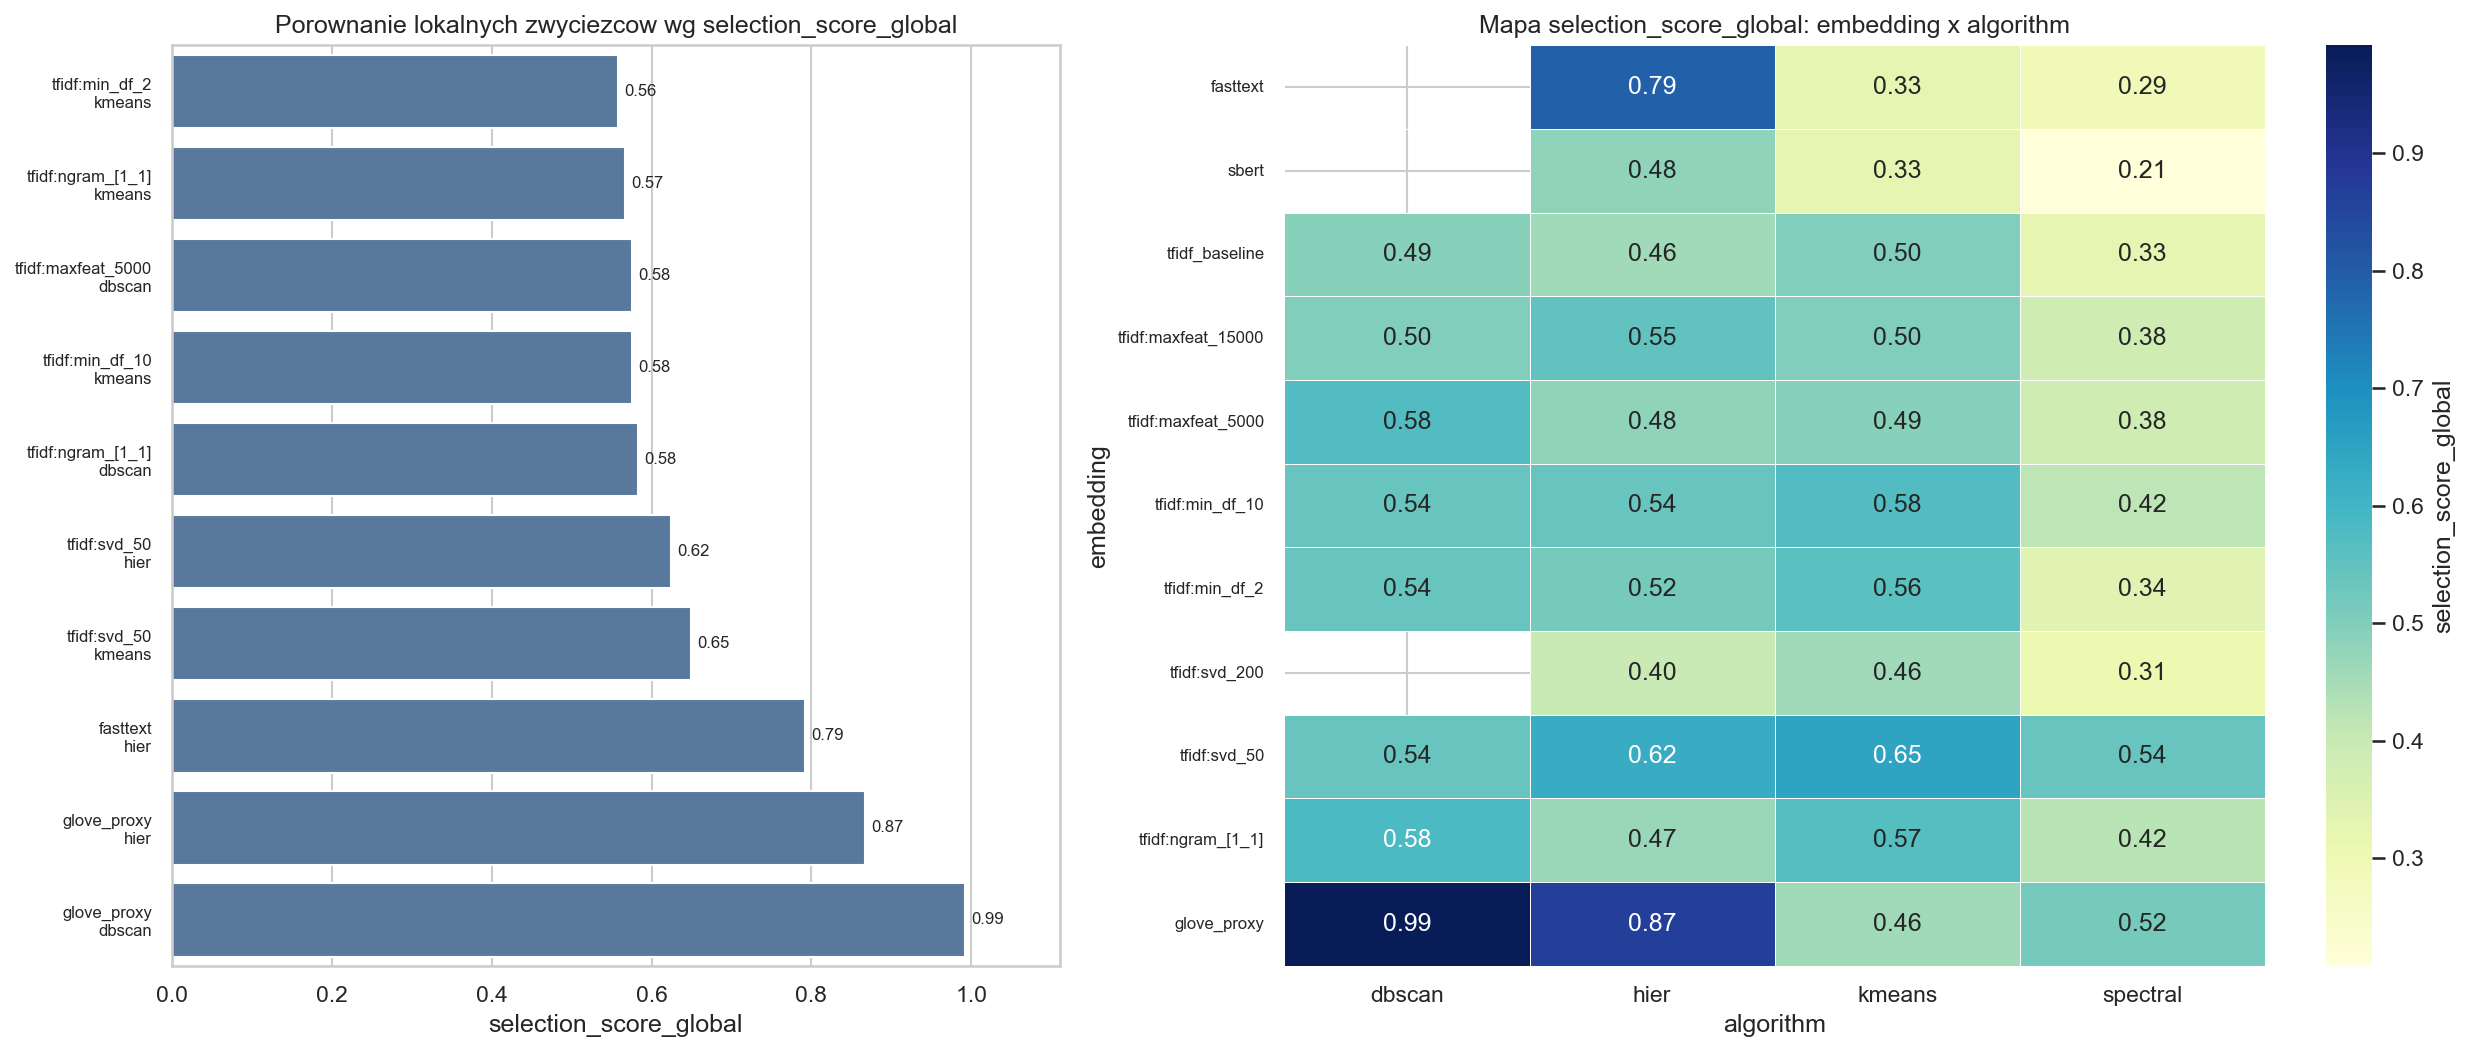

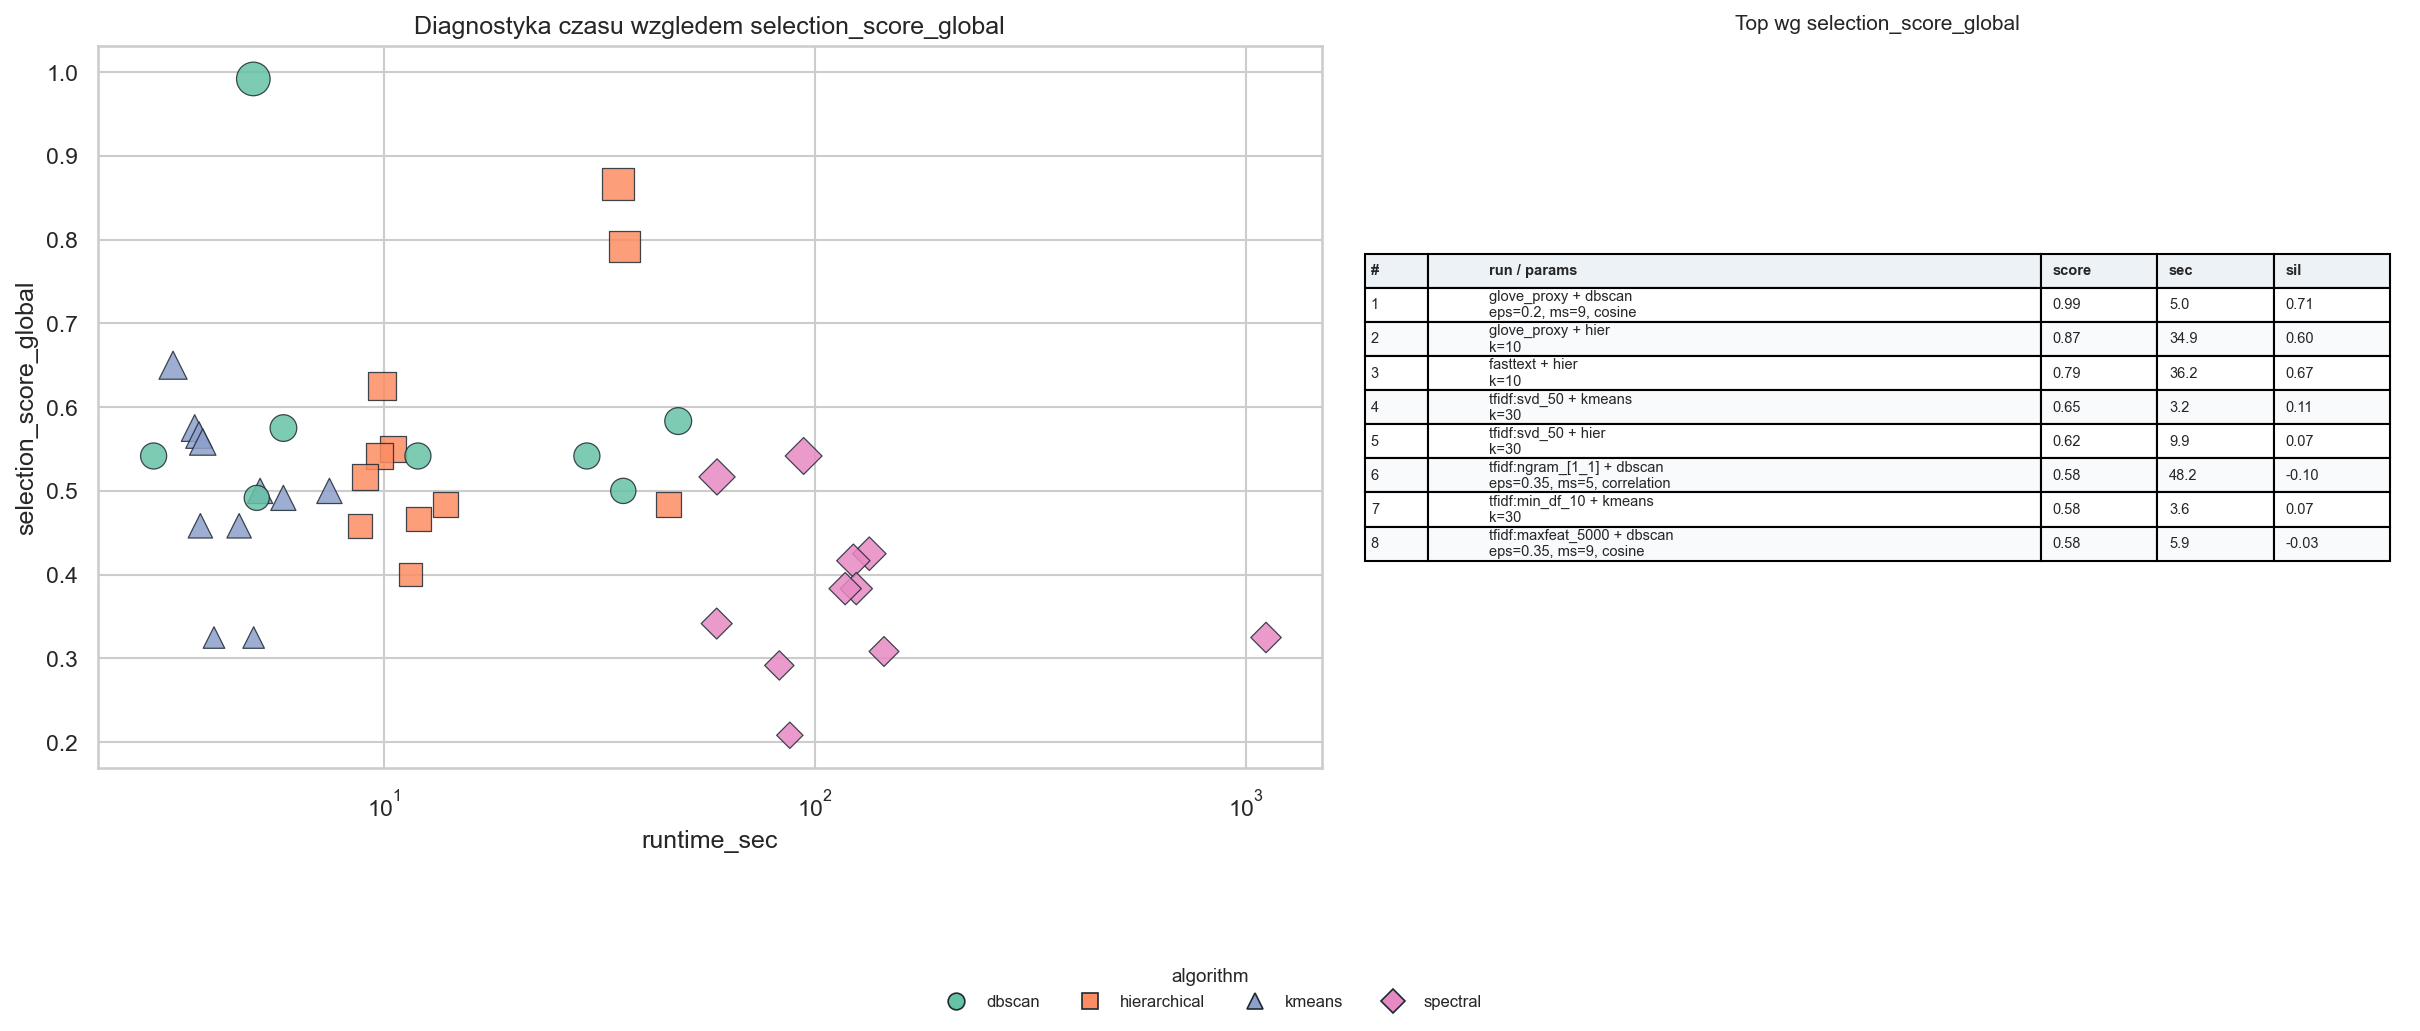

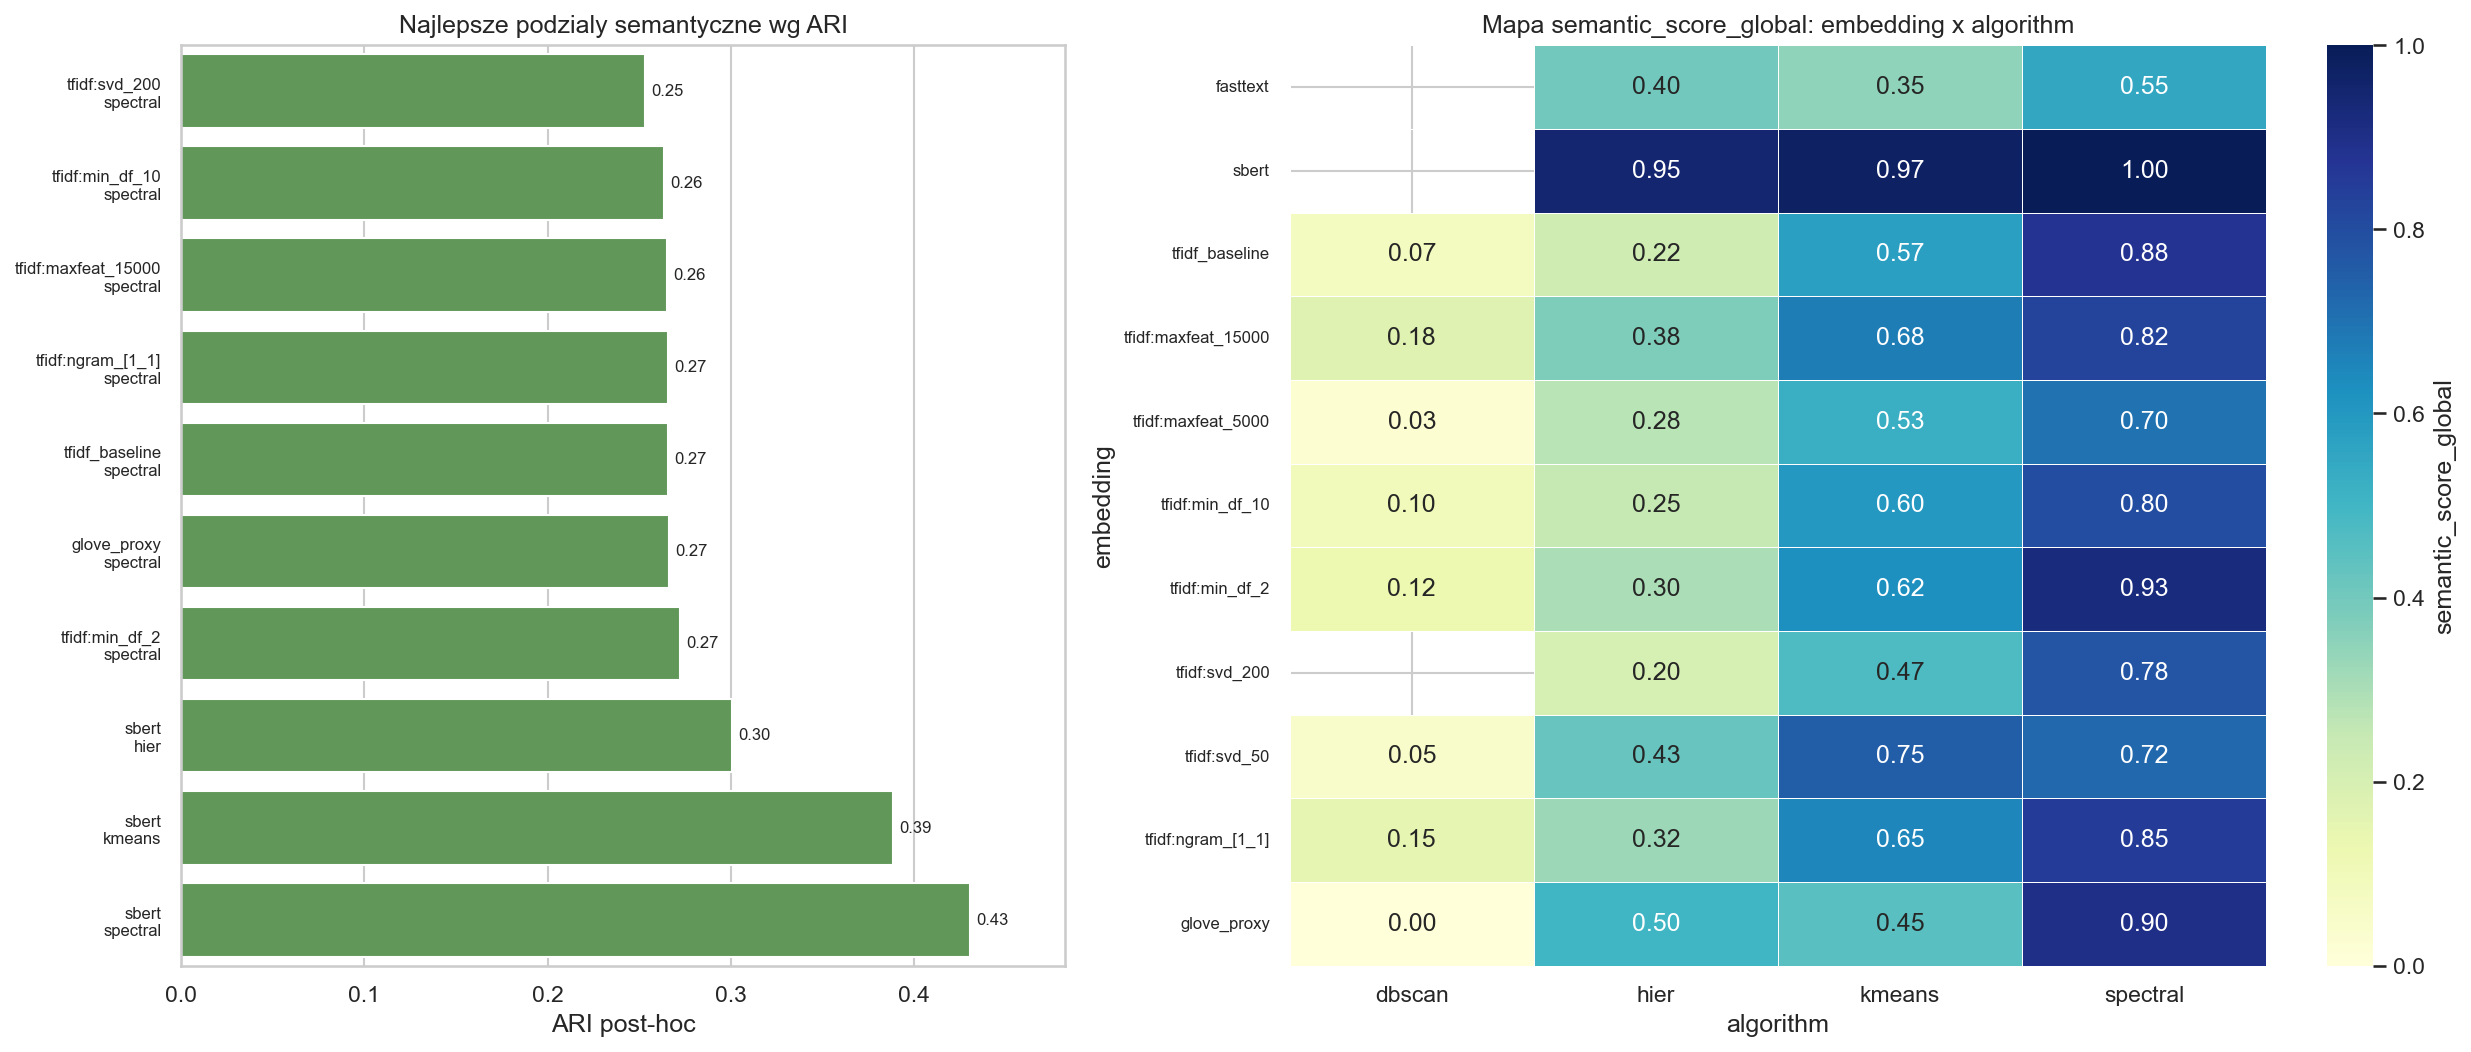

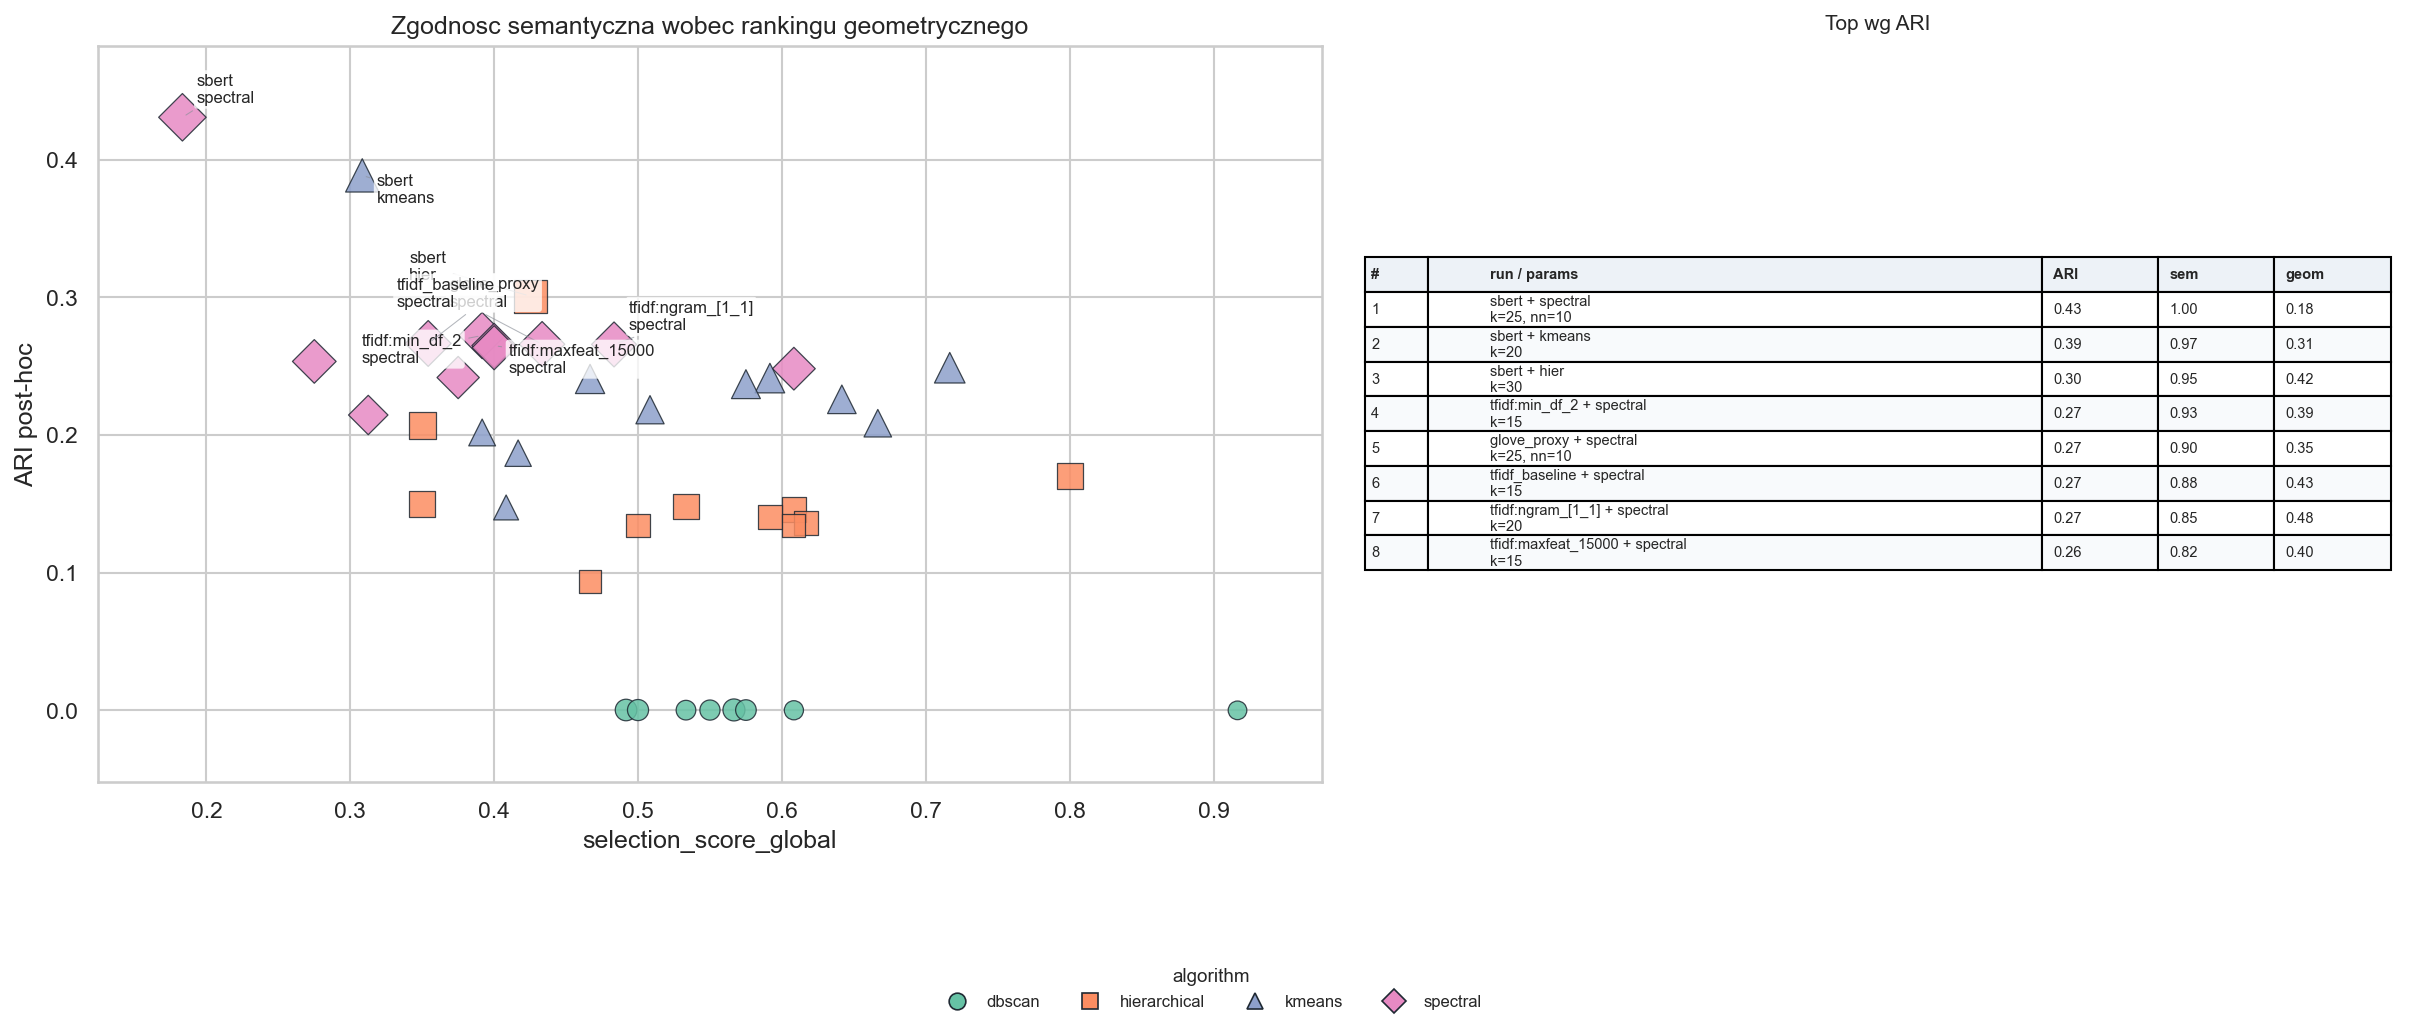


---
### Tabela 7A: `local_winners_table` — lokalni zwyciezcy hiperparametrow

Ta tabela odpowiada na pytanie: **ktory przebieg jest najlepszy wewnatrz danej pary `(embedding_name, algorithm)`?**

Do tego sluzy `selection_score_local`. Jest on liczony osobno w kazdej rodzinie modeli, wiec nadaje sie do wyboru hiperparametrow w tej rodzinie, ale nie do bezposredniego porownania roznych rodzin.


,embedding_name,embedding_label,algorithm,k,eps,min_samples,n_neighbors,affinity,assign_labels,n_init,...,silhouette_global_rank_score,dunn_global_rank_score,davies_bouldin_global_rank_score,pareto_front,silhouette,davies_bouldin,dunn,ari,runtime_sec,selection_summary
0,fasttext,fastText wiki-news 300,hierarchical,10,NaN,NaN,NaN,None,None,NaN,...,0.975,0.425,0.975,True,0.665309,0.873007,0.072902,-0.000027,36.170704,local=0.741; global=0.792; sil=0.665; db=0.873...
1,fasttext,fastText wiki-news 300,kmeans,10,NaN,NaN,NaN,None,None,10.0,...,0.275,0.275,0.425,True,0.020343,3.325837,0.027630,0.112725,4.038428,local=0.750; global=0.325; sil=0.020; db=3.326...
2,fasttext,fastText wiki-news 300,spectral,10,NaN,NaN,10.0,nearest_neighbors,kmeans,NaN,...,0.225,0.000,0.650,True,0.017542,2.540292,0.001667,0.123866,82.743660,local=0.855; global=0.292; sil=0.018; db=2.540...
3,sbert,SBERT MiniLM-L6-v2,hierarchical,15,NaN,NaN,NaN,None,None,NaN,...,0.425,0.925,0.100,True,0.031917,3.828147,0.230700,0.166772,45.764194,local=0.741; global=0.483; sil=0.032; db=3.828...
4,sbert,SBERT MiniLM-L6-v2,kmeans,25,NaN,NaN,NaN,None,None,10.0,...,0.525,0.400,0.050,True,0.034188,4.184971,0.065735,0.373261,4.991194,local=0.667; global=0.325; sil=0.034; db=4.185...
5,sbert,SBERT MiniLM-L6-v2,spectral,20,NaN,NaN,20.0,nearest_neighbors,kmeans,NaN,...,0.350,0.200,0.075,True,0.021443,3.884920,0.017999,0.322887,87.511132,local=0.684; global=0.208; sil=0.021; db=3.885...
6,tfidf_baseline,Baseline,dbscan,-1,0.35,15.0,NaN,None,None,NaN,...,0.050,0.625,0.800,True,-0.075144,1.843532,0.117299,0.000197,5.074768,local=0.810; global=0.492; sil=-0.075; db=1.84...
7,tfidf_baseline,Baseline,hierarchical,30,NaN,NaN,NaN,None,None,NaN,...,0.500,0.700,0.175,True,0.034116,3.655216,0.163421,0.134067,8.797289,local=0.704; global=0.458; sil=0.034; db=3.655...
8,tfidf_baseline,Baseline,kmeans,30,NaN,NaN,NaN,None,None,10.0,...,0.750,0.450,0.300,True,0.065606,3.444605,0.075864,0.209666,5.166925,local=0.750; global=0.500; sil=0.066; db=3.445...
9,tfidf_baseline,Baseline,spectral,25,NaN,NaN,10.0,nearest_neighbors,kmeans,NaN,...,0.300,0.075,0.600,True,0.020358,2.566106,0.007751,0.093750,1113.753967,local=0.658; global=0.325; sil=0.020; db=2.566...



---
### Tabela 7B: `global_candidates_ranking` — porownanie lokalnych zwyciezcow

Ta tabela odpowiada na inne pytanie: **ktory z lokalnych zwyciezcow wyglada najlepiej globalnie?**

Tutaj uzywamy `selection_score_global`, liczacego rank-score wspolnie na `best_runs_df`, czyli juz po wyborze lokalnych zwyciezcow. Dopiero ten wynik jest porownywalny miedzy parami embedding + algorytm.


,rank,embedding_name,embedding_label,algorithm,k,eps,min_samples,n_neighbors,affinity,assign_labels,...,silhouette_global_rank_score,dunn_global_rank_score,davies_bouldin_global_rank_score,pareto_front,silhouette,davies_bouldin,dunn,ari,runtime_sec,selection_summary
0,1,word2vec_proxy_glove,Static proxy (GloVe 300),dbscan,-1,0.20,9.0,NaN,None,None,...,1.000,0.975,1.000,True,0.705826,0.515656,0.314321,-0.000007,4.982703,local=0.980; global=0.992; sil=0.706; db=0.516...
1,2,word2vec_proxy_glove,Static proxy (GloVe 300),hierarchical,10,NaN,NaN,NaN,None,None,...,0.950,0.725,0.925,True,0.599409,1.531115,0.173828,-0.000013,34.906592,local=0.815; global=0.867; sil=0.599; db=1.531...
2,3,fasttext,fastText wiki-news 300,hierarchical,10,NaN,NaN,NaN,None,None,...,0.975,0.425,0.975,True,0.665309,0.873007,0.072902,-0.000027,36.170704,local=0.741; global=0.792; sil=0.665; db=0.873...
3,4,tfidf_var_n_components_50,Variation: n_components_50,kmeans,30,NaN,NaN,NaN,None,None,...,0.925,0.350,0.675,True,0.108521,2.502815,0.048394,0.236754,3.245434,local=0.833; global=0.650; sil=0.109; db=2.503...
4,5,tfidf_var_n_components_50,Variation: n_components_50,hierarchical,30,NaN,NaN,NaN,None,None,...,0.875,0.375,0.625,True,0.073539,2.553389,0.052370,0.166407,9.917975,local=0.722; global=0.625; sil=0.074; db=2.553...
5,6,tfidf_var_ngram_range_[1_1],Variation: ngram_range_[1_1],dbscan,-1,0.35,5.0,NaN,None,None,...,0.025,0.825,0.900,True,-0.098918,1.672051,0.217029,0.000080,48.206587,local=0.833; global=0.583; sil=-0.099; db=1.67...
6,7,tfidf_var_min_df_10,Variation: min_df_10,kmeans,30,NaN,NaN,NaN,None,None,...,0.825,0.550,0.350,True,0.066282,3.417105,0.080986,0.225849,3.642818,local=0.750; global=0.575; sil=0.066; db=3.417...
7,8,tfidf_var_max_features_5000,Variation: max_features_5000,dbscan,-1,0.35,9.0,NaN,None,None,...,0.150,0.800,0.775,True,-0.028258,1.997319,0.190785,0.000052,5.852639,local=0.733; global=0.575; sil=-0.028; db=1.99...
8,9,tfidf_var_ngram_range_[1_1],Variation: ngram_range_[1_1],kmeans,30,NaN,NaN,NaN,None,None,...,0.775,0.525,0.400,True,0.065793,3.404912,0.079964,0.223719,3.728142,local=0.917; global=0.567; sil=0.066; db=3.405...
9,10,tfidf_var_min_df_2,Variation: min_df_2,kmeans,30,NaN,NaN,NaN,None,None,...,0.850,0.500,0.325,True,0.066285,3.425581,0.078578,0.234492,3.803106,local=0.833; global=0.558; sil=0.066; db=3.426...



---
### Tabela 7C: `best_embedding_per_algorithm` — najlepszy embedding dla kazdego algorytmu

Dla kazdego algorytmu wybieramy lokalnego zwyciezce z najwyzszym `selection_score_global`. To porownanie odbywa sie juz na wspolnej skali globalnej dla zwyciezcow.


...


---
### Tabela 7D: `best_algorithm_per_embedding` — najlepszy algorytm dla kazdego embeddingu

Dla kazdego embeddingu wybieramy algorytm z najwyzszym `selection_score_global`, czyli porownujemy tylko reprezentantow wybranych lokalnie.


,embedding_name,embedding_label,algorithm,k,eps,min_samples,n_neighbors,affinity,assign_labels,n_init,...,silhouette_global_rank_score,dunn_global_rank_score,davies_bouldin_global_rank_score,pareto_front,silhouette,davies_bouldin,dunn,ari,runtime_sec,selection_summary
0,fasttext,fastText wiki-news 300,hierarchical,10,NaN,NaN,NaN,None,None,NaN,...,0.975,0.425,0.975,True,0.665309,0.873007,0.072902,-0.000027,36.170704,local=0.741; global=0.792; sil=0.665; db=0.873...
1,sbert,SBERT MiniLM-L6-v2,hierarchical,15,NaN,NaN,NaN,None,None,NaN,...,0.425,0.925,0.100,True,0.031917,3.828147,0.230700,0.166772,45.764194,local=0.741; global=0.483; sil=0.032; db=3.828...
2,tfidf_baseline,Baseline,kmeans,30,NaN,NaN,NaN,None,None,10.0,...,0.750,0.450,0.300,True,0.065606,3.444605,0.075864,0.209666,5.166925,local=0.750; global=0.500; sil=0.066; db=3.445...
3,tfidf_var_max_features_15000,Variation: max_features_15000,hierarchical,30,NaN,NaN,NaN,None,None,NaN,...,0.575,0.875,0.200,True,0.034752,3.633976,0.222339,0.129845,10.494881,local=0.704; global=0.550; sil=0.035; db=3.634...
4,tfidf_var_max_features_5000,Variation: max_features_5000,dbscan,-1,0.35,9.0,NaN,None,None,NaN,...,0.150,0.800,0.775,True,-0.028258,1.997319,0.190785,0.000052,5.852639,local=0.733; global=0.575; sil=-0.028; db=1.99...
5,tfidf_var_min_df_10,Variation: min_df_10,kmeans,30,NaN,NaN,NaN,None,None,10.0,...,0.825,0.550,0.350,True,0.066282,3.417105,0.080986,0.225849,3.642818,local=0.750; global=0.575; sil=0.066; db=3.417...
6,tfidf_var_min_df_2,Variation: min_df_2,kmeans,30,NaN,NaN,NaN,None,None,10.0,...,0.850,0.500,0.325,True,0.066285,3.425581,0.078578,0.234492,3.803106,local=0.833; global=0.558; sil=0.066; db=3.426...
7,tfidf_var_n_components_200,Variation: n_components_200,kmeans,30,NaN,NaN,NaN,None,None,10.0,...,0.675,0.675,0.025,True,0.043206,4.269418,0.132443,0.195093,4.618681,local=1.000; global=0.458; sil=0.043; db=4.269...
8,tfidf_var_n_components_50,Variation: n_components_50,kmeans,30,NaN,NaN,NaN,None,None,10.0,...,0.925,0.350,0.675,True,0.108521,2.502815,0.048394,0.236754,3.245434,local=0.833; global=0.650; sil=0.109; db=2.503...
9,tfidf_var_ngram_range_[1_1],Variation: ngram_range_[1_1],dbscan,-1,0.35,5.0,NaN,None,None,NaN,...,0.025,0.825,0.900,True,-0.098918,1.672051,0.217029,0.000080,48.206587,local=0.833; global=0.583; sil=-0.099; db=1.67...



---
### Tabela 7E: `semantic_candidates_ranking` — najlepszy podzial semantyczny

Ta tabela odpowiada na pytanie: **ktory lokalny zwyciezca najlepiej zgadza sie z kategoriami `20 Newsgroups`?**

Do tego sluzy `semantic_score_global`, liczony na podstawie `ARI`. Jest to ranking post-hoc: korzysta z etykiet tylko do interpretacji i kontroli, a nie do uczenia klastrow.


,semantic_rank,embedding_name,embedding_label,algorithm,k,eps,min_samples,n_neighbors,affinity,assign_labels,...,dunn_global_rank_score,davies_bouldin_global_rank_score,pareto_front,silhouette,davies_bouldin,dunn,ari,runtime_sec,selection_summary,semantic_selection_summary
0,1,sbert,SBERT MiniLM-L6-v2,spectral,25,NaN,NaN,10.0,nearest_neighbors,discretize,...,0.0500,0.125,False,0.024317,4.330341,9.090380e-08,0.430651,51.762814,local=0.359; global=0.183; sil=0.024; db=4.330...,semantic_local=1.000; semantic_global=1.000; a...
1,2,sbert,SBERT MiniLM-L6-v2,kmeans,20,NaN,NaN,NaN,None,None,...,0.3500,0.075,False,0.033932,4.451910,6.544230e-02,0.388474,4.836189,local=0.250; global=0.308; sil=0.034; db=4.452...,semantic_local=1.000; semantic_global=0.975; a...
2,3,sbert,SBERT MiniLM-L6-v2,hierarchical,30,NaN,NaN,NaN,None,None,...,0.9750,0.000,False,0.014274,4.997269,3.369778e-01,0.300771,19.492269,local=0.315; global=0.425; sil=0.014; db=4.997...,semantic_local=1.000; semantic_global=0.950; a...
3,4,tfidf_var_min_df_2,Variation: min_df_2,spectral,15,NaN,NaN,NaN,rbf,discretize,...,0.1250,0.325,False,0.049038,3.917772,4.823303e-04,0.272177,44.773261,local=0.342; global=0.392; sil=0.049; db=3.918...,semantic_local=1.000; semantic_global=0.925; a...
4,5,word2vec_proxy_glove,Static proxy (GloVe 300),spectral,25,NaN,NaN,10.0,nearest_neighbors,discretize,...,0.0125,0.725,False,0.016011,3.196864,0.000000e+00,0.266404,61.439913,local=0.291; global=0.354; sil=0.016; db=3.197...,semantic_local=1.000; semantic_global=0.900; a...
5,6,tfidf_baseline,Baseline,spectral,15,NaN,NaN,NaN,rbf,discretize,...,0.1750,0.425,False,0.048725,3.885036,2.789673e-03,0.265854,109.578287,local=0.410; global=0.433; sil=0.049; db=3.885...,semantic_local=1.000; semantic_global=0.875; a...
6,7,tfidf_var_ngram_range_[1_1],Variation: ngram_range_[1_1],spectral,20,NaN,NaN,NaN,rbf,discretize,...,0.1000,0.550,False,0.055022,3.570152,3.370959e-04,0.265697,43.391502,local=0.444; global=0.483; sil=0.055; db=3.570...,semantic_local=1.000; semantic_global=0.850; a...
7,8,tfidf_var_max_features_15000,Variation: max_features_15000,spectral,15,NaN,NaN,NaN,rbf,discretize,...,0.1500,0.375,False,0.048602,3.897208,5.053345e-04,0.264857,51.571459,local=0.359; global=0.400; sil=0.049; db=3.897...,semantic_local=1.000; semantic_global=0.825; a...
8,9,tfidf_var_min_df_10,Variation: min_df_10,spectral,15,NaN,NaN,NaN,rbf,discretize,...,0.2000,0.350,False,0.048481,3.898511,3.020058e-03,0.263317,39.859112,local=0.393; global=0.400; sil=0.048; db=3.899...,semantic_local=1.000; semantic_global=0.800; a...
9,10,tfidf_var_n_components_200,Variation: n_components_200,spectral,20,NaN,NaN,NaN,rbf,discretize,...,0.2250,0.025,False,0.035706,4.734290,3.432748e-03,0.253371,42.022303,local=0.453; global=0.275; sil=0.036; db=4.734...,semantic_local=1.000; semantic_global=0.775; a...


{'global_candidates_heatmap': 'artifacts_full/plots/section7_global_candidates_heatmap.png',
 'global_selection_runtime': 'artifacts_full/plots/section7_global_selection_runtime.png',
 'semantic_candidates_heatmap': 'artifacts_full/plots/section7_semantic_candidates_heatmap.png',
 'semantic_ari_selection_tradeoff': 'artifacts_full/plots/section7_semantic_ari_selection_tradeoff.png'}

In [16]:
from IPython.display import Markdown

best_runs_df = select_best_runs(results_df, config=CONFIG)
best_runs_df = add_dunn_scores(
    best_runs_df=best_runs_df,
    dataset_df=dataset_df,
    dataset_views=dataset_views,
    embedding_views=embedding_views,
    config=CONFIG,
)

semantic_best_runs_df = select_semantic_best_runs(results_df, config=CONFIG)
comparison_views = build_comparison_views(best_runs_df)
semantic_comparison_views = build_comparison_views(semantic_best_runs_df)
plot_paths = create_best_runs_plots(best_runs_df, CONFIG)
semantic_plot_paths = create_semantic_best_runs_plots(semantic_best_runs_df, CONFIG)
plot_paths = {**plot_paths, **semantic_plot_paths}
print(summarize_best_runs(best_runs_df, semantic_best_runs_df))
display_best_runs_plots(plot_paths)

display(Markdown("""
---
### Tabela 7A: `local_winners_table` — lokalni zwyciezcy hiperparametrow

Ta tabela odpowiada na pytanie: **ktory przebieg jest najlepszy wewnatrz danej pary `(embedding_name, algorithm)`?**

Do tego sluzy `selection_score_local`. Jest on liczony osobno w kazdej rodzinie modeli, wiec nadaje sie do wyboru hiperparametrow w tej rodzinie, ale nie do bezposredniego porownania roznych rodzin.
"""))
display(comparison_views["local_winners_table"])

display(Markdown("""
---
### Tabela 7B: `global_candidates_ranking` — porownanie lokalnych zwyciezcow

Ta tabela odpowiada na inne pytanie: **ktory z lokalnych zwyciezcow wyglada najlepiej globalnie?**

Tutaj uzywamy `selection_score_global`, liczacego rank-score wspolnie na `best_runs_df`, czyli juz po wyborze lokalnych zwyciezcow. Dopiero ten wynik jest porownywalny miedzy parami embedding + algorytm.
"""))
display(comparison_views["global_candidates_ranking"])

display(Markdown("""
---
### Tabela 7C: `best_embedding_per_algorithm` — najlepszy embedding dla kazdego algorytmu

Dla kazdego algorytmu wybieramy lokalnego zwyciezce z najwyzszym `selection_score_global`. To porownanie odbywa sie juz na wspolnej skali globalnej dla zwyciezcow.
"""))
display(comparison_views["best_embedding_per_algorithm"])

display(Markdown("""
---
### Tabela 7D: `best_algorithm_per_embedding` — najlepszy algorytm dla kazdego embeddingu

Dla kazdego embeddingu wybieramy algorytm z najwyzszym `selection_score_global`, czyli porownujemy tylko reprezentantow wybranych lokalnie.
"""))
display(comparison_views["best_algorithm_per_embedding"])

display(Markdown("""
---
### Tabela 7E: `semantic_candidates_ranking` — najlepszy podzial semantyczny

Ta tabela odpowiada na pytanie: **ktory lokalny zwyciezca najlepiej zgadza sie z kategoriami `20 Newsgroups`?**

Do tego sluzy `semantic_score_global`, liczony na podstawie `ARI`. Jest to ranking post-hoc: korzysta z etykiet tylko do interpretacji i kontroli, a nie do uczenia klastrow.
"""))
display(semantic_comparison_views["semantic_candidates_ranking"])
plot_paths


## 8. Czesc interpretacyjna klastrow

Metryki globalne nie wystarczaja do zrozumienia, co model rzeczywiscie pogrupowal. Najlepsze dopasowanie geometryczne moze wskazywac zwarte i dobrze odseparowane klastry, ale nie gwarantuje, ze te klastry odpowiadaja kategoriom tematycznym. Dlatego w tej sekcji interpretujemy lacznie najlepszych kandydatow geometrycznych z sekcji 7 oraz najlepszych kandydatow semantycznych wybranych wg `ARI`.

W tej sekcji wykorzystujemy:

1. **Opis leksykalny klastra**: najczestsze slowa, slowa odrozniajace oraz WordCloud.
2. **Interpretacje geometryczna**: dokumenty centralne i graniczne.
3. **Diagnostyke etykiet post-hoc**: dominujaca etykieta, purity i entropia etykiet.
4. **Diagnostyke strukturalna**: rozmiar klastra, udzial w zbiorze, singletony/male klastry i klastry gigantyczne.

Purity i entropia sa przydatne, ale wymagaja ostroznosci. Purity `1.0` w klastrze jednoelementowym nie jest dowodem dobrego modelu, tylko skutkiem malego rozmiaru. Dlatego listy „najczystszych” klastrów filtrujemy przez minimalny rozmiar, a globalnie raportujemy zarowno metryki wazone rozmiarem klastra, jak i makro-metryki pokazujace fragmentacje.

`ARI`, purity i entropia nie wplywaja na wybor geometryczny `best_runs`. `ARI` tworzy osobny ranking semantyczny, a purity, entropia, WordCloud i dokumenty przykladowe sluza do interpretacji oraz kontroli, czy wybrany podzial ma sens tematyczny.


In [17]:
RUN_IDENTITY_COLUMNS = [
    "embedding_name",
    "algorithm",
    "k",
    "eps",
    "min_samples",
    "n_neighbors",
    "affinity",
    "assign_labels",
    "metric",
    "linkage",
    "n_init",
]


def normalize_run_identity_value(value: Any) -> Any:
    if value is None or pd.isna(value):
        return "na"
    if isinstance(value, (np.integer, int)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        return round(float(value), 8)
    return str(value)


def run_identity_tuple(row: pd.Series) -> Tuple[Tuple[str, Any], ...]:
    return tuple(
        (column, normalize_run_identity_value(row.get(column, np.nan)))
        for column in RUN_IDENTITY_COLUMNS
    )


def interpretation_source_rank(source: Any) -> int:
    source_text = str(source)
    if "geometry" in source_text and "semantic" in source_text:
        return 0
    if "geometry" in source_text:
        return 1
    return 2


def build_interpretation_candidates(
    best_runs_df: pd.DataFrame,
    semantic_best_runs_df: Optional[pd.DataFrame] = None,
    top_per_source: int = 3,
) -> pd.DataFrame:
    frames: List[pd.DataFrame] = []
    if not best_runs_df.empty:
        geometry_df = (
            best_runs_df
            .sort_values(["selection_score_global", "silhouette", "dunn"], ascending=[False, False, False])
            .head(top_per_source)
            .copy()
        )
        geometry_df["interpretation_source"] = "geometry"
        geometry_df["_source_order"] = 0
        frames.append(geometry_df)

    if semantic_best_runs_df is not None and not semantic_best_runs_df.empty:
        semantic_sort_columns = [
            column for column in ["semantic_score_global", "ari", "selection_score_global", "silhouette"]
            if column in semantic_best_runs_df.columns
        ]
        semantic_df = (
            semantic_best_runs_df
            .sort_values(semantic_sort_columns, ascending=[False] * len(semantic_sort_columns))
            .head(top_per_source)
            .copy()
        )
        semantic_df["interpretation_source"] = "semantic"
        semantic_df["_source_order"] = 1
        frames.append(semantic_df)

    if not frames:
        return pd.DataFrame()

    combined = pd.concat(frames, axis=0, ignore_index=True, sort=False)
    combined["_run_identity"] = combined.apply(run_identity_tuple, axis=1)

    merged_rows: List[pd.Series] = []
    for _, group in combined.groupby("_run_identity", sort=False):
        group = group.sort_values("_source_order")
        base = group.iloc[0].copy()
        sources: List[str] = []
        for source in group["interpretation_source"].astype(str):
            for source_part in source.split("+"):
                if source_part not in sources:
                    sources.append(source_part)
        for _, candidate in group.iterrows():
            for column in combined.columns:
                if column.startswith("_") or column == "interpretation_source":
                    continue
                if column not in base.index or pd.isna(base.get(column, np.nan)):
                    value = candidate.get(column, np.nan)
                    if pd.notna(value):
                        base[column] = value
        base["interpretation_source"] = "+".join(sources)
        merged_rows.append(base)

    candidates_df = pd.DataFrame(merged_rows).drop(columns=["_run_identity", "_source_order"], errors="ignore")
    candidates_df["interpretation_source_rank"] = candidates_df["interpretation_source"].map(interpretation_source_rank)
    for column in ["semantic_score_global", "selection_score_global", "ari", "silhouette"]:
        if column not in candidates_df.columns:
            candidates_df[column] = np.nan
    candidates_df = candidates_df.sort_values(
        ["interpretation_source_rank", "selection_score_global", "semantic_score_global", "ari", "silhouette"],
        ascending=[True, False, False, False, False],
    ).reset_index(drop=True)
    candidates_df["interpretation_candidate_id"] = np.arange(1, len(candidates_df) + 1)
    return candidates_df


def missing_embedding_names(
    runs_df: pd.DataFrame,
    embedding_views: Dict[str, Dict[str, Any]],
) -> List[str]:
    if runs_df.empty or "embedding_name" not in runs_df.columns:
        return []
    available_embeddings = set(embedding_views.keys())
    run_embeddings = set(runs_df["embedding_name"].dropna().astype(str))
    return sorted(run_embeddings - available_embeddings)


def filter_runs_with_available_embeddings(
    runs_df: pd.DataFrame,
    embedding_views: Dict[str, Dict[str, Any]],
    context: str,
) -> pd.DataFrame:
    if runs_df.empty or "embedding_name" not in runs_df.columns:
        return runs_df.copy()

    missing = missing_embedding_names(runs_df, embedding_views)
    if missing:
        print(
            f"Pominieto {context} dla reprezentacji nieobecnych w embedding_views: "
            f"{', '.join(missing)}. "
            "Uruchom ponownie sekcje budowania reprezentacji, jesli te przebiegi maja byc interpretowane."
        )

    available_embeddings = set(embedding_views.keys())
    return (
        runs_df[runs_df["embedding_name"].astype(str).isin(available_embeddings)]
        .copy()
        .reset_index(drop=True)
    )


def explain_best_runs(
    best_runs_df: pd.DataFrame,
    dataset_df: pd.DataFrame,
    dataset_views: Dict[str, np.ndarray],
    embedding_views: Dict[str, Dict[str, Any]],
    config: Dict[str, Any],
) -> Tuple[pd.DataFrame, List[Dict[str, Any]], pd.DataFrame]:
    profile_rows: List[Dict[str, Any]] = []
    cluster_examples: List[Dict[str, Any]] = []
    run_summary_rows: List[Dict[str, Any]] = []
    min_cluster_size = int(config.get("wordcloud_min_cluster_size", 10))
    best_runs_df = filter_runs_with_available_embeddings(
        best_runs_df,
        embedding_views=embedding_views,
        context="interpretacje klastrow",
    )
    if best_runs_df.empty:
        return pd.DataFrame(), [], pd.DataFrame()

    for _, row in best_runs_df.iterrows():
        subset_name = row["algorithm"] if row["algorithm"] in dataset_views else "kmeans"
        embedding_view = embedding_views[str(row["embedding_name"])]
        X, fit_df = select_embedding_subset(
            dataset_df=dataset_df,
            embedding_view=embedding_view,
            requested_doc_ids=dataset_views[subset_name],
        )
        params = params_from_row(row)
        model, labels = refit_model(X=X, params=params, seed=config["seed"])
        run_profiles, run_examples = interpret_single_run(
            fit_df=fit_df,
            X=X,
            labels=labels,
            model=model,
            row=row,
            top_terms=int(config["explain_top_terms"]),
            top_docs=int(config["explain_top_docs"]),
            max_features=int(config["interpretation_max_features"]),
            min_cluster_size=min_cluster_size,
        )
        profile_rows.extend(run_profiles)
        cluster_examples.extend(run_examples)

        run_summary_rows.extend(
            summarize_run_interpretation(
                run_profiles=run_profiles,
                run_row=row,
            )
        )

    profiles_df = pd.DataFrame(profile_rows)
    run_summary_df = pd.DataFrame(run_summary_rows)
    return profiles_df, cluster_examples, run_summary_df


def refit_model(
    X: np.ndarray, params: Dict[str, Any], seed: int
) -> Tuple[Any, np.ndarray]:
    if params["algorithm"] == "kmeans":
        model = KMeans(
            n_clusters=params["k"],
            n_init=params["n_init"],
            max_iter=params["max_iter"],
            random_state=seed,
        )
    elif params["algorithm"] == "hierarchical":
        model = AgglomerativeClustering(
            n_clusters=params["k"],
            metric=params["metric"],
            linkage=params["linkage"],
        )
    elif params["algorithm"] == "dbscan":
        model = DBSCAN(eps=params["eps"], min_samples=params["min_samples"], metric=params["metric"])
    else:
        model_kwargs = {
            "n_clusters": params["k"],
            "random_state": seed,
            "affinity": params["affinity"],
            "assign_labels": params["assign_labels"],
        }
        if params["affinity"] == "nearest_neighbors":
            model_kwargs["n_neighbors"] = params.get("n_neighbors", 10)
        model = SpectralClustering(**model_kwargs)
    labels = model.fit_predict(X)
    return model, labels


def interpret_single_run(
    fit_df: pd.DataFrame,
    X: np.ndarray,
    labels: np.ndarray,
    model: Any,
    row: pd.Series,
    top_terms: int,
    top_docs: int,
    max_features: int,
    min_cluster_size: int,
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    texts = fit_df["analysis_text"].fillna("").replace("", "emptytoken").tolist()
    count_vectorizer = CountVectorizer(max_features=max_features)
    tfidf_vectorizer = TfidfVectorizer(max_features=max_features)
    count_matrix = count_vectorizer.fit_transform(texts)
    tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
    count_vocab = np.array(count_vectorizer.get_feature_names_out())
    tfidf_vocab = np.array(tfidf_vectorizer.get_feature_names_out())
    n_docs = max(int(len(fit_df)), 1)
    n_unique_targets_global = max(int(fit_df["target_name"].nunique()), 1)
    max_entropy = math.log2(n_unique_targets_global) if n_unique_targets_global > 1 else 1.0

    profiles: List[Dict[str, Any]] = []
    examples: List[Dict[str, Any]] = []

    for cluster_id in sorted(np.unique(labels)):
        cluster_mask = labels == cluster_id
        outside_mask = ~cluster_mask
        cluster_size = int(cluster_mask.sum())
        cluster_share = float(cluster_size / n_docs)

        mean_counts = np.asarray(count_matrix[cluster_mask].mean(axis=0)).ravel()
        frequent_idx = np.argsort(mean_counts)[::-1][:top_terms]
        frequent_words = [word for word in count_vocab[frequent_idx] if mean_counts.any()]

        mean_tfidf_cluster = np.asarray(tfidf_matrix[cluster_mask].mean(axis=0)).ravel()
        if outside_mask.sum() > 0:
            mean_tfidf_outside = np.asarray(tfidf_matrix[outside_mask].mean(axis=0)).ravel()
        else:
            mean_tfidf_outside = np.zeros_like(mean_tfidf_cluster)
        distinctive_scores = mean_tfidf_cluster - mean_tfidf_outside
        distinctive_idx = np.argsort(distinctive_scores)[::-1][:top_terms]
        distinctive_words = [
            word for word in tfidf_vocab[distinctive_idx] if distinctive_scores.any()
        ]

        label_stats = compute_target_label_stats(
            target_names=fit_df.loc[cluster_mask, "target_name"].astype(str),
            max_entropy=max_entropy,
        )
        target_entropy_normalized = label_stats["target_entropy_normalized"]
        is_tiny_cluster = cluster_size < min_cluster_size
        is_giant_cluster = cluster_share > 0.50
        is_label_pure = (
            cluster_size >= min_cluster_size
            and pd.notna(label_stats["dominant_target_share"])
            and label_stats["dominant_target_share"] >= 0.65
        )
        is_mixed_cluster = (
            pd.notna(target_entropy_normalized)
            and target_entropy_normalized >= 0.75
        )

        central_indices, boundary_indices = representative_doc_indices(
            X=X,
            labels=labels,
            cluster_id=int(cluster_id),
            model=model,
            algorithm=row["algorithm"],
            metric=row["metric"],
            top_docs=top_docs,
        )

        representative_docs = build_doc_records(
            fit_df=fit_df,
            local_indices=central_indices,
            role="central",
        )
        boundary_docs = build_doc_records(
            fit_df=fit_df,
            local_indices=boundary_indices,
            role="boundary",
        )

        interpretation_note = build_cluster_note(
            cluster_size=cluster_size,
            cluster_share=cluster_share,
            label_stats=label_stats,
            frequent_words=frequent_words,
            distinctive_words=distinctive_words,
            is_tiny_cluster=is_tiny_cluster,
            is_giant_cluster=is_giant_cluster,
            is_mixed_cluster=is_mixed_cluster,
        )

        profiles.append(
            {
                "interpretation_candidate_id": int(row.get("interpretation_candidate_id", -1)) if pd.notna(row.get("interpretation_candidate_id", np.nan)) else -1,
                "interpretation_source": row.get("interpretation_source", "geometry"),
                "embedding_name": row["embedding_name"],
                "algorithm": row["algorithm"],
                "k": int(row["k"]),
                "metric": row["metric"],
                "linkage": row["linkage"] if pd.notna(row["linkage"]) else None,
                "cluster_id": int(cluster_id),
                "cluster_size": cluster_size,
                "cluster_share": cluster_share,
                "top_frequent_words": ", ".join(frequent_words),
                "top_distinctive_words": ", ".join(distinctive_words),
                "dominant_target": label_stats["dominant_target"],
                "dominant_target_share": label_stats["dominant_target_share"],
                "target_entropy": label_stats["target_entropy"],
                "target_entropy_normalized": target_entropy_normalized,
                "top_targets": label_stats["top_targets"],
                "is_tiny_cluster": bool(is_tiny_cluster),
                "is_giant_cluster": bool(is_giant_cluster),
                "is_label_pure": bool(is_label_pure),
                "is_mixed_cluster": bool(is_mixed_cluster),
                "interpretation_note": interpretation_note,
            }
        )
        examples.append(
            {
                "interpretation_candidate_id": int(row.get("interpretation_candidate_id", -1)) if pd.notna(row.get("interpretation_candidate_id", np.nan)) else -1,
                "interpretation_source": row.get("interpretation_source", "geometry"),
                "embedding_name": row["embedding_name"],
                "algorithm": row["algorithm"],
                "k": int(row["k"]),
                "metric": row["metric"],
                "linkage": row["linkage"] if pd.notna(row["linkage"]) else None,
                "cluster_id": int(cluster_id),
                "central_documents": representative_docs,
                "boundary_documents": boundary_docs,
            }
        )

    return profiles, examples


def representative_doc_indices(
    X: np.ndarray,
    labels: np.ndarray,
    cluster_id: int,
    model: Any,
    algorithm: str,
    metric: str,
    top_docs: int,
) -> Tuple[List[int], List[int]]:
    cluster_indices = np.where(labels == cluster_id)[0]
    if len(cluster_indices) == 0:
        return [], []

    if algorithm == "kmeans":
        distances = model.transform(X[cluster_indices])[:, cluster_id]
        ordered = cluster_indices[np.argsort(distances)]
    elif algorithm == "dbscan":
        cluster_vectors = X[cluster_indices]
        nn = NearestNeighbors(radius=model.eps, metric=metric)
        nn.fit(cluster_vectors)
        neighbors = nn.radius_neighbors(cluster_vectors, return_distance=False)
        densities = np.array([len(n) for n in neighbors])
        ordered = cluster_indices[np.argsort(-densities)]
    else:
        cluster_vectors = X[cluster_indices]
        dist_matrix = pairwise_distances(cluster_vectors, metric=metric)
        centrality = dist_matrix.mean(axis=1)
        ordered = cluster_indices[np.argsort(centrality)]

    docs_per_role = min(top_docs, len(ordered) // 2)
    if docs_per_role == 0:
        return ordered[:1].tolist(), []

    central = ordered[:docs_per_role].tolist()
    boundary = ordered[-docs_per_role:][::-1].tolist()
    return central, boundary


def build_doc_records(
    fit_df: pd.DataFrame,
    local_indices: List[int],
    role: str,
) -> List[Dict[str, Any]]:
    records: List[Dict[str, Any]] = []
    for local_idx in local_indices:
        record = fit_df.iloc[local_idx]
        records.append(
            {
                "role": role,
                "doc_id": int(record["doc_id"]),
                "target_name": str(record["target_name"]),
                "excerpt": truncate_text(record["text_clean_basic"]),
            }
        )
    return records


def compute_target_label_stats(target_names: pd.Series, max_entropy: float) -> Dict[str, Any]:
    label_counts = target_names.value_counts()
    total = int(label_counts.sum())
    if total == 0:
        return {
            "dominant_target": "unknown",
            "dominant_target_share": float("nan"),
            "target_entropy": float("nan"),
            "target_entropy_normalized": float("nan"),
            "top_targets": "",
        }

    probs = (label_counts / total).to_numpy(dtype=float)
    entropy = max(0.0, float(-(probs * np.log2(probs + 1e-12)).sum()))
    normalized_entropy = float(min(1.0, entropy / max_entropy)) if max_entropy > 0 else float("nan")

    dominant_target = str(label_counts.index[0])
    dominant_share = float(label_counts.iloc[0] / total)
    top_targets = ", ".join(
        [f"{name}:{count}" for name, count in label_counts.head(3).items()]
    )

    return {
        "dominant_target": dominant_target,
        "dominant_target_share": dominant_share,
        "target_entropy": entropy,
        "target_entropy_normalized": normalized_entropy,
        "top_targets": top_targets,
    }


def build_cluster_note(
    cluster_size: int,
    cluster_share: float,
    label_stats: Dict[str, Any],
    frequent_words: List[str],
    distinctive_words: List[str],
    is_tiny_cluster: bool,
    is_giant_cluster: bool,
    is_mixed_cluster: bool,
) -> str:
    lexical_hint = ", ".join(distinctive_words[:4] if distinctive_words else frequent_words[:4])
    if not lexical_hint:
        lexical_hint = "brak wyraznych tokenow"

    purity = label_stats["dominant_target_share"]
    if pd.isna(purity):
        purity_desc = "nieznana zgodnosc etykiet"
    elif is_tiny_cluster:
        purity_desc = "purity malo informacyjne (maly klaster)"
    elif purity >= 0.65:
        purity_desc = "wysoka zgodnosc etykiet post-hoc"
    elif purity >= 0.45:
        purity_desc = "srednia zgodnosc etykiet post-hoc"
    else:
        purity_desc = "niska zgodnosc etykiet post-hoc"

    structure_notes = []
    if is_giant_cluster:
        structure_notes.append("klaster gigantyczny")
    if is_mixed_cluster:
        structure_notes.append("wysoka entropia etykiet")
    structure_suffix = f"; {'; '.join(structure_notes)}" if structure_notes else ""

    return (
        f"Klaster {cluster_size} docs ({cluster_share:.1%}); dominant='{label_stats['dominant_target']}' "
        f"({purity:.2f}) - {purity_desc}{structure_suffix}; sygnatura: {lexical_hint}."
    )


def summarize_run_interpretation(
    run_profiles: List[Dict[str, Any]],
    run_row: pd.Series,
) -> List[Dict[str, Any]]:
    if not run_profiles:
        return []

    run_df = pd.DataFrame(run_profiles)
    total_docs = float(run_df["cluster_size"].sum())
    top_by_size = run_df.sort_values("cluster_size", ascending=False).head(3)
    purity_candidates = run_df[~run_df["is_tiny_cluster"]]
    if purity_candidates.empty:
        purity_candidates = run_df.iloc[0:0]
    top_by_purity = purity_candidates.sort_values(
        ["dominant_target_share", "cluster_size", "target_entropy_normalized"],
        ascending=[False, False, True],
    ).head(3)

    weighted_purity = float((run_df["dominant_target_share"] * run_df["cluster_size"]).sum() / total_docs)
    weighted_entropy = float((run_df["target_entropy"] * run_df["cluster_size"]).sum() / total_docs)
    weighted_normalized_entropy = float((run_df["target_entropy_normalized"] * run_df["cluster_size"]).sum() / total_docs)
    tiny_doc_count = float(run_df.loc[run_df["is_tiny_cluster"], "cluster_size"].sum())

    summary = {
        "interpretation_candidate_id": int(run_row.get("interpretation_candidate_id", -1)) if pd.notna(run_row.get("interpretation_candidate_id", np.nan)) else -1,
        "interpretation_source": run_row.get("interpretation_source", "geometry"),
        "embedding_name": run_row["embedding_name"],
        "algorithm": run_row["algorithm"],
        "k": int(run_row["k"]),
        "best_clusters_by_size": "; ".join(
            [
                f"#{int(r.cluster_id)} size={int(r.cluster_size)} dom={r.dominant_target}({r.dominant_target_share:.2f})"
                for r in top_by_size.itertuples()
            ]
        ),
        "best_clusters_by_purity": "; ".join(
            [
                f"#{int(r.cluster_id)} size={int(r.cluster_size)} dom={r.dominant_target}({r.dominant_target_share:.2f})"
                for r in top_by_purity.itertuples()
            ]
        ) if not top_by_purity.empty else "Brak klastrow powyzej minimalnego rozmiaru.",
        "weighted_purity": weighted_purity,
        "macro_purity": float(run_df["dominant_target_share"].mean()),
        "weighted_entropy": weighted_entropy,
        "macro_entropy": float(run_df["target_entropy"].mean()),
        "weighted_normalized_entropy": weighted_normalized_entropy,
        "macro_normalized_entropy": float(run_df["target_entropy_normalized"].mean()),
        "tiny_cluster_count": int(run_df["is_tiny_cluster"].sum()),
        "tiny_cluster_doc_share": float(tiny_doc_count / total_docs),
        "largest_cluster_share": float(run_df["cluster_share"].max()),
        "selection_score_global": float(run_row["selection_score_global"]) if "selection_score_global" in run_row.index else float("nan"),
        "selection_score_local": float(run_row["selection_score_local"]) if "selection_score_local" in run_row.index else float("nan"),
        "semantic_score_global": float(run_row["semantic_score_global"]) if "semantic_score_global" in run_row.index else float("nan"),
        "semantic_score_local": float(run_row["semantic_score_local"]) if "semantic_score_local" in run_row.index else float("nan"),
        "interpretation_source_rank": interpretation_source_rank(run_row.get("interpretation_source", "geometry")),
        "ari": float(run_row["ari"]) if "ari" in run_row.index else float("nan"),
    }
    return [summary]


def sort_interpretation_runs(run_summary_df: pd.DataFrame, top_runs: int) -> pd.DataFrame:
    sorted_df = run_summary_df.copy()
    if "interpretation_source_rank" not in sorted_df.columns:
        if "interpretation_source" in sorted_df.columns:
            sorted_df["interpretation_source_rank"] = sorted_df["interpretation_source"].map(interpretation_source_rank)
        else:
            sorted_df["interpretation_source_rank"] = interpretation_source_rank("geometry")
    for column in ["semantic_score_global", "selection_score_global", "ari", "weighted_normalized_entropy", "weighted_purity"]:
        if column not in sorted_df.columns:
            sorted_df[column] = np.nan
    return (
        sorted_df
        .sort_values(
            [
                "interpretation_source_rank",
                "selection_score_global",
                "semantic_score_global",
                "ari",
                "weighted_normalized_entropy",
                "weighted_purity",
            ],
            ascending=[True, False, False, False, True, False],
        )
        .head(top_runs)
        .reset_index(drop=True)
    )


def format_interpretation_markdown(
    run_summary_df: pd.DataFrame,
    cluster_profiles_df: pd.DataFrame,
    cluster_examples: List[Dict[str, Any]],
    top_runs: int = 3,
    min_cluster_size: int = 10,
) -> str:
    if run_summary_df.empty:
        return "Brak danych do interpretacji."

    top_rows = sort_interpretation_runs(run_summary_df, top_runs=top_runs)
    criteria_note = (
        f"Top {top_runs} przebiegow wybranych do interpretacji jako suma kandydatow geometrycznych "
        "wg `selection_score_global` oraz kandydatow semantycznych wg `ARI`. "
        "Purity, entropia, WordCloud i dokumenty przykladowe sluza do kontroli tematycznej, "
        "a nie do uczenia klastrow."
    )

    lines: List[str] = [
        "## Raport interpretacyjny klastrow (best runs)",
        "",
        f"> **Kryteria wyboru:** {criteria_note}",
        "",
    ]

    for rank, row in enumerate(top_rows.itertuples(index=False), start=1):
        run_name = f"{row.embedding_name} + {row.algorithm} (k={int(row.k)})"
        source_label = str(getattr(row, "interpretation_source", "geometry"))
        semantic_score = getattr(row, "semantic_score_global", np.nan)
        semantic_fragment = f" | semantic_score_global={semantic_score:.3f}" if pd.notna(semantic_score) else ""
        lines.append(f"### {rank}. {run_name}")
        lines.append("")
        lines.append(f"**Źródło wyboru:** {source_label}")
        lines.append(
            f"**Selection:** selection_score_global={row.selection_score_global:.3f}{semantic_fragment} | "
            f"ARI post-hoc={row.ari:.3f}"
        )
        lines.append(
            f"**Etykiety post-hoc:** weighted_purity={row.weighted_purity:.3f} | "
            f"weighted_entropy_norm={row.weighted_normalized_entropy:.3f} | "
            f"macro_purity={row.macro_purity:.3f}"
        )
        lines.append(
            f"**Struktura:** largest_cluster_share={row.largest_cluster_share:.3f} | "
            f"tiny_clusters={int(row.tiny_cluster_count)} | "
            f"tiny_doc_share={row.tiny_cluster_doc_share:.3f}"
        )
        lines.append("")
        lines.append(f"- Najwieksze klastry: {row.best_clusters_by_size}")
        lines.append(f"- Najczystsze klastry (cluster_size >= {min_cluster_size}): {row.best_clusters_by_purity}")
        lines.append("")

        candidate_id = getattr(row, "interpretation_candidate_id", np.nan)
        if "interpretation_candidate_id" in cluster_profiles_df.columns and pd.notna(candidate_id):
            run_mask = cluster_profiles_df["interpretation_candidate_id"].eq(int(candidate_id))
        else:
            run_mask = (
                (cluster_profiles_df["embedding_name"] == row.embedding_name)
                & (cluster_profiles_df["algorithm"] == row.algorithm)
                & (cluster_profiles_df["k"] == int(row.k))
            )
        run_profiles = (
            cluster_profiles_df[
                run_mask
                & (cluster_profiles_df["cluster_size"] >= min_cluster_size)
            ]
            .sort_values(
                ["dominant_target_share", "cluster_size", "target_entropy_normalized"],
                ascending=[False, False, True],
            )
            .head(3)
        )

        lines.append("**Top klastry wg purity post-hoc (po odfiltrowaniu malych klastrow):**")
        lines.append("")
        if run_profiles.empty:
            lines.append("Brak klastrow spelniajacych minimalny rozmiar.")
        else:
            lines.append("| cluster_id | size | share | dominant_target | purity | entropy_norm | flags |")
            lines.append("|---:|---:|---:|---|---:|---:|---|")
            for profile in run_profiles.itertuples(index=False):
                flags = []
                if profile.is_label_pure:
                    flags.append("label_pure")
                if profile.is_mixed_cluster:
                    flags.append("mixed")
                if profile.is_giant_cluster:
                    flags.append("giant")
                lines.append(
                    f"| {int(profile.cluster_id)} | {int(profile.cluster_size)} | "
                    f"{profile.cluster_share:.3f} | {profile.dominant_target} | "
                    f"{profile.dominant_target_share:.3f} | {profile.target_entropy_normalized:.3f} | "
                    f"{', '.join(flags) if flags else 'ok'} |"
                )
        lines.append("")

        selected_cluster_ids = [int(x) for x in run_profiles["cluster_id"].head(2).tolist()]
        related_examples = [
            item for item in cluster_examples
            if (
                ("interpretation_candidate_id" in item and pd.notna(candidate_id) and int(item["interpretation_candidate_id"]) == int(candidate_id))
                or (
                    item["embedding_name"] == row.embedding_name
                    and item["algorithm"] == row.algorithm
                    and item["k"] == int(row.k)
                )
            )
            and int(item["cluster_id"]) in selected_cluster_ids
        ]
        related_examples = sorted(related_examples, key=lambda x: x["cluster_id"])

        lines.append("**Przykladowe dokumenty (centralne i graniczne):**")
        lines.append("")
        for example in related_examples:
            lines.append(f"- Cluster {example['cluster_id']}")
            lines.append("  - Centralne:")
            for doc in example["central_documents"][:2]:
                lines.append(
                    f"    - doc_id={doc['doc_id']} | target={doc['target_name']}\n"
                    f"      > {doc['excerpt']}"
                )
            lines.append("  - Graniczne:")
            for doc in example["boundary_documents"][:2]:
                lines.append(
                    f"    - doc_id={doc['doc_id']} | target={doc['target_name']}\n"
                    f"      > {doc['excerpt']}"
                )
        lines.append("")
        lines.append("---")
        lines.append("")

    return "\n".join(lines)


def build_examples_dataframe(
    run_summary_df: pd.DataFrame,
    cluster_profiles_df: pd.DataFrame,
    cluster_examples: List[Dict[str, Any]],
    top_runs: int = 3,
    clusters_per_run: int = 2,
    docs_per_role: int = 2,
    min_cluster_size: int = 10,
) -> pd.DataFrame:
    if run_summary_df.empty:
        return pd.DataFrame()

    top_rows = sort_interpretation_runs(run_summary_df, top_runs=top_runs)
    rows: List[Dict[str, Any]] = []
    for run_rank, row in enumerate(top_rows.itertuples(index=False), start=1):
        candidate_id = getattr(row, "interpretation_candidate_id", np.nan)
        if "interpretation_candidate_id" in cluster_profiles_df.columns and pd.notna(candidate_id):
            run_mask = cluster_profiles_df["interpretation_candidate_id"].eq(int(candidate_id))
        else:
            run_mask = (
                (cluster_profiles_df["embedding_name"] == row.embedding_name)
                & (cluster_profiles_df["algorithm"] == row.algorithm)
                & (cluster_profiles_df["k"] == int(row.k))
            )
        run_profiles = (
            cluster_profiles_df[
                run_mask
                & (cluster_profiles_df["cluster_size"] >= min_cluster_size)
            ]
            .sort_values(
                ["dominant_target_share", "cluster_size", "target_entropy_normalized"],
                ascending=[False, False, True],
            )
            .head(clusters_per_run)
        )
        selected_cluster_ids = {int(x) for x in run_profiles["cluster_id"].tolist()}

        related_examples = [
            item for item in cluster_examples
            if (
                ("interpretation_candidate_id" in item and pd.notna(candidate_id) and int(item["interpretation_candidate_id"]) == int(candidate_id))
                or (
                    item["embedding_name"] == row.embedding_name
                    and item["algorithm"] == row.algorithm
                    and item["k"] == int(row.k)
                )
            )
            and int(item["cluster_id"]) in selected_cluster_ids
        ]

        for example in sorted(related_examples, key=lambda x: x["cluster_id"]):
            for role_key, role_label in [
                ("central_documents", "central"),
                ("boundary_documents", "boundary"),
            ]:
                for doc_rank, doc in enumerate(example[role_key][:docs_per_role], start=1):
                    rows.append(
                        {
                            "run_rank": run_rank,
                            "interpretation_candidate_id": int(getattr(row, "interpretation_candidate_id", -1)),
                            "interpretation_source": str(getattr(row, "interpretation_source", "geometry")),
                            "embedding": row.embedding_name,
                            "algorithm": row.algorithm,
                            "k": int(row.k),
                            "selection_score_global": float(row.selection_score_global),
                            "semantic_score_global": float(getattr(row, "semantic_score_global", np.nan)),
                            "cluster_id": int(example["cluster_id"]),
                            "doc_role": role_label,
                            "doc_rank": doc_rank,
                            "doc_id": int(doc["doc_id"]),
                            "target_name": str(doc["target_name"]),
                            "excerpt": str(doc["excerpt"]),
                        }
                    )

    if not rows:
        return pd.DataFrame()

    examples_df = pd.DataFrame(rows)
    return examples_df.sort_values(
        ["run_rank", "cluster_id", "doc_role", "doc_rank"],
        ascending=[True, True, True, True],
    ).reset_index(drop=True)


def sanitize_filename_part(value: Any) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("_")


def wordcloud_stopwords() -> set:
    try:
        nltk_stopwords = set(stopwords.words("english"))
    except LookupError:
        nltk_stopwords = set()
    return set(STOPWORDS) | nltk_stopwords | {"emptytoken"}


def generate_wordcloud_artifacts(
    run_summary_df: pd.DataFrame,
    cluster_profiles_df: pd.DataFrame,
    dataset_df: pd.DataFrame,
    dataset_views: Dict[str, np.ndarray],
    embedding_views: Dict[str, Dict[str, Any]],
    best_runs_df: pd.DataFrame,
    config: Dict[str, Any],
    top_runs: Optional[int] = None,
) -> pd.DataFrame:
    if run_summary_df.empty or cluster_profiles_df.empty:
        return pd.DataFrame()

    artifact_dir = Path(config["artifact_dir"])
    wordcloud_dir = artifact_dir / "plots" / "wordclouds"
    wordcloud_dir.mkdir(parents=True, exist_ok=True)

    # Dla porownania chmur slow bierzemy caly zestaw kandydatow interpretacyjnych:
    # najlepsze przebiegi geometryczne oraz najlepsze przebiegi semantyczne.
    # Gdy top_runs nie jest przekazane, zachowujemy poprzedni limit z konfiguracji.
    top_run_count = int(top_runs) if top_runs is not None else int(config.get("wordcloud_top_runs", 3))
    selected_runs = sort_interpretation_runs(
        run_summary_df,
        top_runs=top_run_count,
    )
    min_cluster_size = int(config.get("wordcloud_min_cluster_size", 10))
    stop_words = wordcloud_stopwords()
    rows: List[Dict[str, Any]] = []

    for run_rank, run_row in enumerate(selected_runs.itertuples(index=False), start=1):
        candidate_id = getattr(run_row, "interpretation_candidate_id", np.nan)
        if "interpretation_candidate_id" in best_runs_df.columns and pd.notna(candidate_id):
            selected_run = best_runs_df[best_runs_df["interpretation_candidate_id"].eq(int(candidate_id))].iloc[0]
        else:
            selected_run = best_runs_df[
                (best_runs_df["embedding_name"] == run_row.embedding_name)
                & (best_runs_df["algorithm"] == run_row.algorithm)
                & (best_runs_df["k"] == int(run_row.k))
            ].iloc[0]
        subset_name = selected_run["algorithm"] if selected_run["algorithm"] in dataset_views else "kmeans"
        embedding_name = str(selected_run["embedding_name"])
        if embedding_name not in embedding_views:
            print(
                f"Pominieto WordCloud dla embedding={embedding_name}: "
                "reprezentacja nie jest obecnie dostepna w embedding_views."
            )
            continue
        embedding_view = embedding_views[embedding_name]
        X, fit_df = select_embedding_subset(
            dataset_df=dataset_df,
            embedding_view=embedding_view,
            requested_doc_ids=dataset_views[subset_name],
        )
        params = params_from_row(selected_run)
        _, labels = refit_model(X=X, params=params, seed=config["seed"])

        if "interpretation_candidate_id" in cluster_profiles_df.columns and pd.notna(candidate_id):
            run_mask = cluster_profiles_df["interpretation_candidate_id"].eq(int(candidate_id))
        else:
            run_mask = (
                (cluster_profiles_df["embedding_name"] == run_row.embedding_name)
                & (cluster_profiles_df["algorithm"] == run_row.algorithm)
                & (cluster_profiles_df["k"] == int(run_row.k))
            )
        run_clusters = (
            cluster_profiles_df[
                run_mask
                & (cluster_profiles_df["cluster_size"] >= min_cluster_size)
            ]
            .sort_values(
                ["dominant_target_share", "cluster_size", "target_entropy_normalized"],
                ascending=[False, False, True],
            )
            .head(int(config.get("wordcloud_clusters_per_run", 3)))
        )

        for cluster in run_clusters.itertuples(index=False):
            cluster_id = int(cluster.cluster_id)
            cluster_text = " ".join(
                fit_df.loc[labels == cluster_id, "analysis_text"].fillna("").astype(str).tolist()
            ).strip()
            if not cluster_text:
                continue

            source_label = str(getattr(run_row, "interpretation_source", "geometry"))
            candidate_label = int(candidate_id) if pd.notna(candidate_id) else run_rank
            filename = (
                f"wordcloud_{run_rank:02d}_candidate{candidate_label:02d}_"
                f"{sanitize_filename_part(source_label)}_"
                f"{sanitize_filename_part(run_row.embedding_name)}_"
                f"{sanitize_filename_part(run_row.algorithm)}_"
                f"k{int(run_row.k)}_cluster{cluster_id}.png"
            )
            output_path = wordcloud_dir / filename
            cloud = WordCloud(
                width=int(config.get("wordcloud_width", 1200)),
                height=int(config.get("wordcloud_height", 700)),
                max_words=int(config.get("wordcloud_max_words", 80)),
                background_color="white",
                stopwords=stop_words,
                collocations=False,
                random_state=int(config["seed"]),
            ).generate(cluster_text)
            cloud.to_file(str(output_path))

            rows.append(
                {
                    "run_rank": run_rank,
                    "interpretation_candidate_id": int(candidate_id) if pd.notna(candidate_id) else -1,
                    "interpretation_source": source_label,
                    "selection_score_global": float(getattr(run_row, "selection_score_global", np.nan)),
                    "semantic_score_global": float(getattr(run_row, "semantic_score_global", np.nan)),
                    "ari": float(getattr(run_row, "ari", np.nan)),
                    "embedding_name": run_row.embedding_name,
                    "algorithm": run_row.algorithm,
                    "k": int(run_row.k),
                    "cluster_id": cluster_id,
                    "cluster_size": int(cluster.cluster_size),
                    "cluster_share": float(cluster.cluster_share),
                    "dominant_target": str(cluster.dominant_target),
                    "dominant_target_share": float(cluster.dominant_target_share),
                    "target_entropy_normalized": float(cluster.target_entropy_normalized),
                    "wordcloud_path": str(output_path),
                }
            )

    return pd.DataFrame(rows)


def display_wordclouds(wordcloud_index_df: pd.DataFrame) -> None:
    if wordcloud_index_df.empty:
        return

    from IPython.display import Markdown, display

    display(Markdown(
        "---\n### WordCloud dla porownania kandydatow geometrycznych i semantycznych\n\n"
        "Kazda para reprezentacja + algorytm jest pokazana w osobnym bloku. "
        "W bloku widac po 3 chmury slow dla roznych klastrow tego samego przebiegu."
    ))

    display_df = wordcloud_index_df.copy()
    group_columns = [
        "run_rank",
        "interpretation_candidate_id",
        "interpretation_source",
        "embedding_name",
        "algorithm",
        "k",
    ]
    sort_columns = [column for column in group_columns + ["cluster_id"] if column in display_df.columns]
    display_df = display_df.sort_values(sort_columns).reset_index(drop=True)

    for group_idx, (_, group_df) in enumerate(display_df.groupby(group_columns, sort=False), start=1):
        group_df = group_df.sort_values(
            ["cluster_size", "dominant_target_share", "cluster_id"],
            ascending=[False, False, True],
        ).head(3)
        first = group_df.iloc[0]
        semantic_part = ""
        if "semantic_score_global" in first.index and pd.notna(first["semantic_score_global"]):
            semantic_part = f" | semantic_score={first['semantic_score_global']:.3f}"

        display(Markdown(
            f"#### Para {group_idx}: [{first['interpretation_source']}] "
            f"`{first['embedding_name']}` + `{first['algorithm']}` | k={int(first['k'])}\n\n"
            f"selection_score={first['selection_score_global']:.3f} | "
            f"ARI={first['ari']:.3f}{semantic_part}"
        ))

        fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))
        for ax_idx, ax in enumerate(np.ravel(axes)):
            if ax_idx >= len(group_df):
                ax.axis("off")
                ax.set_title("Brak kolejnego klastra", fontsize=9)
                continue
            row = group_df.iloc[ax_idx]
            image = plt.imread(row["wordcloud_path"])
            ax.imshow(image)
            ax.axis("off")
            ax.set_title(
                f"cluster={int(row['cluster_id'])} | size={int(row['cluster_size'])}\n"
                f"dominant={row['dominant_target']} ({row['dominant_target_share']:.2f})",
                fontsize=9,
            )
        fig.tight_layout()
        display(fig)
        plt.close(fig)


def truncate_text(text: str, length: int = 260) -> str:
    clean = clean_text_basic(text)
    if len(clean) <= length:
        return clean
    return clean[: length - 3] + "..."



---
### Tabela 8A: `interpretation_candidates_df` — kandydaci do interpretacji

Lista laczy najlepszych kandydatow geometrycznych wg `selection_score_global` oraz najlepszych kandydatow semantycznych wg `ARI`. Kolumna `interpretation_source` pokazuje, z ktorego kryterium kandydat trafil do czesci interpretacyjnej.


,mode,embedding_name,embedding_label,embedding_family,embedding_source,algorithm,k,eps,min_samples,n_neighbors,...,silhouette_global_rank_score,dunn_global_rank_score,davies_bouldin_global_rank_score,selection_score_global,interpretation_source,semantic_score_local,semantic_score_global,semantic_selection_summary,interpretation_source_rank,interpretation_candidate_id
0,full,word2vec_proxy_glove,Static proxy (GloVe 300),static,glove-wiki-gigaword-300,dbscan,-1,0.2,9.0,NaN,...,1.000,0.975,1.000,0.991667,geometry,NaN,NaN,NaN,1,1
1,full,word2vec_proxy_glove,Static proxy (GloVe 300),static,glove-wiki-gigaword-300,hierarchical,10,NaN,NaN,NaN,...,0.950,0.725,0.925,0.866667,geometry,NaN,NaN,NaN,1,2
2,full,fasttext,fastText wiki-news 300,static,fasttext-wiki-news-subwords-300,hierarchical,10,NaN,NaN,NaN,...,0.975,0.425,0.975,0.791667,geometry,NaN,NaN,NaN,1,3
3,full,sbert,SBERT MiniLM-L6-v2,transformer,sentence-transformers/all-MiniLM-L6-v2,hierarchical,30,NaN,NaN,NaN,...,0.300,0.975,0.000,0.425000,semantic,1.0,0.950,semantic_local=1.000; semantic_global=0.950; ari_posthoc=0.301; internal_global=0.425; sil=0.014; dunn=0.337,2,4
4,full,sbert,SBERT MiniLM-L6-v2,transformer,sentence-transformers/all-MiniLM-L6-v2,kmeans,20,NaN,NaN,NaN,...,0.500,0.350,0.075,0.308333,semantic,1.0,0.975,semantic_local=1.000; semantic_global=0.975; ari_posthoc=0.388; internal_global=0.308; sil=0.034; dunn=0.065,2,5
5,full,sbert,SBERT MiniLM-L6-v2,transformer,sentence-transformers/all-MiniLM-L6-v2,spectral,25,NaN,NaN,10.0,...,0.375,0.050,0.125,0.183333,semantic,1.0,1.000,semantic_local=1.000; semantic_global=1.000; ari_posthoc=0.431; internal_global=0.183; sil=0.024; dunn=0.000,2,6



---
### Tabela 8B: `interpretation_runs_df` — diagnostyka przebiegów do interpretacji

Jeden wiersz = jeden przebieg (embedding + algorytm). Ranking obejmuje kandydatów geometrycznych i semantycznych, a metryki etykietowe są diagnostyką post-hoc.

Kluczowe pola:
- `interpretation_source`: informacja, czy kandydat pochodzi z rankingu geometrycznego, semantycznego, czy z obu,
- `selection_score_global`: nienadzorowane kryterium wyboru z sekcji 7,
- `semantic_score_global` i `ARI`: zgodność z etykietami referencyjnymi w osobnym rankingu semantycznym,
- `weighted_purity` i `weighted_normalized_entropy`: globalna zgodność z etykietami, ważona rozmiarem klastrów,
- `macro_purity` i `macro_normalized_entropy`: diagnostyka fragmentacji,
- `tiny_cluster_count`, `tiny_cluster_doc_share`, `largest_cluster_share`: diagnostyka struktury podziału.


,interpretation_candidate_id,interpretation_source,embedding_name,algorithm,k,best_clusters_by_size,best_clusters_by_purity,weighted_purity,macro_purity,weighted_entropy,...,macro_normalized_entropy,tiny_cluster_count,tiny_cluster_doc_share,largest_cluster_share,selection_score_global,selection_score_local,semantic_score_global,semantic_score_local,interpretation_source_rank,ari
0,1,geometry,word2vec_proxy_glove,dbscan,-1,#0 size=16236 dom=soc.religion.christian(0.06); #-1 size=1723 dom=rec.motorcycles(0.08); #1 size=13 dom=comp.os.ms-windows.misc(0.62),#2 size=10 dom=comp.os.ms-windows.misc(1.00); #1 size=13 dom=comp.os.ms-windows.misc(0.62); #-1 size=1723 dom=rec.motorcycles(0.08),0.061172,0.439443,4.302236,...,0.593117,0,0.000000,0.902903,0.991667,0.980392,NaN,NaN,1,-0.000007
1,2,geometry,word2vec_proxy_glove,hierarchical,10,#2 size=17891 dom=soc.religion.christian(0.05); #0 size=74 dom=comp.os.ms-windows.misc(0.30); #8 size=4 dom=talk.politics.guns(0.50),#0 size=74 dom=comp.os.ms-windows.misc(0.30); #2 size=17891 dom=soc.religion.christian(0.05),0.055444,0.568457,4.307432,...,0.321137,8,0.000945,0.994939,0.866667,0.814815,NaN,NaN,1,-0.000013
2,3,geometry,fasttext,hierarchical,10,#0 size=17823 dom=soc.religion.christian(0.05); #1 size=141 dom=comp.sys.mac.hardware(0.13); #3 size=10 dom=comp.os.ms-windows.misc(1.00),#3 size=10 dom=comp.os.ms-windows.misc(1.00); #1 size=141 dom=comp.sys.mac.hardware(0.13); #0 size=17823 dom=soc.religion.christian(0.05),0.055778,0.768197,4.307183,...,0.214722,7,0.000445,0.991158,0.791667,0.740741,NaN,NaN,1,-0.000027
3,4,semantic,sbert,hierarchical,30,#6 size=1458 dom=talk.politics.misc(0.22); #4 size=1214 dom=soc.religion.christian(0.57); #2 size=1002 dom=comp.graphics(0.55),#16 size=206 dom=talk.politics.mideast(0.99); #25 size=615 dom=rec.sport.baseball(0.97); #17 size=656 dom=sci.med(0.96),0.542255,0.580782,2.049800,...,0.429872,0,0.000000,0.081063,0.425000,0.314815,0.950,1.0,2,0.300771
4,5,semantic,sbert,kmeans,20,#16 size=1321 dom=comp.sys.ibm.pc.hardware(0.35); #7 size=1226 dom=alt.atheism(0.11); #19 size=1061 dom=sci.electronics(0.44),#9 size=844 dom=rec.sport.hockey(0.95); #6 size=792 dom=rec.sport.baseball(0.94); #13 size=642 dom=sci.crypt(0.90),0.585678,0.624841,1.956410,...,0.415677,0,0.000000,0.073446,0.308333,0.250000,0.975,1.0,2,0.388474
5,6,semantic,sbert,spectral,25,#9 size=2355 dom=comp.sys.ibm.pc.hardware(0.34); #1 size=1673 dom=talk.politics.guns(0.45); #0 size=1638 dom=rec.autos(0.47),#3 size=788 dom=rec.sport.baseball(0.95); #11 size=823 dom=rec.sport.hockey(0.91); #5 size=896 dom=sci.med(0.88),0.598799,0.610714,1.839519,...,0.425064,0,0.000000,0.130935,0.183333,0.358974,1.000,1.0,2,0.430651



---
### Tabela 8C: `cluster_profiles_df` — profile klastrów (top 20)

Największe klastry z adnotacjami semantycznymi, etykietowymi i strukturalnymi. Purity dla małych klastrów traktujemy ostrożnie.


...

,run_rank,interpretation_candidate_id,interpretation_source,embedding,algorithm,k,selection_score_global,semantic_score_global,cluster_id,doc_role,doc_rank,doc_id,target_name,excerpt
0,1,1,geometry,word2vec_proxy_glove,dbscan,-1,0.991667,NaN,-1,boundary,1,18811,rec.sport.hockey,Saku isn't that small any longer I guess I heard he is 177cm tall at the moment and will still grow 6-8cm.
1,1,1,geometry,word2vec_proxy_glove,dbscan,-1,0.991667,NaN,-1,boundary,2,7636,talk.politics.mideast,"Hey Serdar: Man without a brain, yare such a LOSER!!!"
2,1,1,geometry,word2vec_proxy_glove,dbscan,-1,0.991667,NaN,-1,central,1,4554,rec.sport.hockey,1993 World Championships in Germany: ==================================== Group A standings (Munich) Group B standings (Dortmund) -------------------------- -------------------...
3,1,1,geometry,word2vec_proxy_glove,dbscan,-1,0.991667,NaN,-1,central,2,12026,rec.sport.hockey,1993 World Championships in Germany: ==================================== Group A standings (Munich) Group B standings (Dortmund) -------------------------- -------------------...
4,1,1,geometry,word2vec_proxy_glove,dbscan,-1,0.991667,NaN,1,boundary,1,2164,comp.sys.mac.hardware,"I ran speedometer 3.21's tests (all of them) on my IIsi first with the 64k cache enabled, then with the cache disabled. I put both runs in this uuencoded machine record... the ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,6,6,semantic,sbert,spectral,25,0.183333,1.0,5,central,2,12329,sci.med,"GREAT post Martin. Very informative, well-balanced, and humanitarian without neglecting the need for scientific rigor. (Cross-posted to alt.psychology.personality since some pe..."
64,6,6,semantic,sbert,spectral,25,0.183333,1.0,11,boundary,1,14808,rec.autos,I was wondering what the country extension are. Sometimes I just don't have a clue from where some people are writing. These are the extensions I know of ch Switzerland se Swed...
65,6,6,semantic,sbert,spectral,25,0.183333,1.0,11,boundary,2,13107,sci.space,"In my last post I referred to Michael Adams as ""Nick."" Completely my error; Nick Adams was a film and TV actor from the '50's and early '60's (remember Johnny Yuma, The Rebel?)..."
66,6,6,semantic,sbert,spectral,25,0.183333,1.0,11,central,1,16217,rec.sport.hockey,Archive-name: hockey-faq rec.sport.hockey answers to Frequently Asked Questions and other news: Contents: 0. New Info. 1. NHL 2. NHL Minor Leagues 3. College Hockey (North Amer...



---
### Tabela 8E: `wordcloud_index_df`

Indeks wygenerowanych WordCloud dla porównania kandydatów geometrycznych i semantycznych. Chmury są wyświetlane blokami: każdy blok odpowiada jednej parze reprezentacja + algorytm, a w środku pokazujemy po 3 chmury dla różnych klastrów tego samego przebiegu. Chmury słów są elementem interpretacji leksykalnej, nie metryką jakości.


,run_rank,interpretation_candidate_id,interpretation_source,selection_score_global,semantic_score_global,ari,embedding_name,algorithm,k,cluster_id,cluster_size,cluster_share,dominant_target,dominant_target_share,target_entropy_normalized,wordcloud_path
0,1,1,geometry,0.991667,NaN,-0.000007,word2vec_proxy_glove,dbscan,-1,2,10,0.000556,comp.os.ms-windows.misc,1.000000,0.000000,artifacts_full/plots/wordclouds/wordcloud_01_c...
1,1,1,geometry,0.991667,NaN,-0.000007,word2vec_proxy_glove,dbscan,-1,1,13,0.000723,comp.os.ms-windows.misc,0.615385,0.393445,artifacts_full/plots/wordclouds/wordcloud_01_c...
2,1,1,geometry,0.991667,NaN,-0.000007,word2vec_proxy_glove,dbscan,-1,-1,1723,0.095818,rec.motorcycles,0.084736,0.980945,artifacts_full/plots/wordclouds/wordcloud_01_c...
3,2,2,geometry,0.866667,NaN,-0.000013,word2vec_proxy_glove,hierarchical,10,0,74,0.004115,comp.os.ms-windows.misc,0.297297,0.805270,artifacts_full/plots/wordclouds/wordcloud_02_c...
4,2,2,geometry,0.866667,NaN,-0.000013,word2vec_proxy_glove,hierarchical,10,2,17891,0.994939,soc.religion.christian,0.053938,0.998168,artifacts_full/plots/wordclouds/wordcloud_02_c...
5,3,3,geometry,0.791667,NaN,-0.000027,fasttext,hierarchical,10,3,10,0.000556,comp.os.ms-windows.misc,1.000000,0.000000,artifacts_full/plots/wordclouds/wordcloud_03_c...
6,3,3,geometry,0.791667,NaN,-0.000027,fasttext,hierarchical,10,1,141,0.007841,comp.sys.mac.hardware,0.127660,0.917646,artifacts_full/plots/wordclouds/wordcloud_03_c...
7,3,3,geometry,0.791667,NaN,-0.000027,fasttext,hierarchical,10,0,17823,0.991158,soc.religion.christian,0.054312,0.998193,artifacts_full/plots/wordclouds/wordcloud_03_c...
8,4,4,semantic,0.425000,0.950,0.300771,sbert,hierarchical,30,16,206,0.011453,talk.politics.mideast,0.985437,0.030726,artifacts_full/plots/wordclouds/wordcloud_04_c...
9,4,4,semantic,0.425000,0.950,0.300771,sbert,hierarchical,30,25,615,0.034193,rec.sport.baseball,0.972358,0.051415,artifacts_full/plots/wordclouds/wordcloud_04_c...


---
### WordCloud dla porownania kandydatow geometrycznych i semantycznych

Kazda para reprezentacja + algorytm jest pokazana w osobnym bloku. W bloku widac po 3 chmury slow dla roznych klastrow tego samego przebiegu.

#### Para 1: [geometry] `word2vec_proxy_glove` + `dbscan` | k=-1

selection_score=0.992 | ARI=-0.000

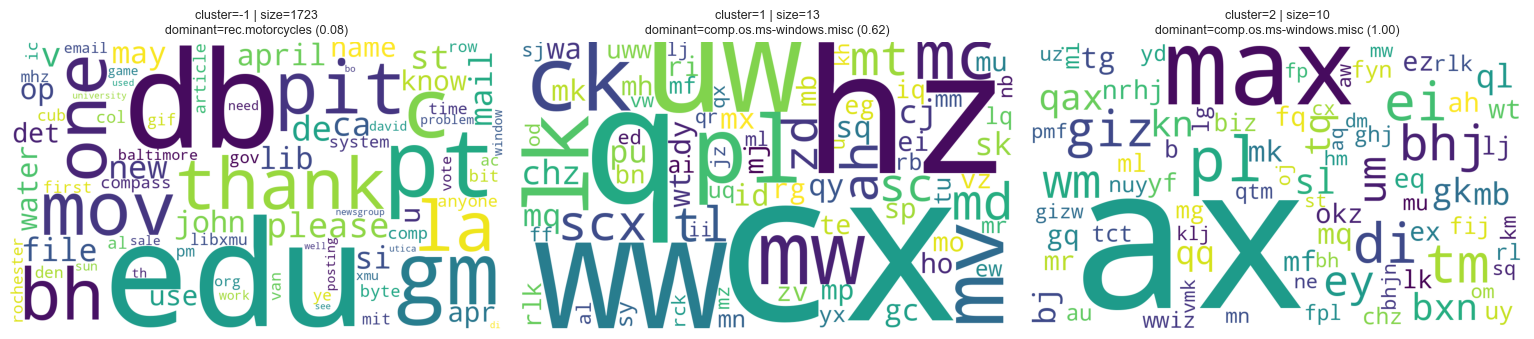

#### Para 2: [geometry] `word2vec_proxy_glove` + `hierarchical` | k=10

selection_score=0.867 | ARI=-0.000

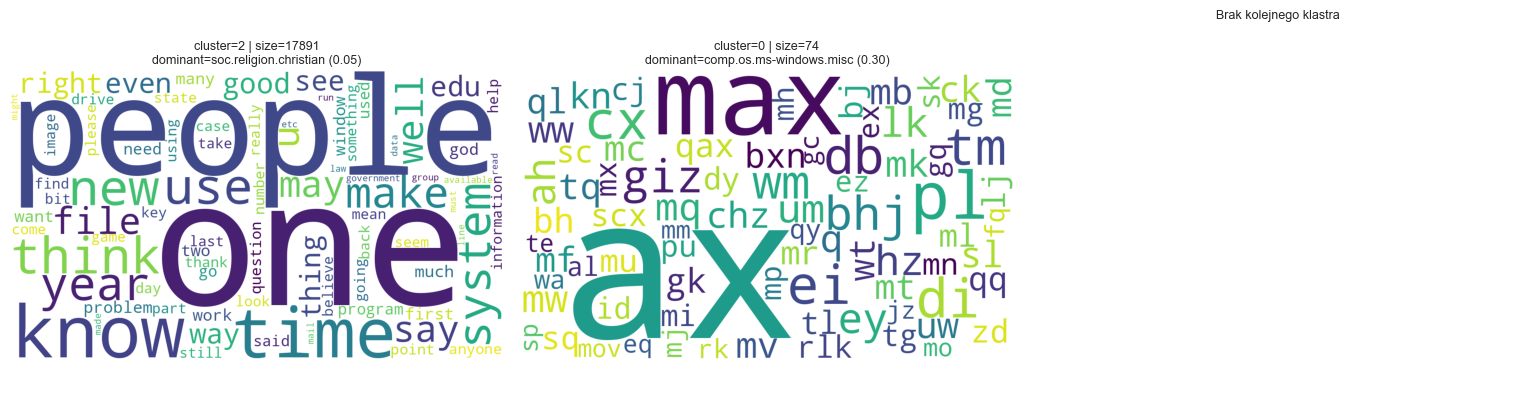

#### Para 3: [geometry] `fasttext` + `hierarchical` | k=10

selection_score=0.792 | ARI=-0.000

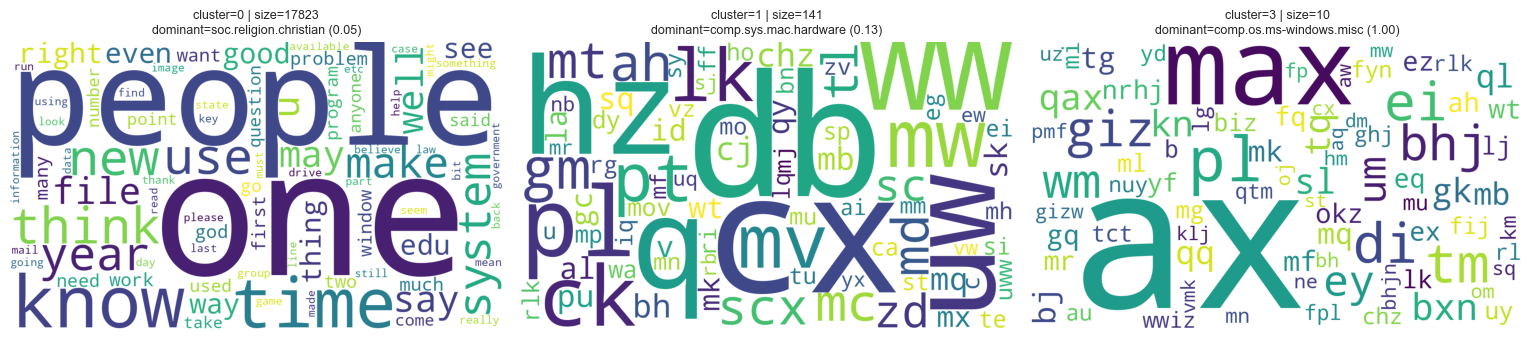

#### Para 4: [semantic] `sbert` + `hierarchical` | k=30

selection_score=0.425 | ARI=0.301 | semantic_score=0.950

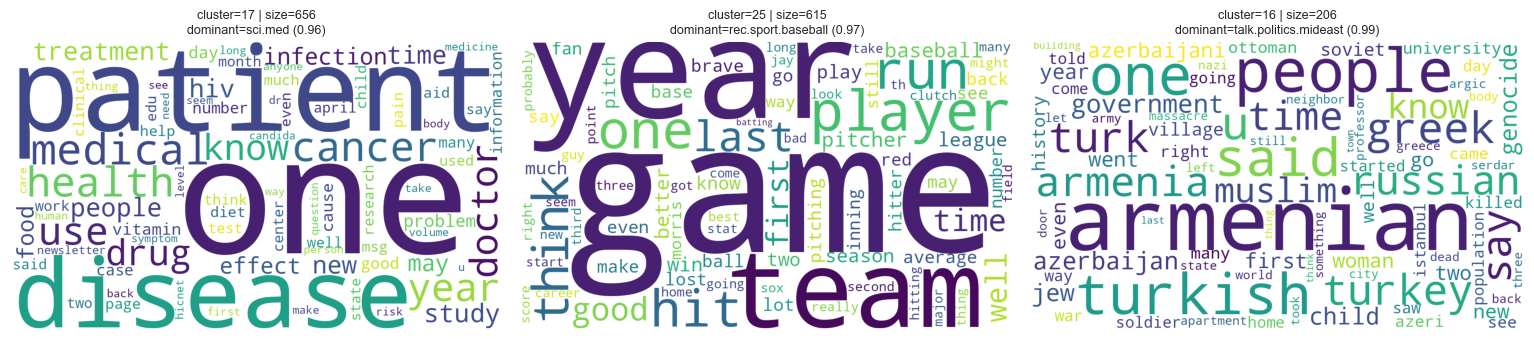

#### Para 5: [semantic] `sbert` + `kmeans` | k=20

selection_score=0.308 | ARI=0.388 | semantic_score=0.975

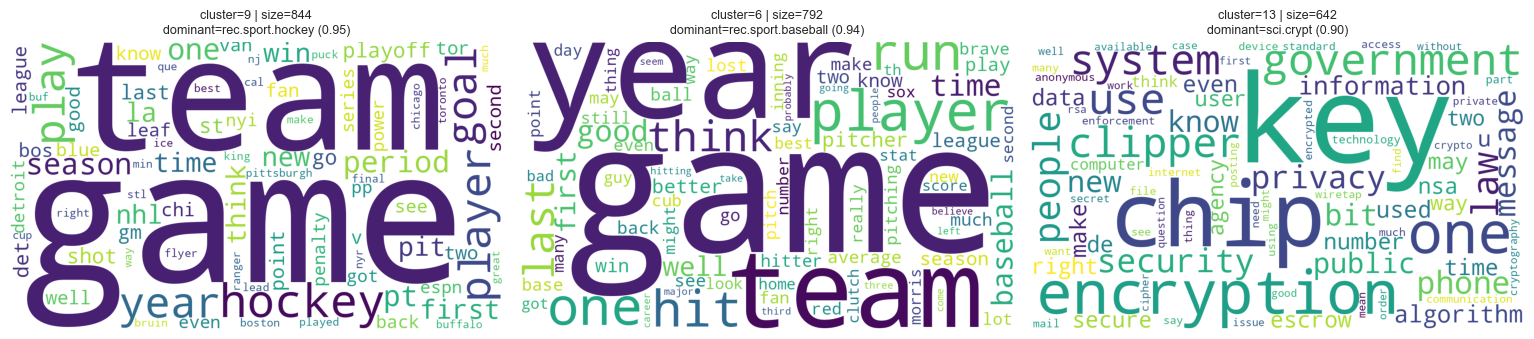

#### Para 6: [semantic] `sbert` + `spectral` | k=25

selection_score=0.183 | ARI=0.431 | semantic_score=1.000

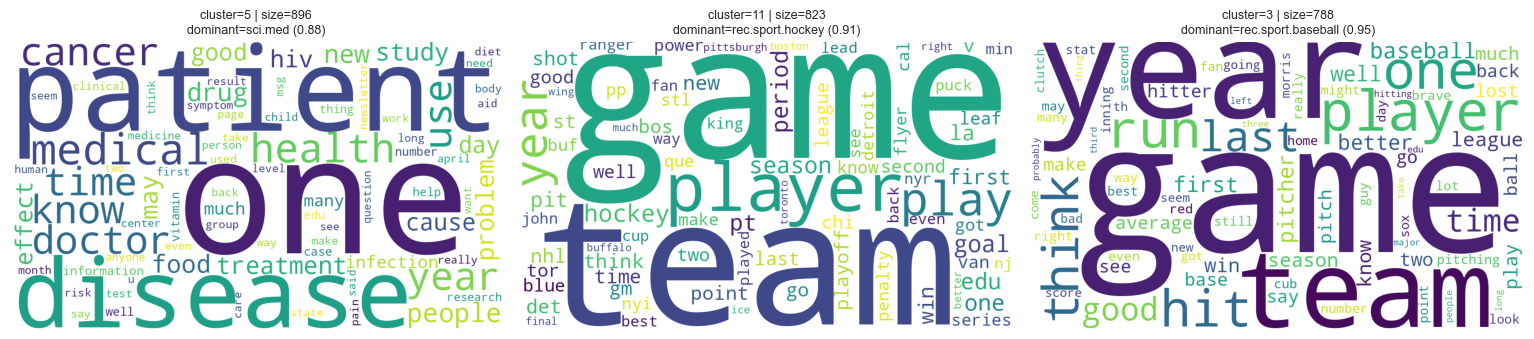


---
### Raport narracyjny: `interpretation_md`

Poniżej pełny raport tekstowy z podziałem na przebiegi, tabelą top klastrów i dokumentami przykładowymi.


## Raport interpretacyjny klastrow (best runs)

> **Kryteria wyboru:** Top 6 przebiegow wybranych do interpretacji jako suma kandydatow geometrycznych wg `selection_score_global` oraz kandydatow semantycznych wg `ARI`. Purity, entropia, WordCloud i dokumenty przykladowe sluza do kontroli tematycznej, a nie do uczenia klastrow.

### 1. word2vec_proxy_glove + dbscan (k=-1)

**Źródło wyboru:** geometry
**Selection:** selection_score_global=0.992 | ARI post-hoc=-0.000
**Etykiety post-hoc:** weighted_purity=0.061 | weighted_entropy_norm=0.995 | macro_purity=0.439
**Struktura:** largest_cluster_share=0.903 | tiny_clusters=0 | tiny_doc_share=0.000

- Najwieksze klastry: #0 size=16236 dom=soc.religion.christian(0.06); #-1 size=1723 dom=rec.motorcycles(0.08); #1 size=13 dom=comp.os.ms-windows.misc(0.62)
- Najczystsze klastry (cluster_size >= 10): #2 size=10 dom=comp.os.ms-windows.misc(1.00); #1 size=13 dom=comp.os.ms-windows.misc(0.62); #-1 size=1723 dom=rec.motorcycles(0.08)

**Top klastry wg purity post-hoc (po odfiltrowaniu malych klastrow):**

| cluster_id | size | share | dominant_target | purity | entropy_norm | flags |
|---:|---:|---:|---|---:|---:|---|
| 2 | 10 | 0.001 | comp.os.ms-windows.misc | 1.000 | 0.000 | label_pure |
| 1 | 13 | 0.001 | comp.os.ms-windows.misc | 0.615 | 0.393 | ok |
| -1 | 1723 | 0.096 | rec.motorcycles | 0.085 | 0.981 | mixed |

**Przykladowe dokumenty (centralne i graniczne):**

- Cluster 1
  - Centralne:
    - doc_id=3059 | target=comp.os.ms-windows.misc
      > ------------ Part 4 of 14 ------------ M)G(F&G*Z<G*R)G(:NB8:NAHFNAJZ<AHF<AJZ)AH:&K*R&B9R)G(F&KHF&AJZ M<AJR&B9R)AHF<G)R&AJR&AJRNK)R&AIR&KIRNG(:NB:Z&G(FNAJZ)KJZ<KHF MNB;"NAHFLEU=771T772Z772R)L)]NGT("`@("`@("`@("`@("`@("`@("`@( M"`@("`@("`@("`@("`@("`@("`@("`@...
    - doc_id=3488 | target=comp.os.ms-windows.misc
      > ---------- cut here ---------- part 03/03 M2C3,JSG A\-\($J7LUS?30XC;16@"Y DK<(ME<#T(F6;;,3QX";>?H!80H( MGNM U )D@/D&"!YW0"R"<T!2V<XLFP6#F9?P@A4&:'&B AD."/,( ,V1#&W; M'<]6P- 3$BU['L:P$]FVI@<L8'Q"W\X&-AQ(LP,9VNF5[90%! ]HF&-8MNG2 M/ ''J-A9#\1RS2FE.RXF6ML*XFG;K...
  - Graniczne:
    - doc_id=2164 | target=comp.sys.mac.hardware
      > I ran speedometer 3.21's tests (all of them) on my IIsi first with the 64k cache enabled, then with the cache disabled. I put both runs in this uuencoded machine record... the numbers favor the cache, mostly for benchmarks with a lot of memory throughput......
    - doc_id=466 | target=comp.sys.mac.hardware
      > Ok. I have a record that shows a IIsi with and without a 64KB cache. It's small enough that I will attach it. I have also measured some real programs with and without the 64 KB cache. The speedup varies a lot from app to app, ranging from 0% to 40%. I think...
- Cluster 2
  - Centralne:
    - doc_id=2694 | target=comp.os.ms-windows.misc
      > MAX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>' MAX>'AX>'AX>'AX>',3'$9F8+"Z5'1]_?W]_?WWIZ>BHJ*BHJ*BHJ*BHJ*GIZ M>GIZ>GIZ*BHJ*GIZ>M_?1T>EI0L+"V9F9F9FR,A_?W_(5Z(46Q04%%=75VO4 MU-34U-34U`("`@("`@("`M34?W]_?]#084O#%%O`.#AUG@&$`0$Y.?518)0& MC#`P8V-5...
    - doc_id=5017 | target=comp.os.ms-windows.misc
      > ------------ Part 11 of 14 ------------ MR1865%22DM75U=75U4)"0IV=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V= MG9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V= MG9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V= MG9V=0M75U=625!;)B8E,3`]G9S2+[>...
  - Graniczne:
    - doc_id=13292 | target=comp.os.ms-windows.misc
      > ------------ Part 5 of 14 ------------ M)B9R&KJZ)EVZ=+ITNKH>?7U=PGU]+"Q=?72_="PU'GT>+,<LORPU86$1EX,8 M,P$HWA=@8!SKWI_,S"B<)S<W-R>!5C<-S`HFNAIR<K)R<B9RMW)+D)#D"C!V M=KPYWA>\'.L74?4<JPW,5EQEFYJLKHBQ?K5^(7*ZLK*Z)KH:NKJZ)G0FNKI= M)K)=)KHFNGU=NK*RLB9TLKIT)L)=PK)...
    - doc_id=12650 | target=comp.os.ms-windows.misc
      > ------------ Part 6 of 14 ------------ MAZ)75U=7R!1KP"5A8=F>`7;UG)\&V0&>*YZ>*W5&$'Z]M;T0AX>'AX>'AX>' MAX=7HLAL(;7(5U\,MEIH@$H^,#",4*&?8%'U#6#,-V`W!H>'AX>'AX>'AX>' MAX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'A[0E9:0E97PM8]8M9#MH M6CNL]%&'AX>'AX>'AX>'AX>'AUL4SU=...

---

### 2. word2vec_proxy_glove + hierarchical (k=10)

**Źródło wyboru:** geometry
**Selection:** selection_score_global=0.867 | ARI post-hoc=-0.000
**Etykiety post-hoc:** weighted_purity=0.055 | weighted_entropy_norm=0.997 | macro_purity=0.568
**Struktura:** largest_cluster_share=0.995 | tiny_clusters=8 | tiny_doc_share=0.001

- Najwieksze klastry: #2 size=17891 dom=soc.religion.christian(0.05); #0 size=74 dom=comp.os.ms-windows.misc(0.30); #8 size=4 dom=talk.politics.guns(0.50)
- Najczystsze klastry (cluster_size >= 10): #0 size=74 dom=comp.os.ms-windows.misc(0.30); #2 size=17891 dom=soc.religion.christian(0.05)

**Top klastry wg purity post-hoc (po odfiltrowaniu malych klastrow):**

| cluster_id | size | share | dominant_target | purity | entropy_norm | flags |
|---:|---:|---:|---|---:|---:|---|
| 0 | 74 | 0.004 | comp.os.ms-windows.misc | 0.297 | 0.805 | mixed |
| 2 | 17891 | 0.995 | soc.religion.christian | 0.054 | 0.998 | mixed, giant |

**Przykladowe dokumenty (centralne i graniczne):**

- Cluster 0
  - Centralne:
    - doc_id=466 | target=comp.sys.mac.hardware
      > Ok. I have a record that shows a IIsi with and without a 64KB cache. It's small enough that I will attach it. I have also measured some real programs with and without the 64 KB cache. The speedup varies a lot from app to app, ranging from 0% to 40%. I think...
    - doc_id=2164 | target=comp.sys.mac.hardware
      > I ran speedometer 3.21's tests (all of them) on my IIsi first with the 64k cache enabled, then with the cache disabled. I put both runs in this uuencoded machine record... the numbers favor the cache, mostly for benchmarks with a lot of memory throughput......
  - Graniczne:
    - doc_id=6530 | target=rec.motorcycles
      > ...or centerstands, or weasel squeezers, or .... Later,
    - doc_id=7778 | target=alt.atheism
      > [By default, followups to 3 newsgroups.] A short excerpt: [...]
- Cluster 2
  - Centralne:
    - doc_id=10284 | target=sci.electronics
      > I hate to disagree, but I will. :) (note: I don't pirate software, nor do I trade it. I simply have met and talked extensively with those who have. that's it. the FBI can tap someone else's phone :) Most pirating is done by people who don't use the programs...
    - doc_id=11465 | target=comp.sys.mac.hardware
      > Interesting delema for all those out there. My school is discussing installing a Mac lab of 10 to 15 stations for our Bio 100 to 103 classes to do a study with pig disections. (no joke) Here is the deal. We can get this grant to do a study on if it is more ...
  - Graniczne:
    - doc_id=1172 | target=comp.graphics
      > In-Reply-To: <20APR199312262902@rigel.tamu.edu> lmp8913@rigel.tamu.edu (PRESTON, LISA M)
    - doc_id=3958 | target=rec.sport.hockey
      > Individual leaders by total points (Final standings) NOTE: Games played and points per games not accurate !! Player Team GP G A Pts ppg Prj PIM +/- M.Lemieux PIT 59 69 91 160 2.71 160 38 53 LaFontaine BUF 82 53 95 148 1.80 148 63 13 Oates BOS 83 45 97 142 1...

---

### 3. fasttext + hierarchical (k=10)

**Źródło wyboru:** geometry
**Selection:** selection_score_global=0.792 | ARI post-hoc=-0.000
**Etykiety post-hoc:** weighted_purity=0.056 | weighted_entropy_norm=0.997 | macro_purity=0.768
**Struktura:** largest_cluster_share=0.991 | tiny_clusters=7 | tiny_doc_share=0.000

- Najwieksze klastry: #0 size=17823 dom=soc.religion.christian(0.05); #1 size=141 dom=comp.sys.mac.hardware(0.13); #3 size=10 dom=comp.os.ms-windows.misc(1.00)
- Najczystsze klastry (cluster_size >= 10): #3 size=10 dom=comp.os.ms-windows.misc(1.00); #1 size=141 dom=comp.sys.mac.hardware(0.13); #0 size=17823 dom=soc.religion.christian(0.05)

**Top klastry wg purity post-hoc (po odfiltrowaniu malych klastrow):**

| cluster_id | size | share | dominant_target | purity | entropy_norm | flags |
|---:|---:|---:|---|---:|---:|---|
| 3 | 10 | 0.001 | comp.os.ms-windows.misc | 1.000 | 0.000 | label_pure |
| 1 | 141 | 0.008 | comp.sys.mac.hardware | 0.128 | 0.918 | mixed |
| 0 | 17823 | 0.991 | soc.religion.christian | 0.054 | 0.998 | mixed, giant |

**Przykladowe dokumenty (centralne i graniczne):**

- Cluster 1
  - Centralne:
    - doc_id=2164 | target=comp.sys.mac.hardware
      > I ran speedometer 3.21's tests (all of them) on my IIsi first with the 64k cache enabled, then with the cache disabled. I put both runs in this uuencoded machine record... the numbers favor the cache, mostly for benchmarks with a lot of memory throughput......
    - doc_id=16314 | target=rec.sport.baseball
      > Name Pos AB H 2B 3B HR RBI RS SB E AVG ------------------------------------------------------------------------------ Boston OF 12 7 2 6 .583 Galarraga 1B 28 13 3 1 9 2 .464 Tatum 3B 5 2 1 .400 Cole CF 24 9 1 2 8 2 .375 E. Young 2B 28 9 1 1 1 5 10 5 3 .321 ...
  - Graniczne:
    - doc_id=6504 | target=rec.sport.baseball
      > When is it did you say? Well let me shell out here and run this handy dandy program.... $ mlb -m pit phi And the answer is: Monday, 5/10 Pittsburg at Philadelphia (5:35 pm) Tuesday, 5/11 Pittsburg at Philadelphia (5:35 pm) Wednesday, 5/12 Pittsburg at Phila...
    - doc_id=4983 | target=rec.sport.hockey
      > In <1993Apr21.211038.12363@newshub.ists.ca> dchhabra@stpl.ists.ca
- Cluster 3
  - Centralne:
    - doc_id=9443 | target=comp.os.ms-windows.misc
      > ------------ Part 8 of 14 ------------ MAX>'AX>'AX>'AX>'AYZ>8=#0T"L!A%(!*]#0T"4E)<-N;@+(U,C(;CZ;1-/3 MTXU*IH?4JH!75\B`P2&((F[JZ$/Q[/&J3;YJ+2WE<"3T*0:4E,SUAX>'AY\* MFYL^/J"@PR4E)=#0T"4E2VY+)1$1D&[4U-34U-34AX>'AX>'AX>'AX>'AX>' MAX>'AX>'AX>'AX>'AX>'AX>'AX<Y824...
    - doc_id=2694 | target=comp.os.ms-windows.misc
      > MAX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>' MAX>'AX>'AX>'AX>',3'$9F8+"Z5'1]_?W]_?WWIZ>BHJ*BHJ*BHJ*BHJ*GIZ M>GIZ>GIZ*BHJ*GIZ>M_?1T>EI0L+"V9F9F9FR,A_?W_(5Z(46Q04%%=75VO4 MU-34U-34U`("`@("`@("`M34?W]_?]#084O#%%O`.#AUG@&$`0$Y.?518)0& MC#`P8V-5...
  - Graniczne:
    - doc_id=13292 | target=comp.os.ms-windows.misc
      > ------------ Part 5 of 14 ------------ M)B9R&KJZ)EVZ=+ITNKH>?7U=PGU]+"Q=?72_="PU'GT>+,<LORPU86$1EX,8 M,P$HWA=@8!SKWI_,S"B<)S<W-R>!5C<-S`HFNAIR<K)R<B9RMW)+D)#D"C!V M=KPYWA>\'.L74?4<JPW,5EQEFYJLKHBQ?K5^(7*ZLK*Z)KH:NKJZ)G0FNKI= M)K)=)KHFNGU=NK*RLB9TLKIT)L)=PK)...
    - doc_id=11923 | target=comp.os.ms-windows.misc
      > ------------ Part 10 of 14 ------------ M:J"U$$,^UM[>WE/M[>V+BXN+BXN+BXN+BXOM[>U34U-34["PL!D9<7'2TM+2 M/3T]/3T]F9F9`P,#7EY>NRIZWT='I0MFQ#&'AX>'AX>'AX>'AX>'AX>'AX>' MAX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>' MAX>'AX>'AX>'AX>'AX>'AX>'AX>'AX...

---

### 4. sbert + hierarchical (k=30)

**Źródło wyboru:** semantic
**Selection:** selection_score_global=0.425 | semantic_score_global=0.950 | ARI post-hoc=0.301
**Etykiety post-hoc:** weighted_purity=0.542 | weighted_entropy_norm=0.474 | macro_purity=0.581
**Struktura:** largest_cluster_share=0.081 | tiny_clusters=0 | tiny_doc_share=0.000

- Najwieksze klastry: #6 size=1458 dom=talk.politics.misc(0.22); #4 size=1214 dom=soc.religion.christian(0.57); #2 size=1002 dom=comp.graphics(0.55)
- Najczystsze klastry (cluster_size >= 10): #16 size=206 dom=talk.politics.mideast(0.99); #25 size=615 dom=rec.sport.baseball(0.97); #17 size=656 dom=sci.med(0.96)

**Top klastry wg purity post-hoc (po odfiltrowaniu malych klastrow):**

| cluster_id | size | share | dominant_target | purity | entropy_norm | flags |
|---:|---:|---:|---|---:|---:|---|
| 16 | 206 | 0.011 | talk.politics.mideast | 0.985 | 0.031 | label_pure |
| 25 | 615 | 0.034 | rec.sport.baseball | 0.972 | 0.051 | label_pure |
| 17 | 656 | 0.036 | sci.med | 0.956 | 0.092 | label_pure |

**Przykladowe dokumenty (centralne i graniczne):**

- Cluster 16
  - Centralne:
    - doc_id=11949 | target=talk.politics.mideast
      > : Pardon me? Here is to an amherst-clown: : : "Your three chiefs, Dro, Hamazasp and Kulkhandanian are the ringleaders : of the bands which have destroyed Tartar villages and have staged : massacres in Zangezour, Surmali, Etchmiadzin, and Zangibasar. This is...
    - doc_id=14417 | target=talk.politics.mideast
      > It is 'Serdar', 'kocaoglan'. Just say so. The SUNDAY TIMES 8 March 1992 Morgues fill as Azeris head for all-out war ------------------------------------------- Thomas Goltz, the first to report the massacre by Armenian soldiers in the worst violence since t...
  - Graniczne:
    - doc_id=18091 | target=talk.politics.mideast
      > on choice Nonononnononono....its "From the Nile to the Nile.....the Long way!" ;-)
    - doc_id=17492 | target=talk.politics.mideast
      > Henrik (?), Your ignorance manifests itself in an awkward form of intransigence. I'm not going to spend time to review with you the recent history of Cyprus. If you are really interested, I can provide you with a number of references on the issue. Just send...
- Cluster 25
  - Centralne:
    - doc_id=5562 | target=rec.sport.baseball
      > Philadelphia at Chicago: Teams tied for 1st after Sunday Dick Redding battled Chet Brewer in the first game of a dramatic four game series. One Friday, one Saturday, and a good-old Sunday doubleheader. "What could be better," declared Ernie Banks. Perhaps t...
    - doc_id=4634 | target=rec.sport.baseball
      > Having run completely out of time, I've got to get my prophesies and predictions for the A.L. out. Qualifications -- one of the worse finishes in last year's prediction contest. AL East -- 1993 1. Baltimore Orioles Why the Orioles? Well, I pondered long and...
  - Graniczne:
    - doc_id=7644 | target=rec.sport.baseball
      > I thought that Walt Weiss was jewish. I seem to recall this was mentioned once while he was still at Oakland. Also, I have my suspicions about Esther Canseco (nee Haddad).
    - doc_id=11778 | target=rec.sport.baseball
      > Lowenstein is NOT Jewish. However, there is a long list including Hank Greenberg, Moe Berg, Rod Carew (a convert), the Sherry brothers, Art Shamsky, and Ron Blomberg.

---

### 5. sbert + kmeans (k=20)

**Źródło wyboru:** semantic
**Selection:** selection_score_global=0.308 | semantic_score_global=0.975 | ARI post-hoc=0.388
**Etykiety post-hoc:** weighted_purity=0.586 | weighted_entropy_norm=0.453 | macro_purity=0.625
**Struktura:** largest_cluster_share=0.073 | tiny_clusters=0 | tiny_doc_share=0.000

- Najwieksze klastry: #16 size=1321 dom=comp.sys.ibm.pc.hardware(0.35); #7 size=1226 dom=alt.atheism(0.11); #19 size=1061 dom=sci.electronics(0.44)
- Najczystsze klastry (cluster_size >= 10): #9 size=844 dom=rec.sport.hockey(0.95); #6 size=792 dom=rec.sport.baseball(0.94); #13 size=642 dom=sci.crypt(0.90)

**Top klastry wg purity post-hoc (po odfiltrowaniu malych klastrow):**

| cluster_id | size | share | dominant_target | purity | entropy_norm | flags |
|---:|---:|---:|---|---:|---:|---|
| 9 | 844 | 0.047 | rec.sport.hockey | 0.947 | 0.075 | label_pure |
| 6 | 792 | 0.044 | rec.sport.baseball | 0.943 | 0.089 | label_pure |
| 13 | 642 | 0.036 | sci.crypt | 0.903 | 0.176 | label_pure |

**Przykladowe dokumenty (centralne i graniczne):**

- Cluster 6
  - Centralne:
    - doc_id=5562 | target=rec.sport.baseball
      > Philadelphia at Chicago: Teams tied for 1st after Sunday Dick Redding battled Chet Brewer in the first game of a dramatic four game series. One Friday, one Saturday, and a good-old Sunday doubleheader. "What could be better," declared Ernie Banks. Perhaps t...
    - doc_id=9849 | target=rec.sport.baseball
      > Oops! I came across this file from last year. Thought you might enjoy some of these thoughts. The predictions were made on the date indicated. They are largely out of order. ------------------------------------------------------------------------------ June...
  - Graniczne:
    - doc_id=10594 | target=rec.sport.hockey
      > The Hart Trophy was orginally awarded in a time where people did not think in terms of who was the "best" player, rather in terms of who was the most valuable to the team. And "valuable to his team" was not, and should not be, considered synonymous with "be...
    - doc_id=10446 | target=rec.sport.hockey
      > Not bad, you only got 2 wrong,... Cal over Chi in 5 and Cal over Pit in 6 (or 7) to take the SC
- Cluster 9
  - Centralne:
    - doc_id=16217 | target=rec.sport.hockey
      > Archive-name: hockey-faq rec.sport.hockey answers to Frequently Asked Questions and other news: Contents: 0. New Info. 1. NHL 2. NHL Minor Leagues 3. College Hockey (North America) 4. Other leagues (e.g. Europe, Canada Cup tournament) 5. E-mail files 6. USE...
    - doc_id=9218 | target=rec.sport.hockey
      > NHL RESULTS FOR GAMES PLAYED 4/14/93. -------------------------------------------------------------------------------- STANDINGS PATRICK ADAMS NORRIS SMYTHE TM W L T PT TM W L T PT TM W L T PT TM W L T PT xPIT 56 21 7 119 xBOS 51 26 7 109 xCHI 46 25 12 104 ...
  - Graniczne:
    - doc_id=12909 | target=rec.sport.hockey
      > Borchevsky is 5'9" and Gilmour is 5'11"...I think Gilmour slightly outweighs Borchevsky. Andreychuk is also about 5'11", I think.
    - doc_id=1103 | target=rec.sport.baseball
      > I wonder why you say that? I don't see why having a spouse and/or kids would have anything to do with it. It might if you brought your kids to the game and wanted them to get home in time to get to bed at a reasonable hour (in which case I'd probably decide...

---

### 6. sbert + spectral (k=25)

**Źródło wyboru:** semantic
**Selection:** selection_score_global=0.183 | semantic_score_global=1.000 | ARI post-hoc=0.431
**Etykiety post-hoc:** weighted_purity=0.599 | weighted_entropy_norm=0.426 | macro_purity=0.611
**Struktura:** largest_cluster_share=0.131 | tiny_clusters=0 | tiny_doc_share=0.000

- Najwieksze klastry: #9 size=2355 dom=comp.sys.ibm.pc.hardware(0.34); #1 size=1673 dom=talk.politics.guns(0.45); #0 size=1638 dom=rec.autos(0.47)
- Najczystsze klastry (cluster_size >= 10): #3 size=788 dom=rec.sport.baseball(0.95); #11 size=823 dom=rec.sport.hockey(0.91); #5 size=896 dom=sci.med(0.88)

**Top klastry wg purity post-hoc (po odfiltrowaniu malych klastrow):**

| cluster_id | size | share | dominant_target | purity | entropy_norm | flags |
|---:|---:|---:|---|---:|---:|---|
| 3 | 788 | 0.044 | rec.sport.baseball | 0.948 | 0.104 | label_pure |
| 11 | 823 | 0.046 | rec.sport.hockey | 0.913 | 0.153 | label_pure |
| 5 | 896 | 0.050 | sci.med | 0.877 | 0.222 | label_pure |

**Przykladowe dokumenty (centralne i graniczne):**

- Cluster 3
  - Centralne:
    - doc_id=5562 | target=rec.sport.baseball
      > Philadelphia at Chicago: Teams tied for 1st after Sunday Dick Redding battled Chet Brewer in the first game of a dramatic four game series. One Friday, one Saturday, and a good-old Sunday doubleheader. "What could be better," declared Ernie Banks. Perhaps t...
    - doc_id=9849 | target=rec.sport.baseball
      > Oops! I came across this file from last year. Thought you might enjoy some of these thoughts. The predictions were made on the date indicated. They are largely out of order. ------------------------------------------------------------------------------ June...
  - Graniczne:
    - doc_id=12918 | target=sci.crypt
      > While I didn't try the expansion personally, I know of at least two other people who did and got the same results. Your allegation is incorrect at best.
    - doc_id=14457 | target=rec.sport.baseball
      > Rust Staub is NOT Jewish. In fact, I think his father was a minister.
- Cluster 11
  - Centralne:
    - doc_id=16217 | target=rec.sport.hockey
      > Archive-name: hockey-faq rec.sport.hockey answers to Frequently Asked Questions and other news: Contents: 0. New Info. 1. NHL 2. NHL Minor Leagues 3. College Hockey (North America) 4. Other leagues (e.g. Europe, Canada Cup tournament) 5. E-mail files 6. USE...
    - doc_id=9218 | target=rec.sport.hockey
      > NHL RESULTS FOR GAMES PLAYED 4/14/93. -------------------------------------------------------------------------------- STANDINGS PATRICK ADAMS NORRIS SMYTHE TM W L T PT TM W L T PT TM W L T PT TM W L T PT xPIT 56 21 7 119 xBOS 51 26 7 109 xCHI 46 25 12 104 ...
  - Graniczne:
    - doc_id=14808 | target=rec.autos
      > I was wondering what the country extension are. Sometimes I just don't have a clue from where some people are writing. These are the extensions I know of ch Switzerland se Sweden fi Finland uk UK Com US? Edu US? (are both com and edu US?) fr France Please f...
    - doc_id=13107 | target=sci.space
      > In my last post I referred to Michael Adams as "Nick." Completely my error; Nick Adams was a film and TV actor from the '50's and early '60's (remember Johnny Yuma, The Rebel?). He was from my part of the country, and Michael's email address of "nmsca[...]"...

---


In [18]:
from IPython.display import Image, Markdown, display

if "filter_runs_with_available_embeddings" not in globals():
    def filter_runs_with_available_embeddings(runs_df, embedding_views, context):
        if runs_df.empty or "embedding_name" not in runs_df.columns:
            return runs_df.copy()
        available_embeddings = set(embedding_views.keys())
        missing = sorted(set(runs_df["embedding_name"].dropna().astype(str)) - available_embeddings)
        if missing:
            print(
                f"Pominieto {context} dla reprezentacji nieobecnych w embedding_views: "
                f"{', '.join(missing)}. "
                "Uruchom ponownie sekcje budowania reprezentacji, jesli te przebiegi maja byc interpretowane."
            )
        return (
            runs_df[runs_df["embedding_name"].astype(str).isin(available_embeddings)]
            .copy()
            .reset_index(drop=True)
        )

interpretation_candidates_df = build_interpretation_candidates(
    best_runs_df=best_runs_df,
    semantic_best_runs_df=semantic_best_runs_df,
    top_per_source=int(CONFIG.get("wordcloud_top_runs", 3)),
)
interpretation_candidates_df = filter_runs_with_available_embeddings(
    interpretation_candidates_df,
    embedding_views=embedding_views,
    context="kandydatow do interpretacji i WordCloud",
)
top_interpretation_runs = max(int(len(interpretation_candidates_df)), 1)

cluster_profiles_df, cluster_examples, interpretation_runs_df = explain_best_runs(
    best_runs_df=interpretation_candidates_df,
    dataset_df=dataset_df,
    dataset_views=dataset_views,
    embedding_views=embedding_views,
    config=CONFIG,
)

wordcloud_index_df = generate_wordcloud_artifacts(
    run_summary_df=interpretation_runs_df,
    cluster_profiles_df=cluster_profiles_df,
    dataset_df=dataset_df,
    dataset_views=dataset_views,
    embedding_views=embedding_views,
    best_runs_df=interpretation_candidates_df,
    config=CONFIG,
    top_runs=top_interpretation_runs,
)

interpretation_md = format_interpretation_markdown(
    run_summary_df=interpretation_runs_df,
    cluster_profiles_df=cluster_profiles_df,
    cluster_examples=cluster_examples,
    top_runs=top_interpretation_runs,
    min_cluster_size=int(CONFIG.get("wordcloud_min_cluster_size", 10)),
)

if interpretation_runs_df.empty:
    interpretation_runs_view = interpretation_runs_df
else:
    interpretation_runs_view = (
        interpretation_runs_df
        .sort_values(["interpretation_source_rank", "selection_score_global", "semantic_score_global", "weighted_normalized_entropy", "weighted_purity"], ascending=[True, False, False, True, False])
        .reset_index(drop=True)
    )

if cluster_profiles_df.empty:
    cluster_profiles_view = cluster_profiles_df
else:
    cluster_profiles_view = (
        cluster_profiles_df
        .sort_values(["cluster_size", "dominant_target_share"], ascending=[False, False])
        .head(20)
        .reset_index(drop=True)
    )

examples_view = build_examples_dataframe(
    run_summary_df=interpretation_runs_df,
    cluster_profiles_df=cluster_profiles_df,
    cluster_examples=cluster_examples,
    top_runs=top_interpretation_runs,
    clusters_per_run=int(CONFIG.get("wordcloud_clusters_per_run", 3)),
    docs_per_role=2,
    min_cluster_size=int(CONFIG.get("wordcloud_min_cluster_size", 10)),
)

display(Markdown("""
---
### Tabela 8A: `interpretation_candidates_df` — kandydaci do interpretacji

Lista laczy najlepszych kandydatow geometrycznych wg `selection_score_global` oraz najlepszych kandydatow semantycznych wg `ARI`. Kolumna `interpretation_source` pokazuje, z ktorego kryterium kandydat trafil do czesci interpretacyjnej.
"""))
with pd.option_context("display.max_colwidth", 140):
    display(interpretation_candidates_df)

display(Markdown("""
---
### Tabela 8B: `interpretation_runs_df` — diagnostyka przebiegów do interpretacji

Jeden wiersz = jeden przebieg (embedding + algorytm). Ranking obejmuje kandydatów geometrycznych i semantycznych, a metryki etykietowe są diagnostyką post-hoc.

Kluczowe pola:
- `interpretation_source`: informacja, czy kandydat pochodzi z rankingu geometrycznego, semantycznego, czy z obu,
- `selection_score_global`: nienadzorowane kryterium wyboru z sekcji 7,
- `semantic_score_global` i `ARI`: zgodność z etykietami referencyjnymi w osobnym rankingu semantycznym,
- `weighted_purity` i `weighted_normalized_entropy`: globalna zgodność z etykietami, ważona rozmiarem klastrów,
- `macro_purity` i `macro_normalized_entropy`: diagnostyka fragmentacji,
- `tiny_cluster_count`, `tiny_cluster_doc_share`, `largest_cluster_share`: diagnostyka struktury podziału.
"""))
with pd.option_context("display.max_colwidth", 140):
    display(interpretation_runs_view)

display(Markdown("""
---
### Tabela 8C: `cluster_profiles_df` — profile klastrów (top 20)

Największe klastry z adnotacjami semantycznymi, etykietowymi i strukturalnymi. Purity dla małych klastrów traktujemy ostrożnie.
"""))
with pd.option_context("display.max_colwidth", 120):
    display(cluster_profiles_view)

display(Markdown("""
---
### Tabela 8D: dokumenty przykładowe (centralne vs graniczne)

Lepszy widok dokumentów do analizy jakości klastrów:
- `central`: dokumenty najbardziej typowe dla klastra,
- `boundary`: dokumenty najbardziej graniczne.

Dane obejmują top przebiegi i top klastry po odfiltrowaniu bardzo małych klastrów.
"""))
with pd.option_context("display.max_colwidth", 180):
    display(examples_view)

if not wordcloud_index_df.empty:
    display(Markdown("""
---
### Tabela 8E: `wordcloud_index_df`

Indeks wygenerowanych WordCloud dla porównania kandydatów geometrycznych i semantycznych. Chmury są wyświetlane blokami: każdy blok odpowiada jednej parze reprezentacja + algorytm, a w środku pokazujemy po 3 chmury dla różnych klastrów tego samego przebiegu. Chmury słów są elementem interpretacji leksykalnej, nie metryką jakości.
"""))
    display(wordcloud_index_df)
    display_wordclouds(wordcloud_index_df)

display(Markdown("""
---
### Raport narracyjny: `interpretation_md`

Poniżej pełny raport tekstowy z podziałem na przebiegi, tabelą top klastrów i dokumentami przykładowymi.
"""))
display(Markdown(interpretation_md))


## 9. Artefakty, wykresy i MLflow

Wyniki eksperymentow sa zapisywane jako tabele `CSV`, pliki `JSON`, wykresy, WordCloud oraz lokalne przebiegi `MLflow`. Dzieki temu notebook pelni jednoczesnie role raportu i dokumentacji wykonanych eksperymentow.


In [19]:
def save_project_artifacts(
    results_df: pd.DataFrame,
    best_runs_df: pd.DataFrame,
    cluster_profiles_df: pd.DataFrame,
    cluster_examples: List[Dict[str, Any]],
    config: Dict[str, Any],
    wordcloud_index_df: Optional[pd.DataFrame] = None,
) -> Dict[str, str]:
    artifact_dir = Path(config["artifact_dir"])
    tables_dir = artifact_dir / "tables"
    tables_dir.mkdir(parents=True, exist_ok=True)

    results_path = tables_dir / "results_summary.csv"
    best_path = tables_dir / "best_runs.json"
    profiles_path = tables_dir / "cluster_profiles.csv"
    examples_path = tables_dir / "cluster_examples.json"
    wordcloud_index_path = tables_dir / "wordcloud_index.csv"

    results_df.to_csv(results_path, index=False)
    cluster_profiles_df.to_csv(profiles_path, index=False)
    best_path.write_text(
        json.dumps(best_runs_df.to_dict(orient="records"), ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    examples_path.write_text(
        json.dumps(cluster_examples, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    artifact_paths = {
        "results_summary": str(results_path),
        "best_runs": str(best_path),
        "cluster_profiles": str(profiles_path),
        "cluster_examples": str(examples_path),
    }

    if wordcloud_index_df is not None and not wordcloud_index_df.empty:
        wordcloud_index_df.to_csv(wordcloud_index_path, index=False)
        artifact_paths["wordcloud_index"] = str(wordcloud_index_path)
        for idx, row in enumerate(wordcloud_index_df.itertuples(index=False), start=1):
            artifact_paths[f"wordcloud_{idx:02d}"] = str(row.wordcloud_path)

    return artifact_paths


def format_parameter_label(row: pd.Series) -> str:
    algorithm = str(row.get("algorithm", ""))
    if algorithm == "dbscan":
        eps = row.get("eps", np.nan)
        min_samples = row.get("min_samples", np.nan)
        eps_label = "?" if pd.isna(eps) else f"{float(eps):g}"
        min_samples_label = "?" if pd.isna(min_samples) else str(int(min_samples))
        metric_label = row.get("metric", "")
        metric_part = f", {metric_label}" if isinstance(metric_label, str) and metric_label else ""
        return f"eps={eps_label}, ms={min_samples_label}{metric_part}"

    k = row.get("k", np.nan)
    if pd.isna(k) or int(k) < 0:
        return "k=na"

    label_parts = [f"k={int(k)}"]
    if algorithm == "spectral" and "n_neighbors" in row.index and not pd.isna(row.get("n_neighbors")):
        label_parts.append(f"nn={int(row['n_neighbors'])}")
    return ", ".join(label_parts)


def format_compact_run_label(row: pd.Series) -> str:
    embedding_label = format_embedding_plot_label(row["embedding_name"], width=24)
    algorithm_label = format_algorithm_plot_label(row["algorithm"])
    return f"{embedding_label} + {algorithm_label}\n{format_parameter_label(row)}"


def generate_summary_plots(
    results_df: pd.DataFrame,
    best_runs_df: pd.DataFrame,
    artifact_dir: Path,
) -> Dict[str, str]:
    plots_dir = artifact_dir / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)

    silhouette_path = plots_dir / "best_silhouette_by_model.png"
    ari_path = plots_dir / "best_ari_by_model.png"
    davies_bouldin_path = plots_dir / "best_davies_bouldin_by_model.png"
    dunn_path = plots_dir / "best_dunn_by_model.png"
    selection_path = plots_dir / "best_selection_score_global_by_model.png"
    tradeoff_path = plots_dir / "section10_silhouette_ari_tradeoff.png"
    efficiency_path = plots_dir / "section10_selection_runtime_efficiency.png"
    k_sensitivity_path = plots_dir / "section10_k_sensitivity.png"
    metric_profile_path = plots_dir / "section10_metric_profile_heatmap.png"

    # Wnioski z poprzednich przebiegow zostawily w raporcie tylko statyczne PNG;
    # interaktywne HTML nie dodawaly nowych informacji, wiec wykresy budujemy w seaborn.
    make_metric_barplot(best_runs_df, "silhouette", "Best silhouette by embedding and algorithm", silhouette_path)
    make_metric_barplot(best_runs_df, "ari", "Post-hoc ARI by embedding and algorithm", ari_path)
    make_metric_barplot(best_runs_df, "davies_bouldin", "Best Davies-Bouldin by embedding and algorithm (lower is better)", davies_bouldin_path)
    make_metric_barplot(best_runs_df, "dunn", "Best Dunn index by embedding and algorithm", dunn_path)
    make_metric_barplot(best_runs_df, "selection_score_global", "Global selection_score among local winners", selection_path)
    make_metric_tradeoff_plot(best_runs_df, tradeoff_path)
    make_runtime_efficiency_plot(best_runs_df, efficiency_path)
    make_k_sensitivity_plot(results_df, k_sensitivity_path)
    make_metric_profile_heatmap(best_runs_df, metric_profile_path)

    return {
        "best_silhouette_plot": str(silhouette_path),
        "best_ari_plot": str(ari_path),
        "best_davies_bouldin_plot": str(davies_bouldin_path),
        "best_dunn_plot": str(dunn_path),
        "best_selection_score_global_plot": str(selection_path),
        "section10_tradeoff_plot": str(tradeoff_path),
        "section10_efficiency_plot": str(efficiency_path),
        "section10_k_sensitivity_plot": str(k_sensitivity_path),
        "section10_metric_profile_plot": str(metric_profile_path),
    }


def make_metric_barplot(best_runs_df: pd.DataFrame, metric: str, title: str, output_path: Path) -> None:
    plot_df = best_runs_df.copy()
    if plot_df.empty or metric not in plot_df.columns:
        return
    plot_df["label"] = plot_df.apply(format_compact_run_label, axis=1)
    higher_is_better = metric != "davies_bouldin"
    max_rows = 25
    if len(plot_df) > max_rows:
        plot_df = plot_df.nlargest(max_rows, metric) if higher_is_better else plot_df.nsmallest(max_rows, metric)
        title = f"{title} (top {max_rows})"
    plot_df = plot_df.sort_values(metric, ascending=higher_is_better)

    fig_height = max(5.0, 0.42 * len(plot_df) + 1.8)
    fig, ax = plt.subplots(figsize=(11, fig_height))
    sns.barplot(data=plot_df, x=metric, y="label", ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("embedding + algorithm")
    ax.tick_params(axis="y", labelsize=8)
    ax.margins(x=0.12)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def make_metric_tradeoff_plot(best_runs_df: pd.DataFrame, output_path: Path) -> None:
    plot_df = best_runs_df.copy()
    if plot_df.empty:
        return

    plot_df["annotation_label"] = plot_df.apply(format_compact_run_label, axis=1)
    fig, (ax, table_ax) = plt.subplots(1, 2, figsize=(16.6, 7.3), gridspec_kw={"width_ratios": [1.25, 1.08]})
    algorithms, palette, markers = algorithm_plot_style(plot_df)
    sns.scatterplot(
        data=plot_df,
        x="silhouette",
        y="ari",
        hue="algorithm",
        style="algorithm",
        size="selection_score_global",
        sizes=(140, 520),
        alpha=0.82,
        edgecolor="#1f2933",
        linewidth=0.8,
        palette=palette,
        markers=markers,
        legend=False,
        ax=ax,
    )
    ax.axhline(0, color="#8a8f98", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.set_title("Trade-off: separacja geometryczna vs ARI post-hoc")
    ax.set_xlabel("silhouette (wyzej = lepiej)")
    ax.set_ylabel("ARI wzgledem kategorii 20 Newsgroups (post-hoc)")
    add_algorithm_legend(fig, algorithms, palette, markers, y_anchor=0.025)
    add_top_runs_table(
        ax=table_ax,
        plot_df=plot_df,
        columns=[("selection_score_global", "score", ".2f"), ("silhouette", "sil", ".2f"), ("ari", "ARI", ".2f")],
        max_rows=8,
        title="Top wg selection_score_global",
    )
    fig.tight_layout(rect=(0, 0.16, 1, 1))
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def make_runtime_efficiency_plot(best_runs_df: pd.DataFrame, output_path: Path) -> None:
    plot_df = best_runs_df.copy()
    if plot_df.empty or "selection_score_global" not in plot_df.columns:
        return
    plot_df["annotation_label"] = plot_df.apply(format_compact_run_label, axis=1)

    fig, (ax, table_ax) = plt.subplots(1, 2, figsize=(16.3, 7.1), gridspec_kw={"width_ratios": [1.25, 1.08]})
    algorithms, palette, markers = algorithm_plot_style(plot_df)
    sns.scatterplot(
        data=plot_df,
        x="runtime_sec",
        y="selection_score_global",
        hue="algorithm",
        style="algorithm",
        size="selection_score_global",
        sizes=(80, 260),
        alpha=0.82,
        edgecolor="#1f2933",
        linewidth=0.6,
        palette=palette,
        markers=markers,
        legend=False,
        ax=ax,
    )
    if plot_df["runtime_sec"].min() > 0:
        ax.set_xscale("log")
    ax.set_title("Diagnostyka: selection_score_global wzgledem czasu wykonania")
    ax.set_xlabel("runtime_sec (skala log, nizej = szybciej)")
    ax.set_ylabel("selection_score_global (wyzej = lepiej)")
    add_algorithm_legend(fig, algorithms, palette, markers, y_anchor=0.025)
    add_top_runs_table(
        ax=table_ax,
        plot_df=plot_df,
        columns=[("selection_score_global", "score", ".2f"), ("runtime_sec", "sec", ".1f"), ("silhouette", "sil", ".2f")],
        max_rows=8,
        title="Top wg selection_score_global",
    )
    fig.tight_layout(rect=(0, 0.16, 1, 1))
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def make_k_sensitivity_plot(results_df: pd.DataFrame, output_path: Path) -> None:
    metric_specs = [
        ("silhouette", "max", "Silhouette (wyzej = lepiej)"),
        ("ari", "max", "ARI post-hoc (wyzej = wieksza zgodnosc z etykietami)"),
        ("dunn", "max", "Dunn (wyzej = lepiej)"),
        ("davies_bouldin", "min", "Davies-Bouldin (nizej = lepiej)"),
    ]
    required = {"embedding_name", "algorithm", "k"} | {metric for metric, _, _ in metric_specs}
    if results_df.empty or not required.issubset(results_df.columns):
        return

    metric_columns = [metric for metric, _, _ in metric_specs]
    plot_df = results_df.dropna(subset=["k", *metric_columns]).copy()
    plot_df = plot_df[plot_df["k"] >= 0]
    if plot_df.empty:
        return
    plot_df["run_family"] = plot_df["embedding_name"] + " + " + plot_df["algorithm"]
    max_families = 12
    family_scores = plot_df.groupby("run_family")["silhouette"].max().sort_values(ascending=False)
    selected_families = family_scores.head(max_families).index
    plot_df = plot_df[plot_df["run_family"].isin(selected_families)].copy()
    if plot_df.empty:
        return
    agg_spec = {metric: (metric, agg_func) for metric, agg_func, _ in metric_specs}
    summary = plot_df.groupby(["run_family", "k"], as_index=False).agg(**agg_spec).sort_values("k")
    summary["run_family_label"] = summary["run_family"].map(lambda value: wrap_plot_text(value, width=28, max_lines=2, max_chars=54))
    title_suffix = f" (top {len(selected_families)} serii wg silhouette)" if len(family_scores) > max_families else ""

    fig, axes = plt.subplots(2, 2, figsize=(18.5, 10.8), sharex=True)
    axes_flat = axes.ravel()
    family_labels = list(summary["run_family_label"].drop_duplicates())
    palette = dict(zip(family_labels, sns.color_palette("tab20", n_colors=len(family_labels))))
    for ax, (metric, _, title) in zip(axes_flat, metric_specs):
        sns.lineplot(
            data=summary,
            x="k",
            y=metric,
            hue="run_family_label",
            palette=palette,
            marker="o",
            linewidth=1.6,
            ax=ax,
            legend=False,
        )
        ax.set_title(f"Wrazliwosc {title} na liczbe klastrow{title_suffix}", fontsize=10)
        ax.set_ylabel(metric)
        ax.axvline(20, color="#8a8f98", linewidth=0.9, linestyle="--", alpha=0.7)
        ax.set_xlabel("k")
    handles = [plt.Line2D([0], [0], color=palette[label], marker="o", linewidth=1.6, label=label) for label in family_labels]
    if handles:
        fig.legend(
            handles=handles,
            loc="center left",
            bbox_to_anchor=(0.77, 0.5),
            ncol=1,
            fontsize=7,
            frameon=False,
        )
    fig.tight_layout(rect=(0, 0, 0.74, 1))
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def normalize_metric(series: pd.Series, higher_is_better: bool = True) -> pd.Series:
    values = series.astype(float)
    min_value = values.min()
    max_value = values.max()
    if pd.isna(min_value) or pd.isna(max_value) or np.isclose(max_value, min_value):
        return pd.Series(0.5, index=series.index)
    normalized = (values - min_value) / (max_value - min_value)
    return normalized if higher_is_better else 1 - normalized


def make_metric_profile_heatmap(best_runs_df: pd.DataFrame, output_path: Path) -> None:
    metric_specs = [
        ("selection_score_global", True, "selection_score_global"),
        ("silhouette", True, "silhouette"),
        ("dunn", True, "Dunn"),
        ("davies_bouldin", False, "Davies-Bouldin inv."),
        ("ari", True, "ARI post-hoc"),
        ("runtime_sec", False, "runtime inv."),
    ]
    required = {metric for metric, _, _ in metric_specs}
    if best_runs_df.empty or not required.issubset(best_runs_df.columns):
        return

    plot_df = best_runs_df.copy().reset_index(drop=True)
    max_rows = 30
    if "selection_score_global" in plot_df.columns and len(plot_df) > max_rows:
        plot_df = plot_df.sort_values("selection_score_global", ascending=False).head(max_rows).reset_index(drop=True)
    labels = plot_df.apply(format_compact_run_label, axis=1)
    heatmap_values = pd.DataFrame(
        {
            label: normalize_metric(plot_df[metric], higher_is_better=higher_is_better)
            for metric, higher_is_better, label in metric_specs
        }
    )
    heatmap_values.index = labels

    fig_height = max(4.8, 0.5 * len(plot_df) + 1.8)
    fig, ax = plt.subplots(figsize=(11.2, fig_height))
    sns.heatmap(
        heatmap_values,
        ax=ax,
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
        annot=True,
        fmt=".2f",
        linewidths=0.35,
        linecolor="#ffffff",
        cbar_kws={"label": "znormalizowana jakosc"},
    )
    ax.set_title("Profil metryk dla best-runs (0 = slabszy, 1 = lepszy w danej metryce)")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=20, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def log_summary_run(
    results_df: pd.DataFrame,
    best_runs_df: pd.DataFrame,
    cluster_profiles_df: pd.DataFrame,
    artifact_paths: Dict[str, str],
    config: Dict[str, Any],
) -> None:
    with mlflow.start_run(run_name=f"{config['mode']}_summary", nested=False):
        mlflow.set_tags({"mode": config["mode"], "kind": "summary"})
        mlflow.log_dict(config, "config.json")
        mlflow.log_metrics(
            {
                "n_total_runs": float(len(results_df)),
                "n_best_runs": float(len(best_runs_df)),
                "n_profile_rows": float(len(cluster_profiles_df)),
                "best_selection_score_global_max": float(best_runs_df["selection_score_global"].max()),
                "best_silhouette_max": float(best_runs_df["silhouette"].max()),
                "best_ari_posthoc_max": float(best_runs_df["ari"].max()),
            }
        )
        for path in artifact_paths.values():
            mlflow.log_artifact(path)


def format_run_label(row: pd.Series) -> str:
    return f"{row['embedding_name']} + {row['algorithm']} (k={int(row['k'])})"


def build_section10_views(
    best_runs_df: pd.DataFrame,
    interpretation_runs_df: pd.DataFrame,
    cluster_profiles_df: pd.DataFrame,
) -> Dict[str, pd.DataFrame]:
    empty = pd.DataFrame()
    if best_runs_df.empty:
        return {
            "leaderboard": empty,
            "embedding_summary": empty,
            "algorithm_summary": empty,
            "k_summary": empty,
            "purity_summary": empty,
        }

    best_runs_for_display = best_runs_df.copy()
    best_runs_for_display["parameter_label"] = best_runs_for_display.apply(format_parameter_label, axis=1)

    leaderboard_columns = [
        "embedding_name", "algorithm", "parameter_label", "k", "selection_score_local", "selection_score_global",
        "silhouette", "davies_bouldin", "dunn", "ari", "pareto_front", "selection_eligible", "runtime_sec",
    ]
    optional_parameter_columns = [
        column for column in [
            "eps", "min_samples", "n_neighbors", "n_clusters", "n_clustered_docs", "n_noise", "noise_ratio",
            "cluster_size_min", "cluster_size_max", "cluster_size_mean", "cluster_size_median",
            "largest_cluster_ratio", "largest_cluster_doc_ratio", "tiny_cluster_count", "tiny_cluster_doc_ratio",
        ]
        if column in best_runs_for_display.columns
    ]
    leaderboard = (
        best_runs_for_display[leaderboard_columns + optional_parameter_columns]
        .sort_values(["selection_score_global", "silhouette", "dunn"], ascending=[False, False, False])
        .reset_index(drop=True)
    )

    embedding_summary = (
        best_runs_df.groupby(["embedding_name", "embedding_label", "embedding_family"], as_index=False)
        .agg(
            n_selected_runs=("embedding_name", "size"),
            best_selection_score_global=("selection_score_global", "max"),
            mean_selection_score_global=("selection_score_global", "mean"),
            best_silhouette=("silhouette", "max"),
            best_ari_posthoc=("ari", "max"),
            fastest_runtime_sec=("runtime_sec", "min"),
        )
        .sort_values(["best_selection_score_global", "best_silhouette"], ascending=[False, False])
        .reset_index(drop=True)
    )

    algorithm_summary = (
        best_runs_df.groupby("algorithm", as_index=False)
        .agg(
            n_selected_runs=("algorithm", "size"),
            best_selection_score_global=("selection_score_global", "max"),
            mean_selection_score_global=("selection_score_global", "mean"),
            mean_silhouette=("silhouette", "mean"),
            mean_ari_posthoc=("ari", "mean"),
            mean_runtime_sec=("runtime_sec", "mean"),
        )
        .sort_values(["best_selection_score_global", "mean_selection_score_global"], ascending=[False, False])
        .reset_index(drop=True)
    )

    k_runs_df = best_runs_df[best_runs_df["k"] >= 0].copy()
    if k_runs_df.empty:
        k_summary = empty
    else:
        k_summary = (
            k_runs_df.groupby("k", as_index=False)
            .agg(
                n_selected_runs=("k", "size"),
                best_selection_score_global=("selection_score_global", "max"),
                mean_selection_score_global=("selection_score_global", "mean"),
                mean_silhouette=("silhouette", "mean"),
                mean_ari_posthoc=("ari", "mean"),
            )
            .assign(distance_to_expected=lambda df: (df["k"] - 20).abs())
            .sort_values(["best_selection_score_global", "mean_selection_score_global"], ascending=[False, False])
            .reset_index(drop=True)
        )

    purity_columns = [
        "embedding_name", "algorithm", "k", "weighted_purity", "macro_purity",
        "weighted_normalized_entropy", "macro_normalized_entropy", "tiny_cluster_count",
        "tiny_cluster_doc_share", "largest_cluster_share",
    ]
    purity_runs = interpretation_runs_df[[col for col in purity_columns if col in interpretation_runs_df.columns]].copy()

    if cluster_profiles_df.empty or "is_tiny_cluster" not in cluster_profiles_df.columns:
        purity_clusters = pd.DataFrame()
    else:
        purity_clusters = cluster_profiles_df[~cluster_profiles_df["is_tiny_cluster"]].copy()
    if purity_clusters.empty:
        purity_summary = purity_runs
    else:
        purity_summary = (
            purity_clusters.groupby(["embedding_name", "algorithm", "k"], as_index=False)
            .agg(
                n_interpretable_clusters=("cluster_id", "size"),
                mean_cluster_size=("cluster_size", "mean"),
                mean_dominant_target_share=("dominant_target_share", "mean"),
                label_pure_clusters=("is_label_pure", "sum"),
                mixed_clusters=("is_mixed_cluster", "sum"),
            )
            .merge(purity_runs, on=["embedding_name", "algorithm", "k"], how="left")
            .sort_values(
                ["weighted_purity", "weighted_normalized_entropy", "label_pure_clusters"],
                ascending=[False, True, False],
            )
            .reset_index(drop=True)
        )

    return {
        "leaderboard": leaderboard,
        "embedding_summary": embedding_summary,
        "algorithm_summary": algorithm_summary,
        "k_summary": k_summary,
        "purity_summary": purity_summary,
    }


In [20]:
analysis_results_df = filter_successful_runs_for_analysis(results_df, CONFIG)
thresholds = dbscan_thresholds(CONFIG)
print(
    f"Excluded {len(results_df) - len(analysis_results_df)} failed runs from downstream analysis "
    f"(DBSCAN noise_ratio > {thresholds['max_noise_ratio']} "
    f"or n_clusters < {thresholds['min_clusters']})."
)

artifact_paths = save_project_artifacts(
    results_df=analysis_results_df,
    best_runs_df=best_runs_df,
    cluster_profiles_df=cluster_profiles_df,
    cluster_examples=cluster_examples,
    config=CONFIG,
    wordcloud_index_df=wordcloud_index_df,
)

figure_paths = generate_summary_plots(
    results_df=analysis_results_df,
    best_runs_df=best_runs_df,
    artifact_dir=Path(CONFIG["artifact_dir"]),
)
artifact_paths.update(figure_paths)

log_summary_run(
    results_df=analysis_results_df,
    best_runs_df=best_runs_df,
    cluster_profiles_df=cluster_profiles_df,
    artifact_paths=artifact_paths,
    config=CONFIG,
)

artifact_paths


Excluded 283 failed runs from downstream analysis (DBSCAN noise_ratio > 0.3 or n_clusters < 3).


{'results_summary': 'artifacts_full/tables/results_summary.csv',
 'best_runs': 'artifacts_full/tables/best_runs.json',
 'cluster_profiles': 'artifacts_full/tables/cluster_profiles.csv',
 'cluster_examples': 'artifacts_full/tables/cluster_examples.json',
 'wordcloud_index': 'artifacts_full/tables/wordcloud_index.csv',
 'wordcloud_01': 'artifacts_full/plots/wordclouds/wordcloud_01_candidate01_geometry_word2vec_proxy_glove_dbscan_k-1_cluster2.png',
 'wordcloud_02': 'artifacts_full/plots/wordclouds/wordcloud_01_candidate01_geometry_word2vec_proxy_glove_dbscan_k-1_cluster1.png',
 'wordcloud_03': 'artifacts_full/plots/wordclouds/wordcloud_01_candidate01_geometry_word2vec_proxy_glove_dbscan_k-1_cluster-1.png',
 'wordcloud_04': 'artifacts_full/plots/wordclouds/wordcloud_02_candidate02_geometry_word2vec_proxy_glove_hierarchical_k10_cluster0.png',
 'wordcloud_05': 'artifacts_full/plots/wordclouds/wordcloud_02_candidate02_geometry_word2vec_proxy_glove_hierarchical_k10_cluster2.png',
 'wordcloud_0

## 10. Podsumowanie wynikow

### Tabela 10A. Leaderboard lokalnych zwyciezcow porownanych globalnie

,embedding_name,algorithm,parameter_label,k,selection_score_local,selection_score_global,silhouette,davies_bouldin,dunn,ari,...,n_noise,noise_ratio,cluster_size_min,cluster_size_max,cluster_size_mean,cluster_size_median,largest_cluster_ratio,largest_cluster_doc_ratio,tiny_cluster_count,tiny_cluster_doc_ratio
0,word2vec_proxy_glove,dbscan,"eps=0.2, ms=9, cosine",-1,0.980392,0.991667,0.705826,0.515656,0.314321,-0.000007,...,1723.0,0.095818,10.0,16236.0,5419.666667,13.0,0.998585,0.902903,0.0,0.000000
1,word2vec_proxy_glove,hierarchical,k=10,10,0.814815,0.866667,0.599409,1.531115,0.173828,-0.000013,...,0.0,0.000000,1.0,17891.0,1798.200000,2.0,0.994939,0.994939,8.0,0.000945
2,fasttext,hierarchical,k=10,10,0.740741,0.791667,0.665309,0.873007,0.072902,-0.000027,...,0.0,0.000000,1.0,17823.0,1798.200000,1.0,0.991158,0.991158,7.0,0.000445
3,tfidf_var_n_components_50,kmeans,k=30,30,0.833333,0.650000,0.108521,2.502815,0.048394,0.236754,...,0.0,0.000000,293.0,962.0,599.333333,563.0,0.053504,0.053504,0.0,0.000000
4,tfidf_var_n_components_50,hierarchical,k=30,30,0.722222,0.625000,0.073539,2.553389,0.052370,0.166407,...,0.0,0.000000,45.0,4909.0,599.333333,303.5,0.273026,0.273026,0.0,0.000000
5,tfidf_var_ngram_range_[1_1],dbscan,"eps=0.35, ms=5, correlation",-1,0.833333,0.583333,-0.098918,1.672051,0.217029,0.000080,...,4118.0,0.229032,3.0,13797.0,1980.285714,6.0,0.995311,0.767353,1.0,0.000167
6,tfidf_var_min_df_10,kmeans,k=30,30,0.750000,0.575000,0.066282,3.417105,0.080986,0.225849,...,0.0,0.000000,252.0,2130.0,599.333333,520.0,0.118465,0.118465,0.0,0.000000
7,tfidf_var_max_features_5000,dbscan,"eps=0.35, ms=9, cosine",-1,0.733333,0.575000,-0.028258,1.997319,0.190785,0.000052,...,4682.0,0.260444,7.0,13258.0,2659.000000,9.0,0.997217,0.737498,0.0,0.000000
8,tfidf_var_ngram_range_[1_1],kmeans,k=30,30,0.916667,0.566667,0.065793,3.404912,0.079964,0.223719,...,0.0,0.000000,224.0,2376.0,599.333333,515.0,0.132147,0.132147,0.0,0.000000
9,tfidf_var_min_df_2,kmeans,k=30,30,0.833333,0.558333,0.066285,3.425581,0.078578,0.234492,...,0.0,0.000000,258.0,1813.0,599.333333,525.5,0.100834,0.100834,0.0,0.000000


### Tabela 10B. Podsumowanie reprezentacji wg selection_score_global

,embedding_name,embedding_label,embedding_family,n_selected_runs,best_selection_score_global,mean_selection_score_global,best_silhouette,best_ari_posthoc,fastest_runtime_sec
0,word2vec_proxy_glove,Static proxy (GloVe 300),static,4,0.991667,0.708333,0.705826,0.164431,3.755063
1,fasttext,fastText wiki-news 300,static,3,0.791667,0.469444,0.665309,0.123866,4.038428
2,tfidf_var_n_components_50,Variation: n_components_50,static_tfidf_svd,4,0.650000,0.589583,0.108521,0.236754,3.245434
3,tfidf_var_ngram_range_[1_1],Variation: ngram_range_[1_1],static_tfidf_svd,4,0.583333,0.510417,0.065793,0.223719,3.728142
4,tfidf_var_min_df_10,Variation: min_df_10,static_tfidf_svd,4,0.575000,0.518750,0.066282,0.225849,2.925343
5,tfidf_var_max_features_5000,Variation: max_features_5000,static_tfidf_svd,4,0.575000,0.483333,0.064361,0.202594,5.850338
6,tfidf_var_min_df_2,Variation: min_df_2,static_tfidf_svd,4,0.558333,0.489583,0.066285,0.234492,3.803106
7,tfidf_var_max_features_15000,Variation: max_features_15000,static_tfidf_svd,4,0.550000,0.483333,0.066020,0.223679,7.481443
8,tfidf_baseline,Baseline,static_tfidf_svd,4,0.500000,0.443750,0.065606,0.209666,5.074768
9,sbert,SBERT MiniLM-L6-v2,transformer,3,0.483333,0.338889,0.034188,0.373261,4.991194


### Tabela 10C. Podsumowanie algorytmow wg selection_score_global

...

### Tabela 10D. Analiza liczby klastrow (`k`)

,k,n_selected_runs,best_selection_score_global,mean_selection_score_global,mean_silhouette,mean_ari_posthoc,distance_to_expected
0,10,7,0.866667,0.519048,0.200939,0.087692,10
1,30,20,0.650000,0.505417,0.051709,0.164907,10
2,15,2,0.483333,0.412500,0.015645,0.126887,5
3,25,3,0.325000,0.319444,0.024650,0.185275,5
4,20,1,0.208333,0.208333,0.021443,0.322887,0


### Tabela 10E. Zgodnosc klastrow z etykietami referencyjnymi (post-hoc)

,embedding_name,algorithm,k,n_interpretable_clusters,mean_cluster_size,mean_dominant_target_share,label_pure_clusters,mixed_clusters,weighted_purity,macro_purity,weighted_normalized_entropy,macro_normalized_entropy,tiny_cluster_count,tiny_cluster_doc_share,largest_cluster_share
0,sbert,spectral,25,25,719.440000,0.610714,12,0,0.598799,0.610714,0.425625,0.425064,0,0.000000,0.130935
1,sbert,kmeans,20,20,899.300000,0.624841,10,2,0.585678,0.624841,0.452671,0.415677,0,0.000000,0.073446
2,sbert,hierarchical,30,30,599.533333,0.580782,13,3,0.542255,0.580782,0.474279,0.429872,0,0.000000,0.081063
3,word2vec_proxy_glove,dbscan,-1,4,4495.500000,0.439443,1,2,0.061172,0.439443,0.995444,0.593117,0,0.000000,0.902903
4,fasttext,hierarchical,10,3,5991.333333,0.393990,1,2,0.055778,0.768197,0.996588,0.214722,7,0.000445,0.991158
5,word2vec_proxy_glove,hierarchical,10,2,8982.500000,0.175618,0,2,0.055444,0.568457,0.996646,0.321137,8,0.000945,0.994939


### Wykresy przekrojowe sekcji 10

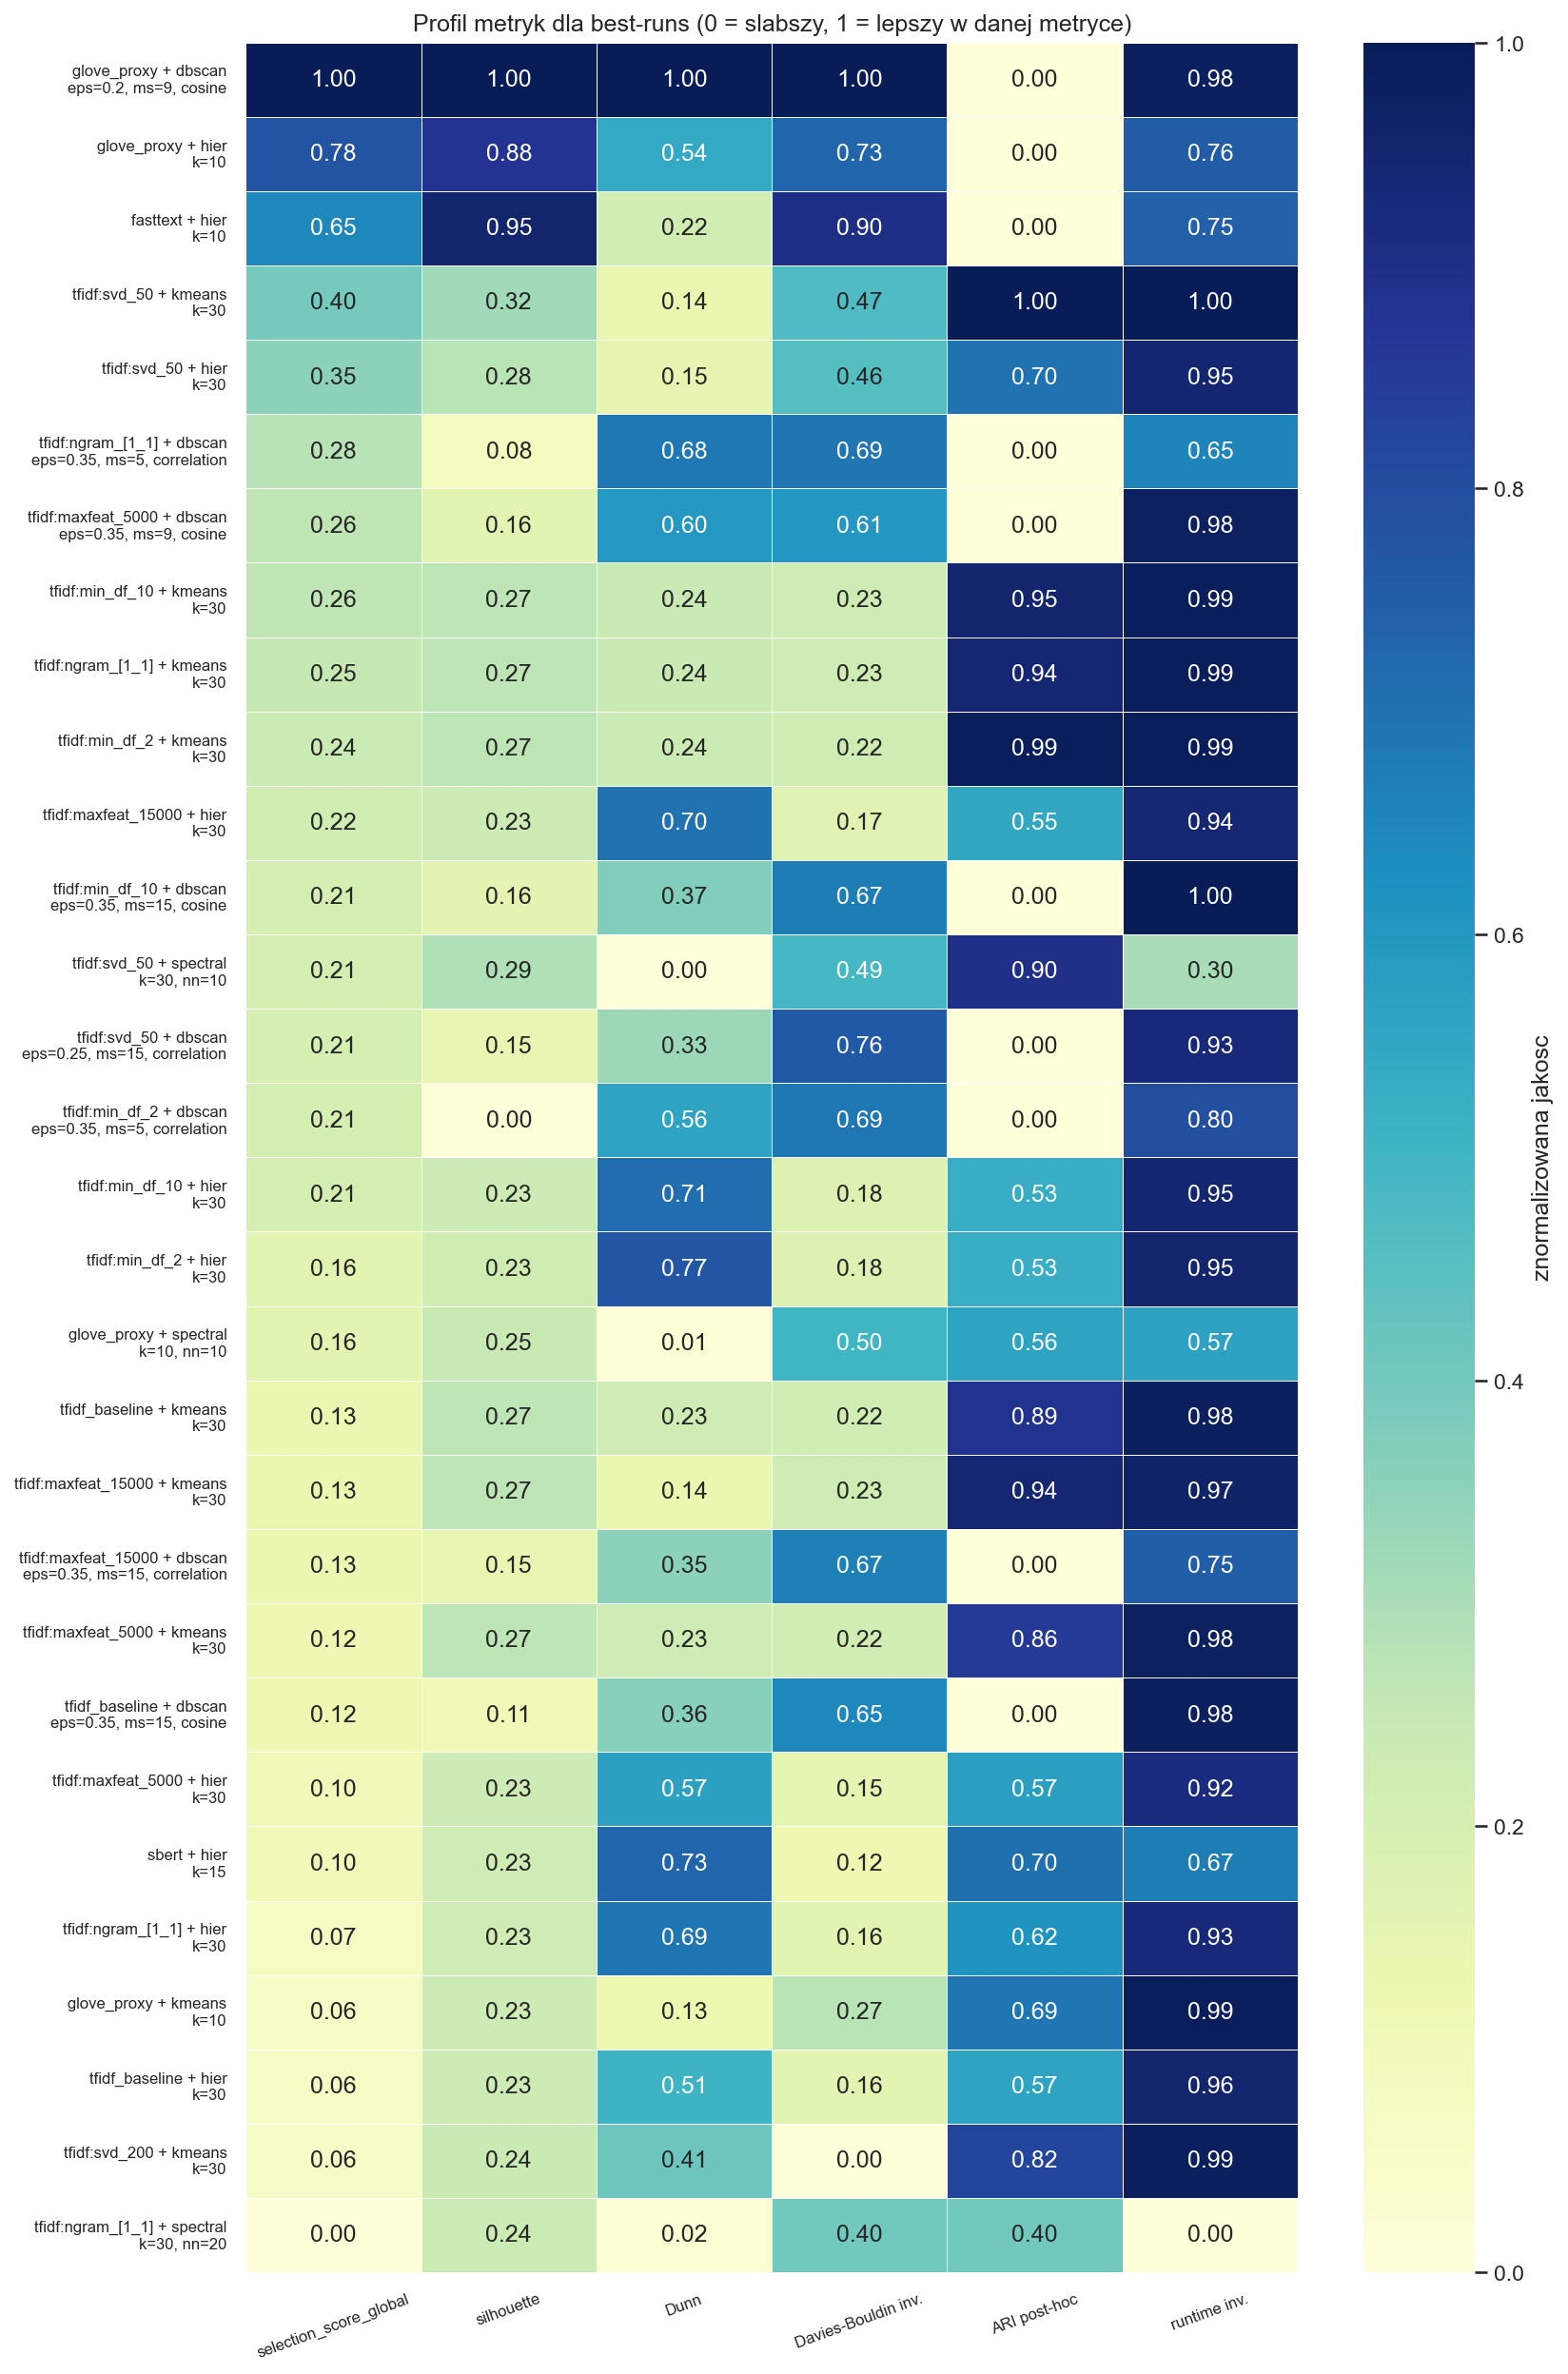

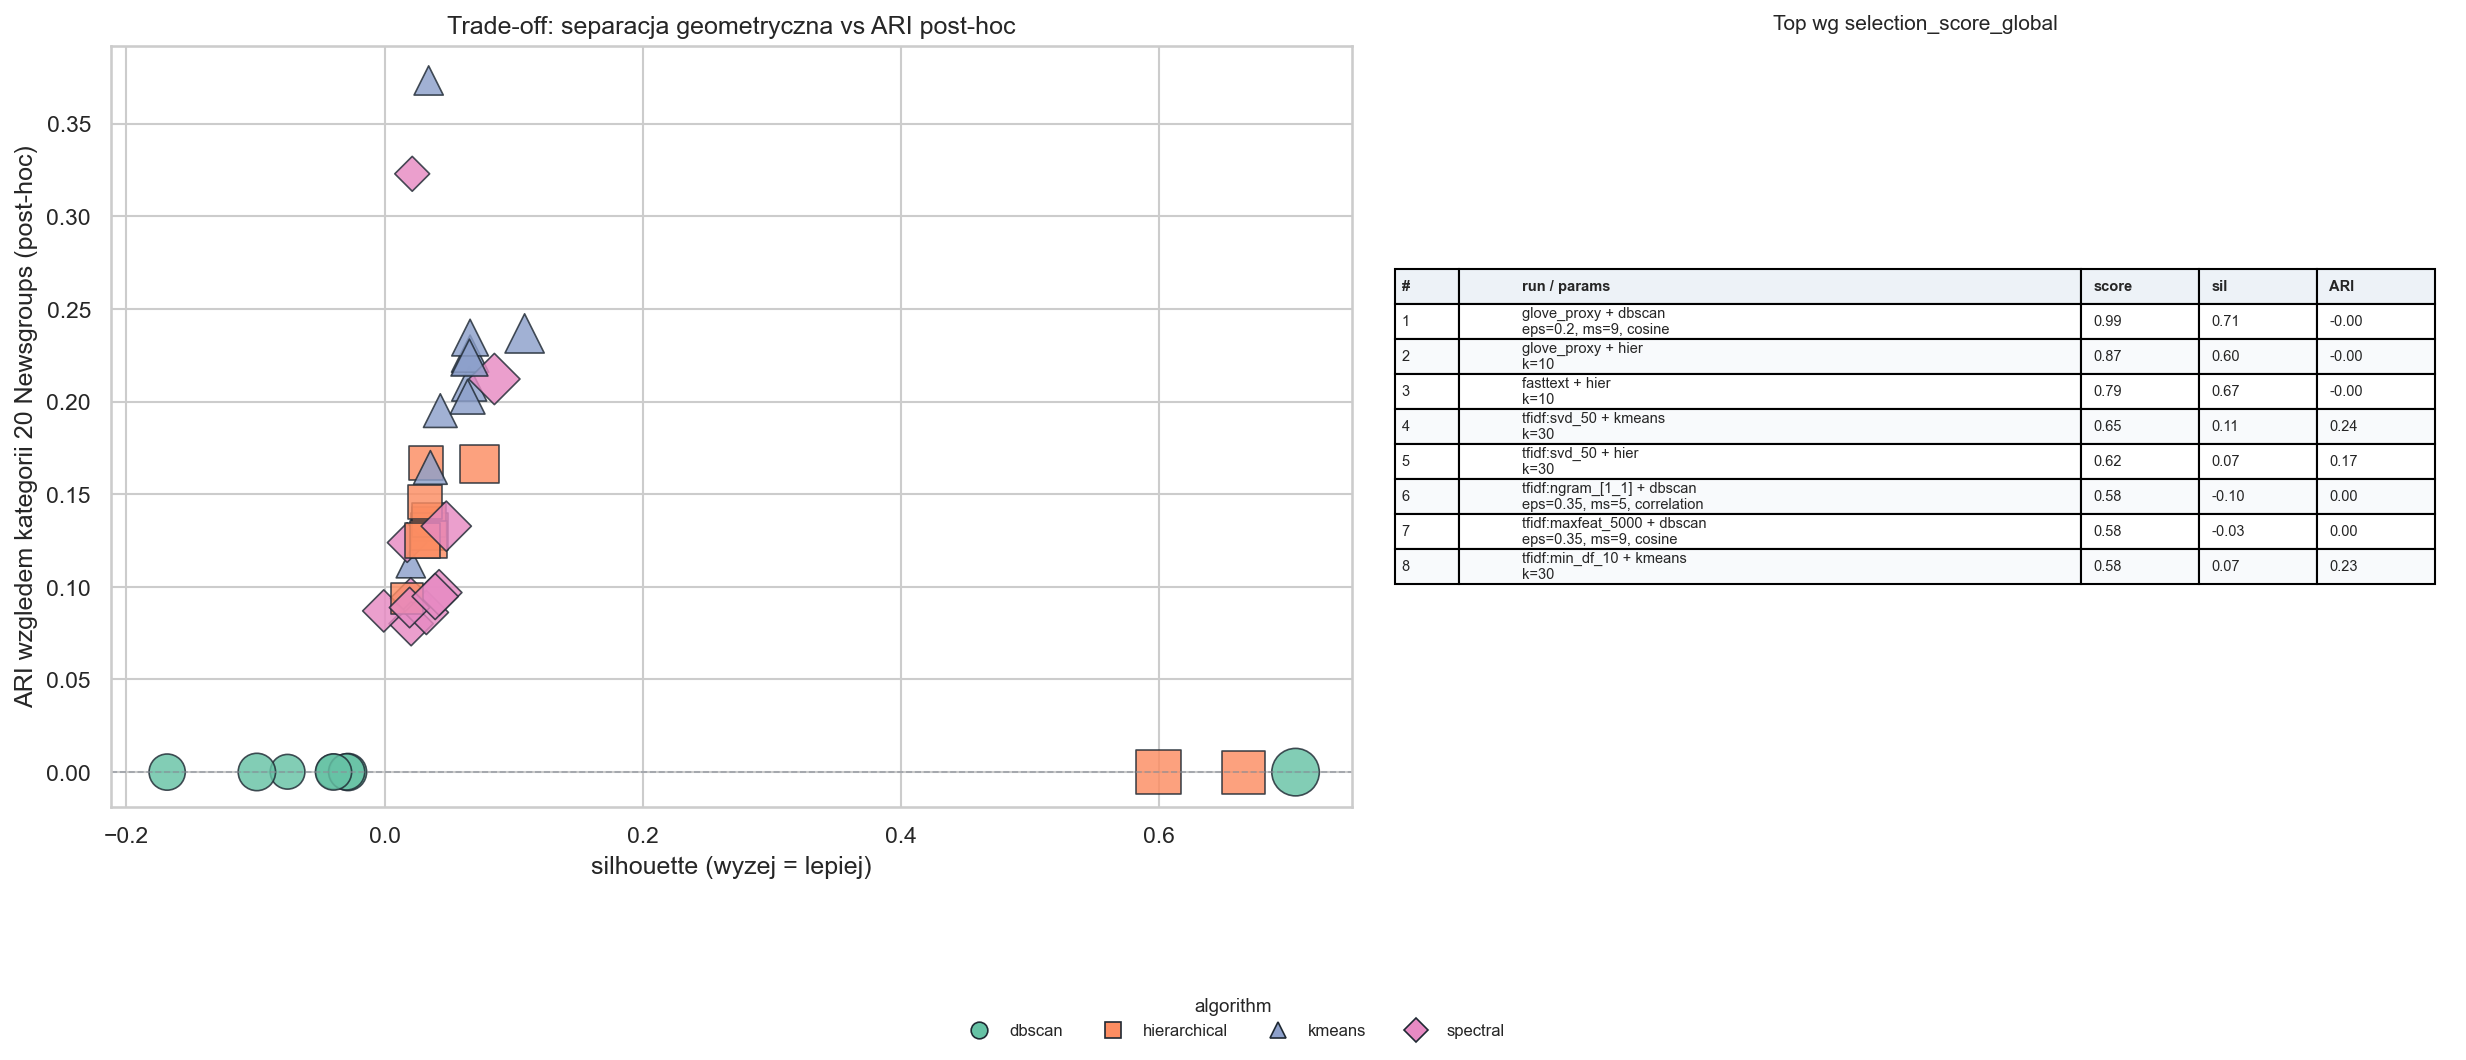

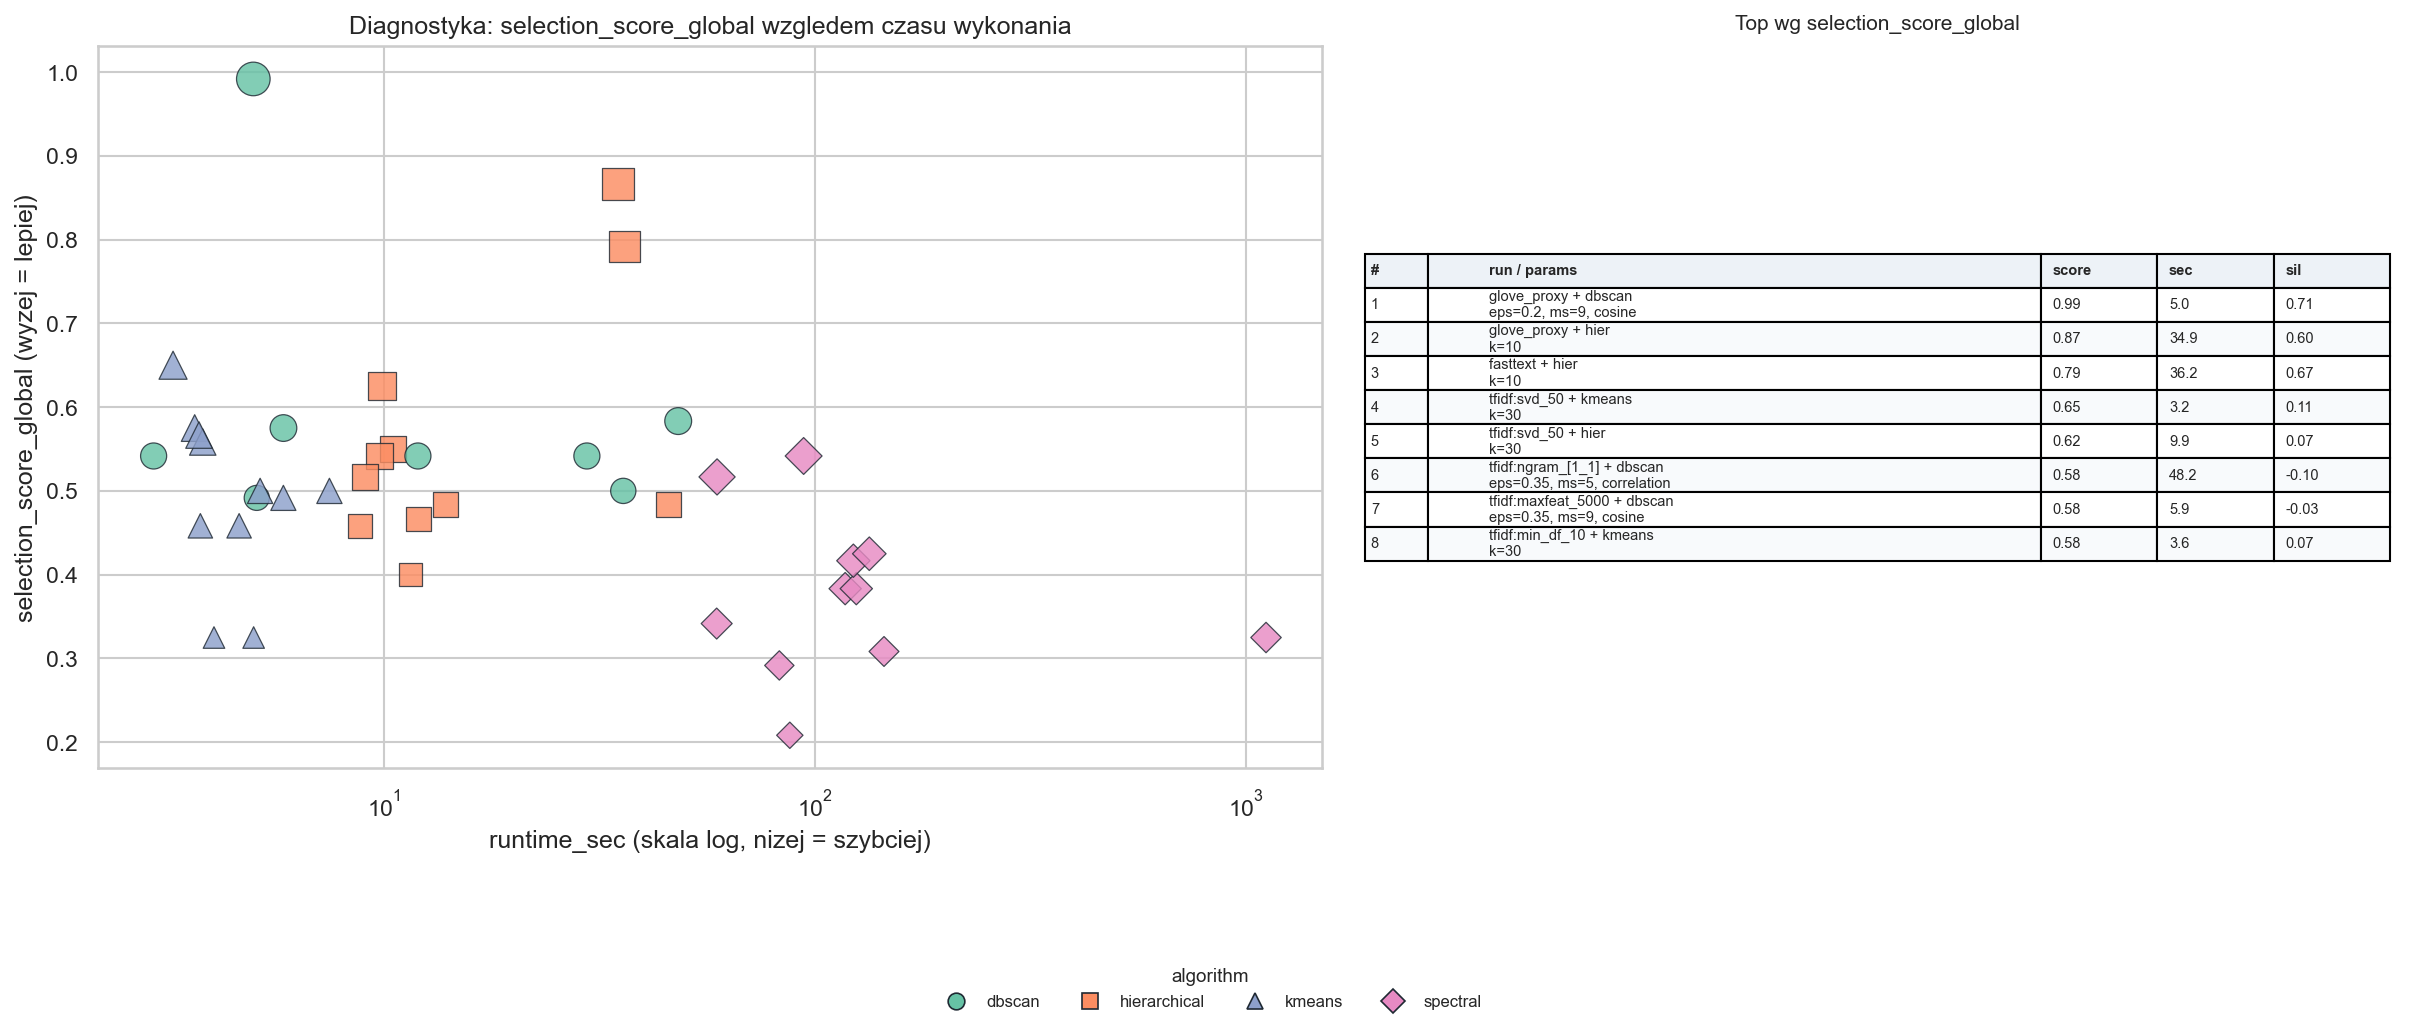

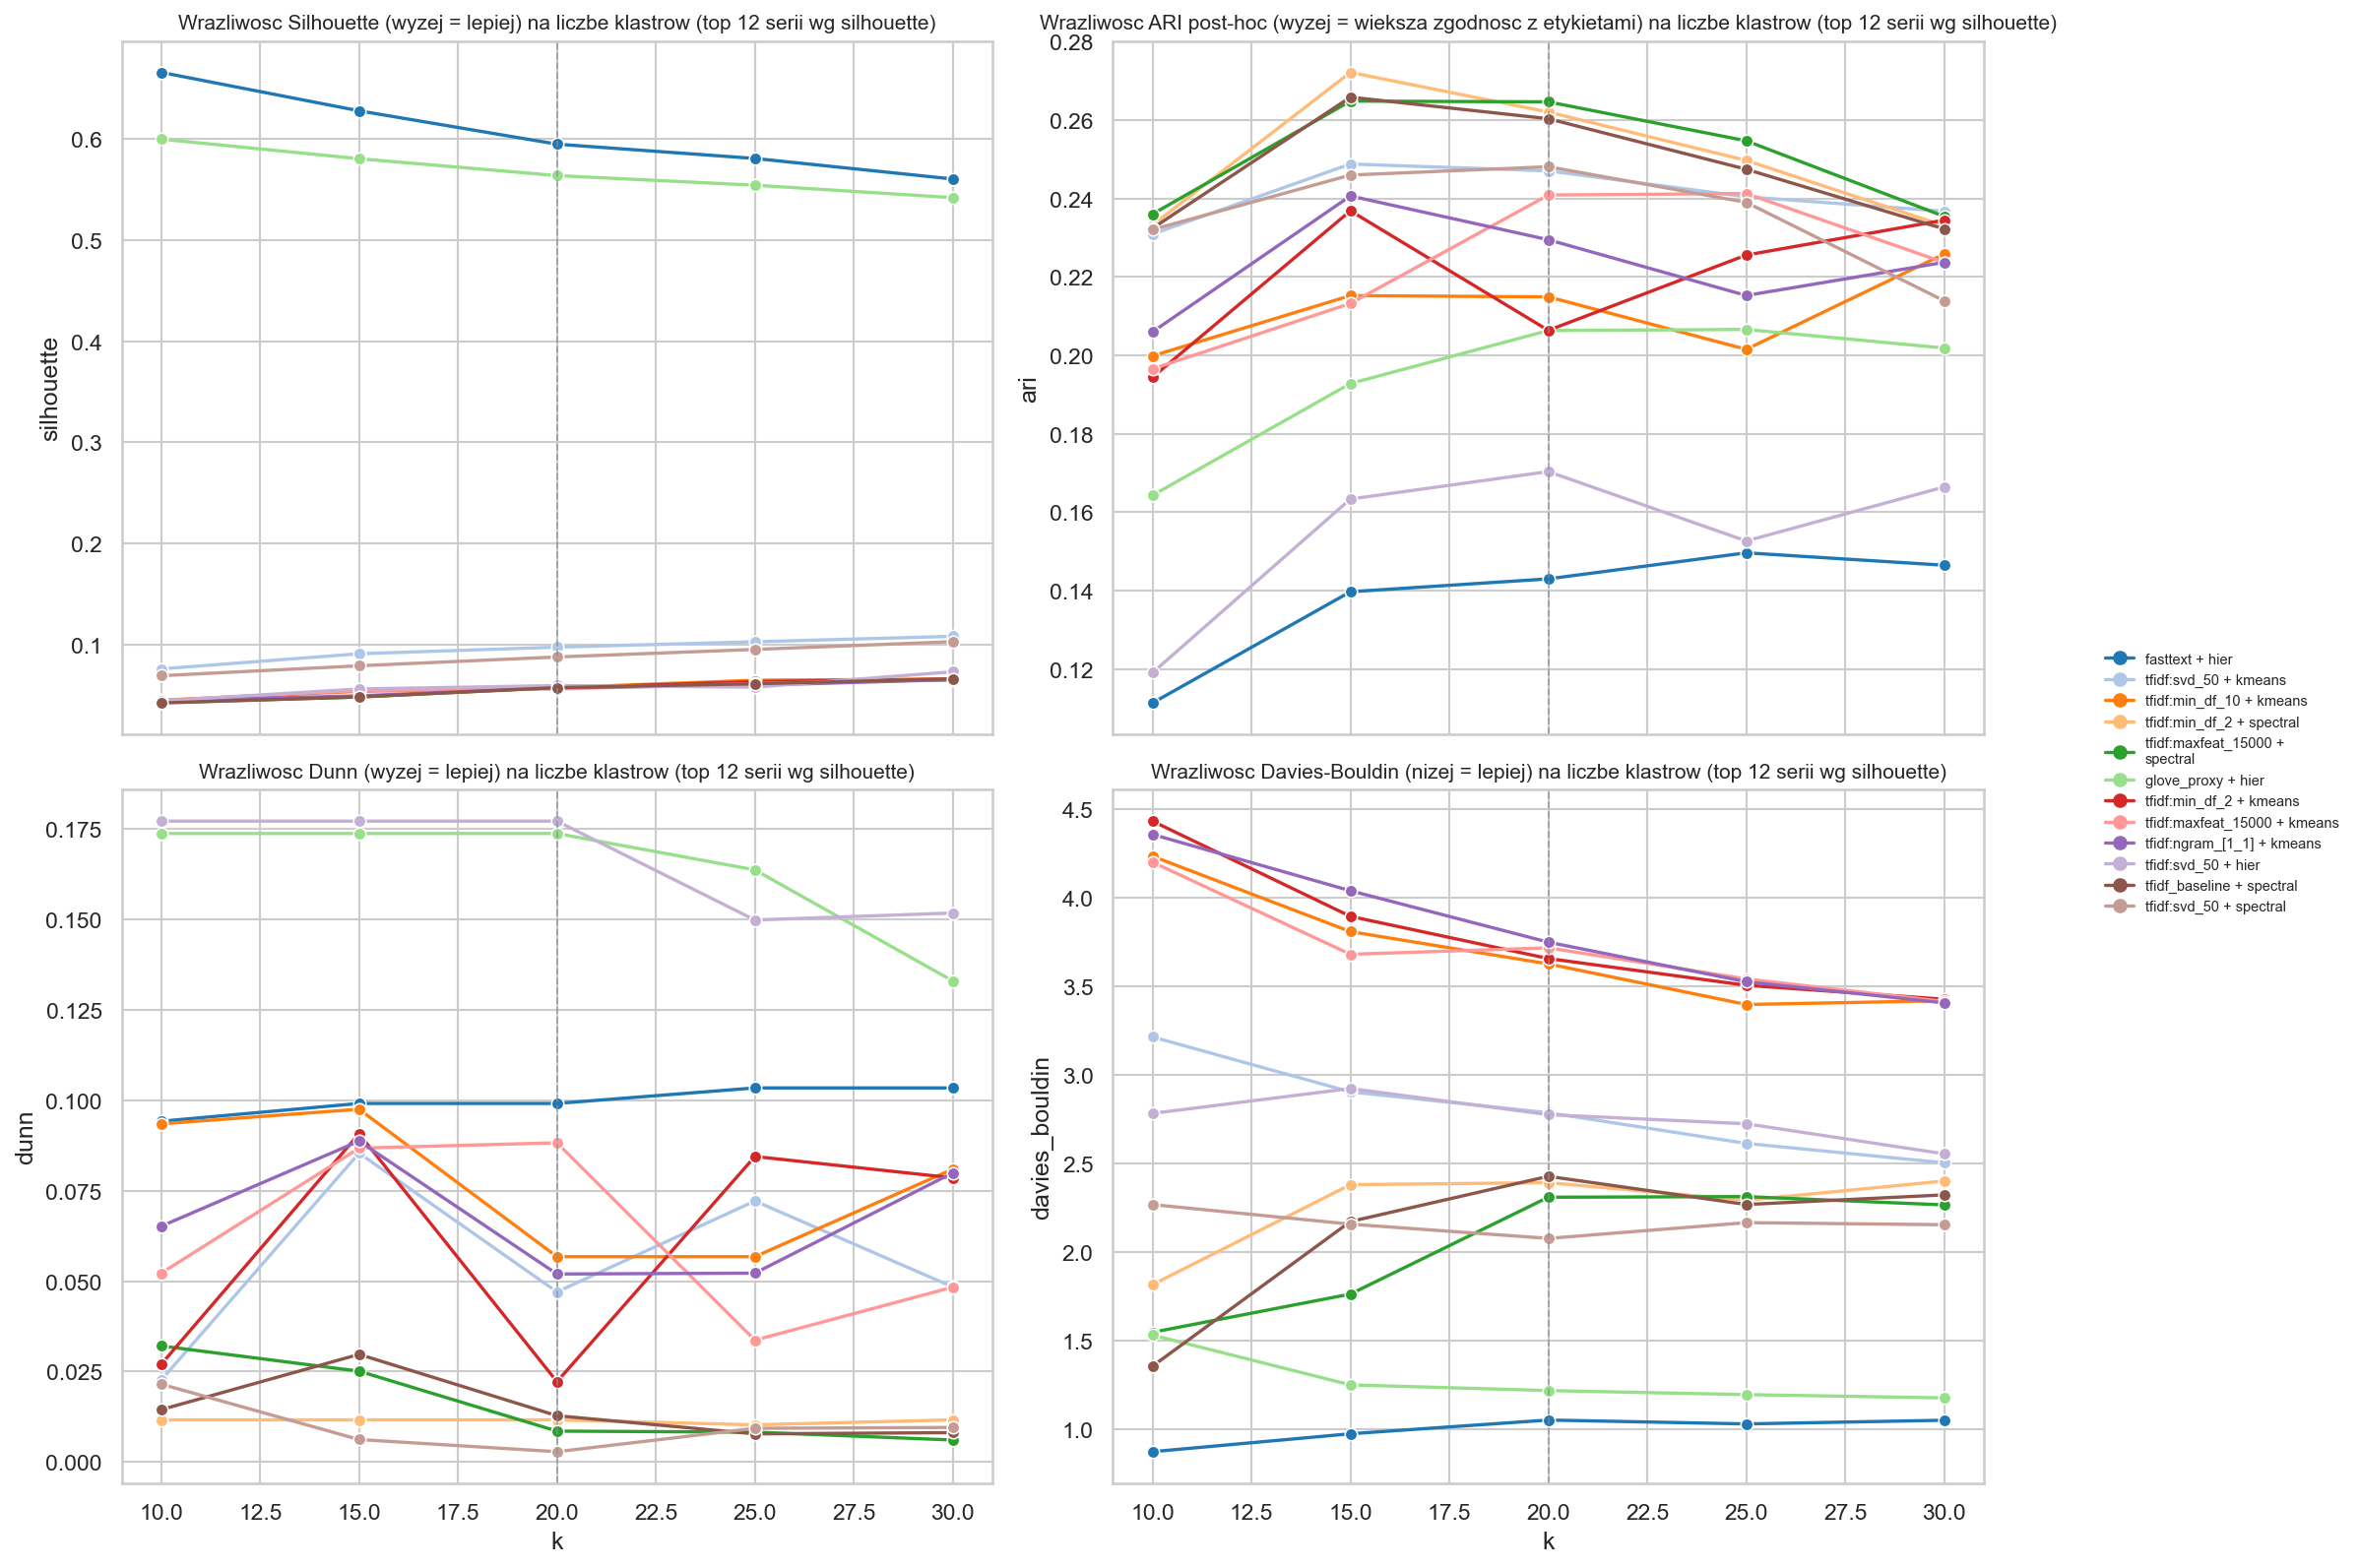

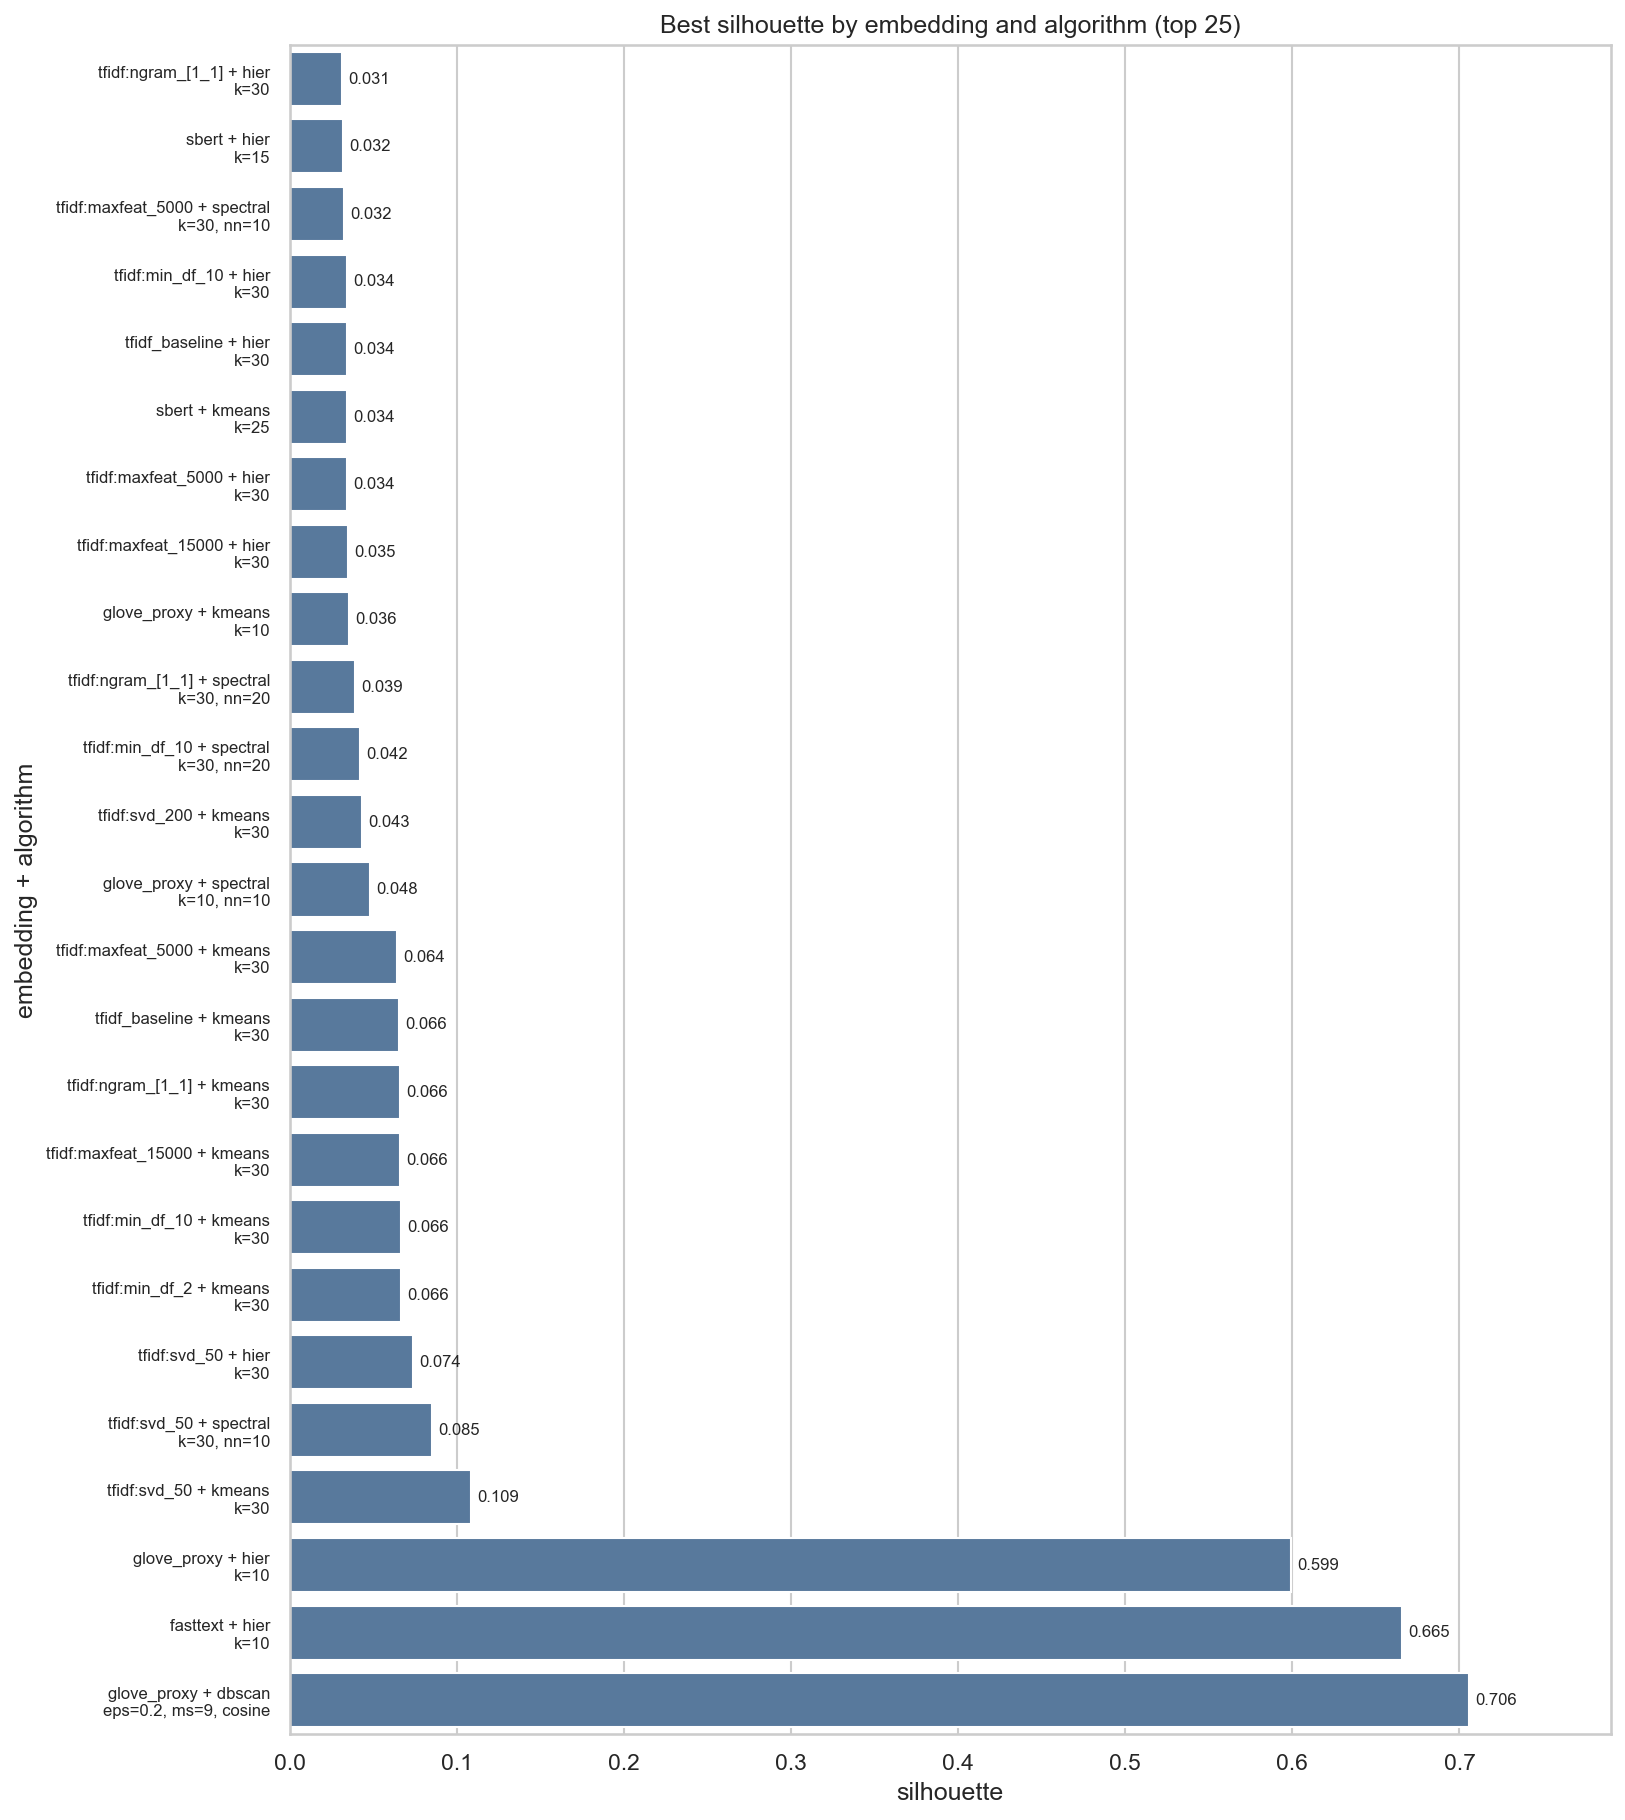

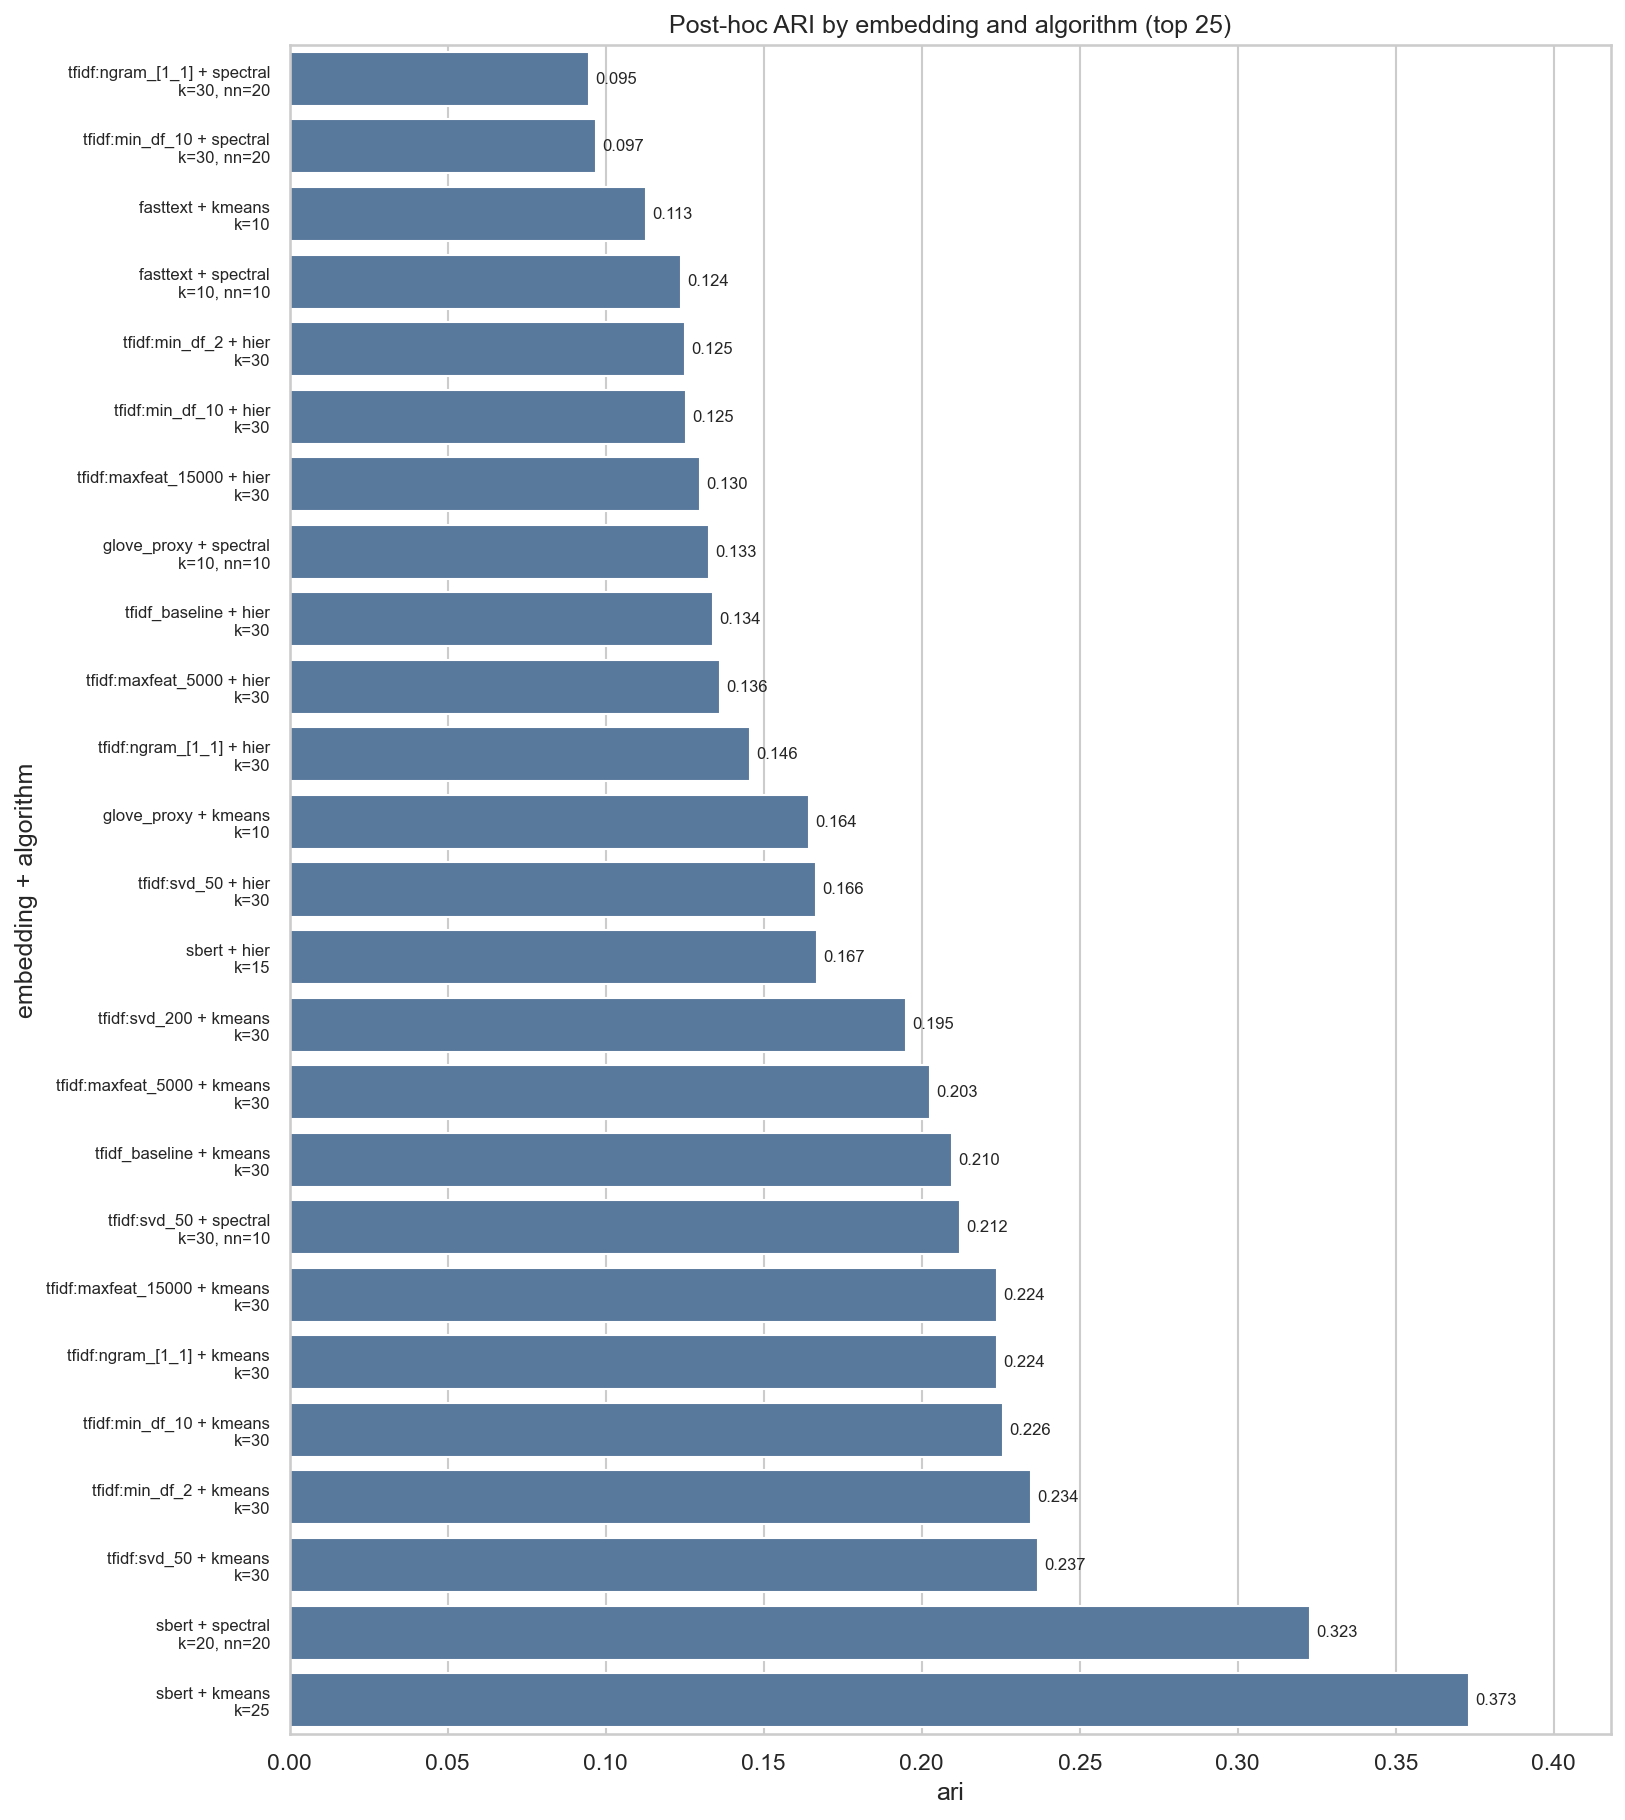

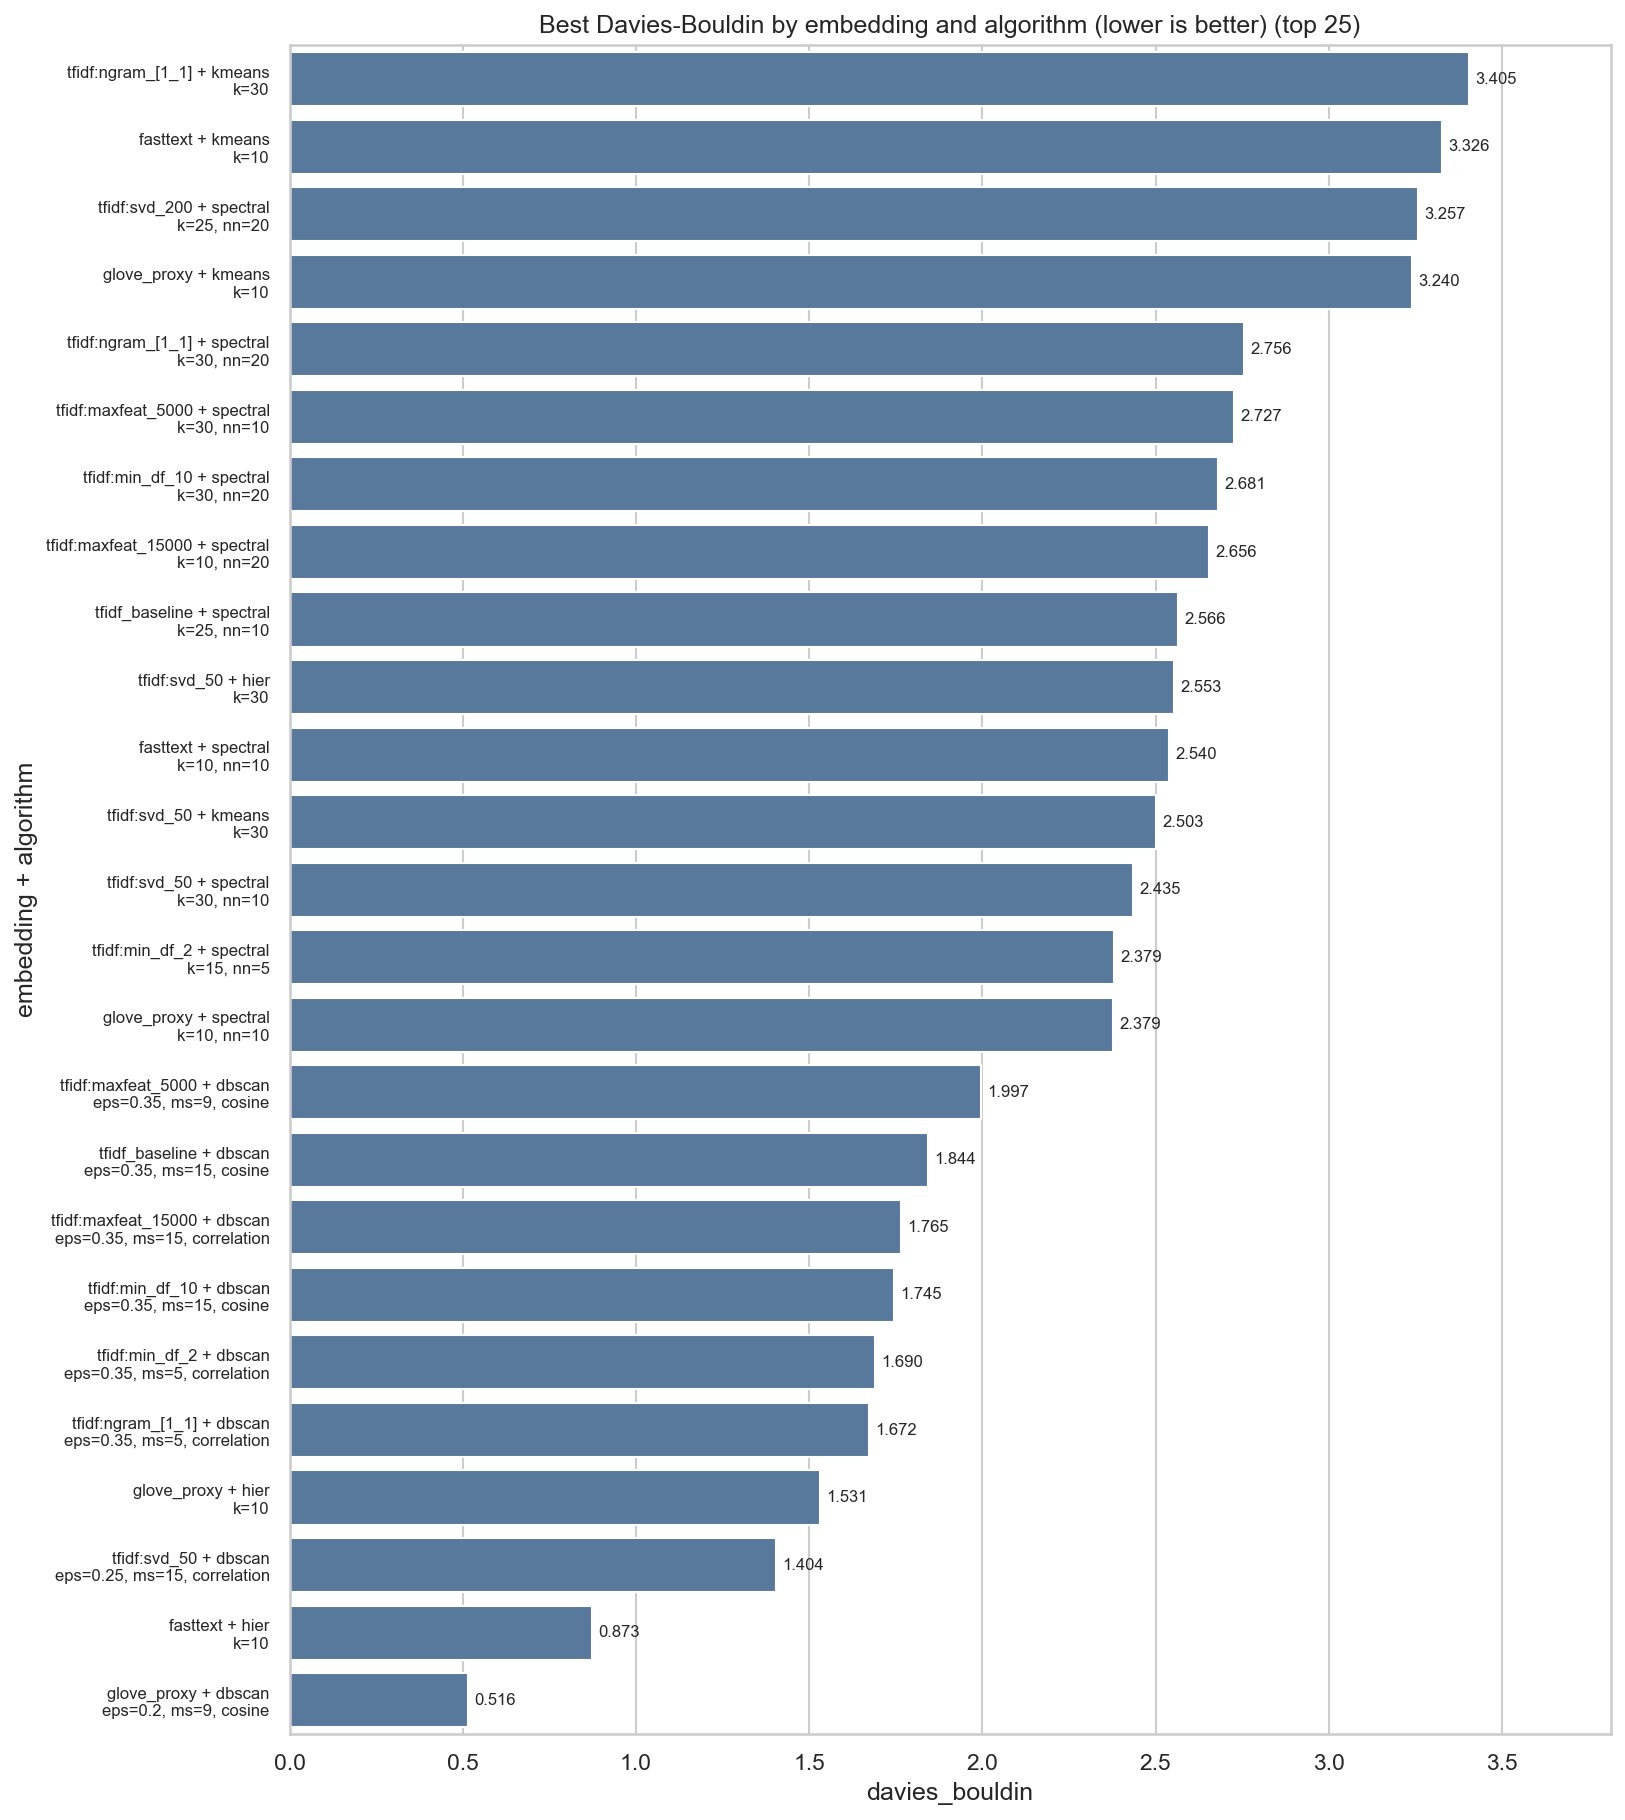

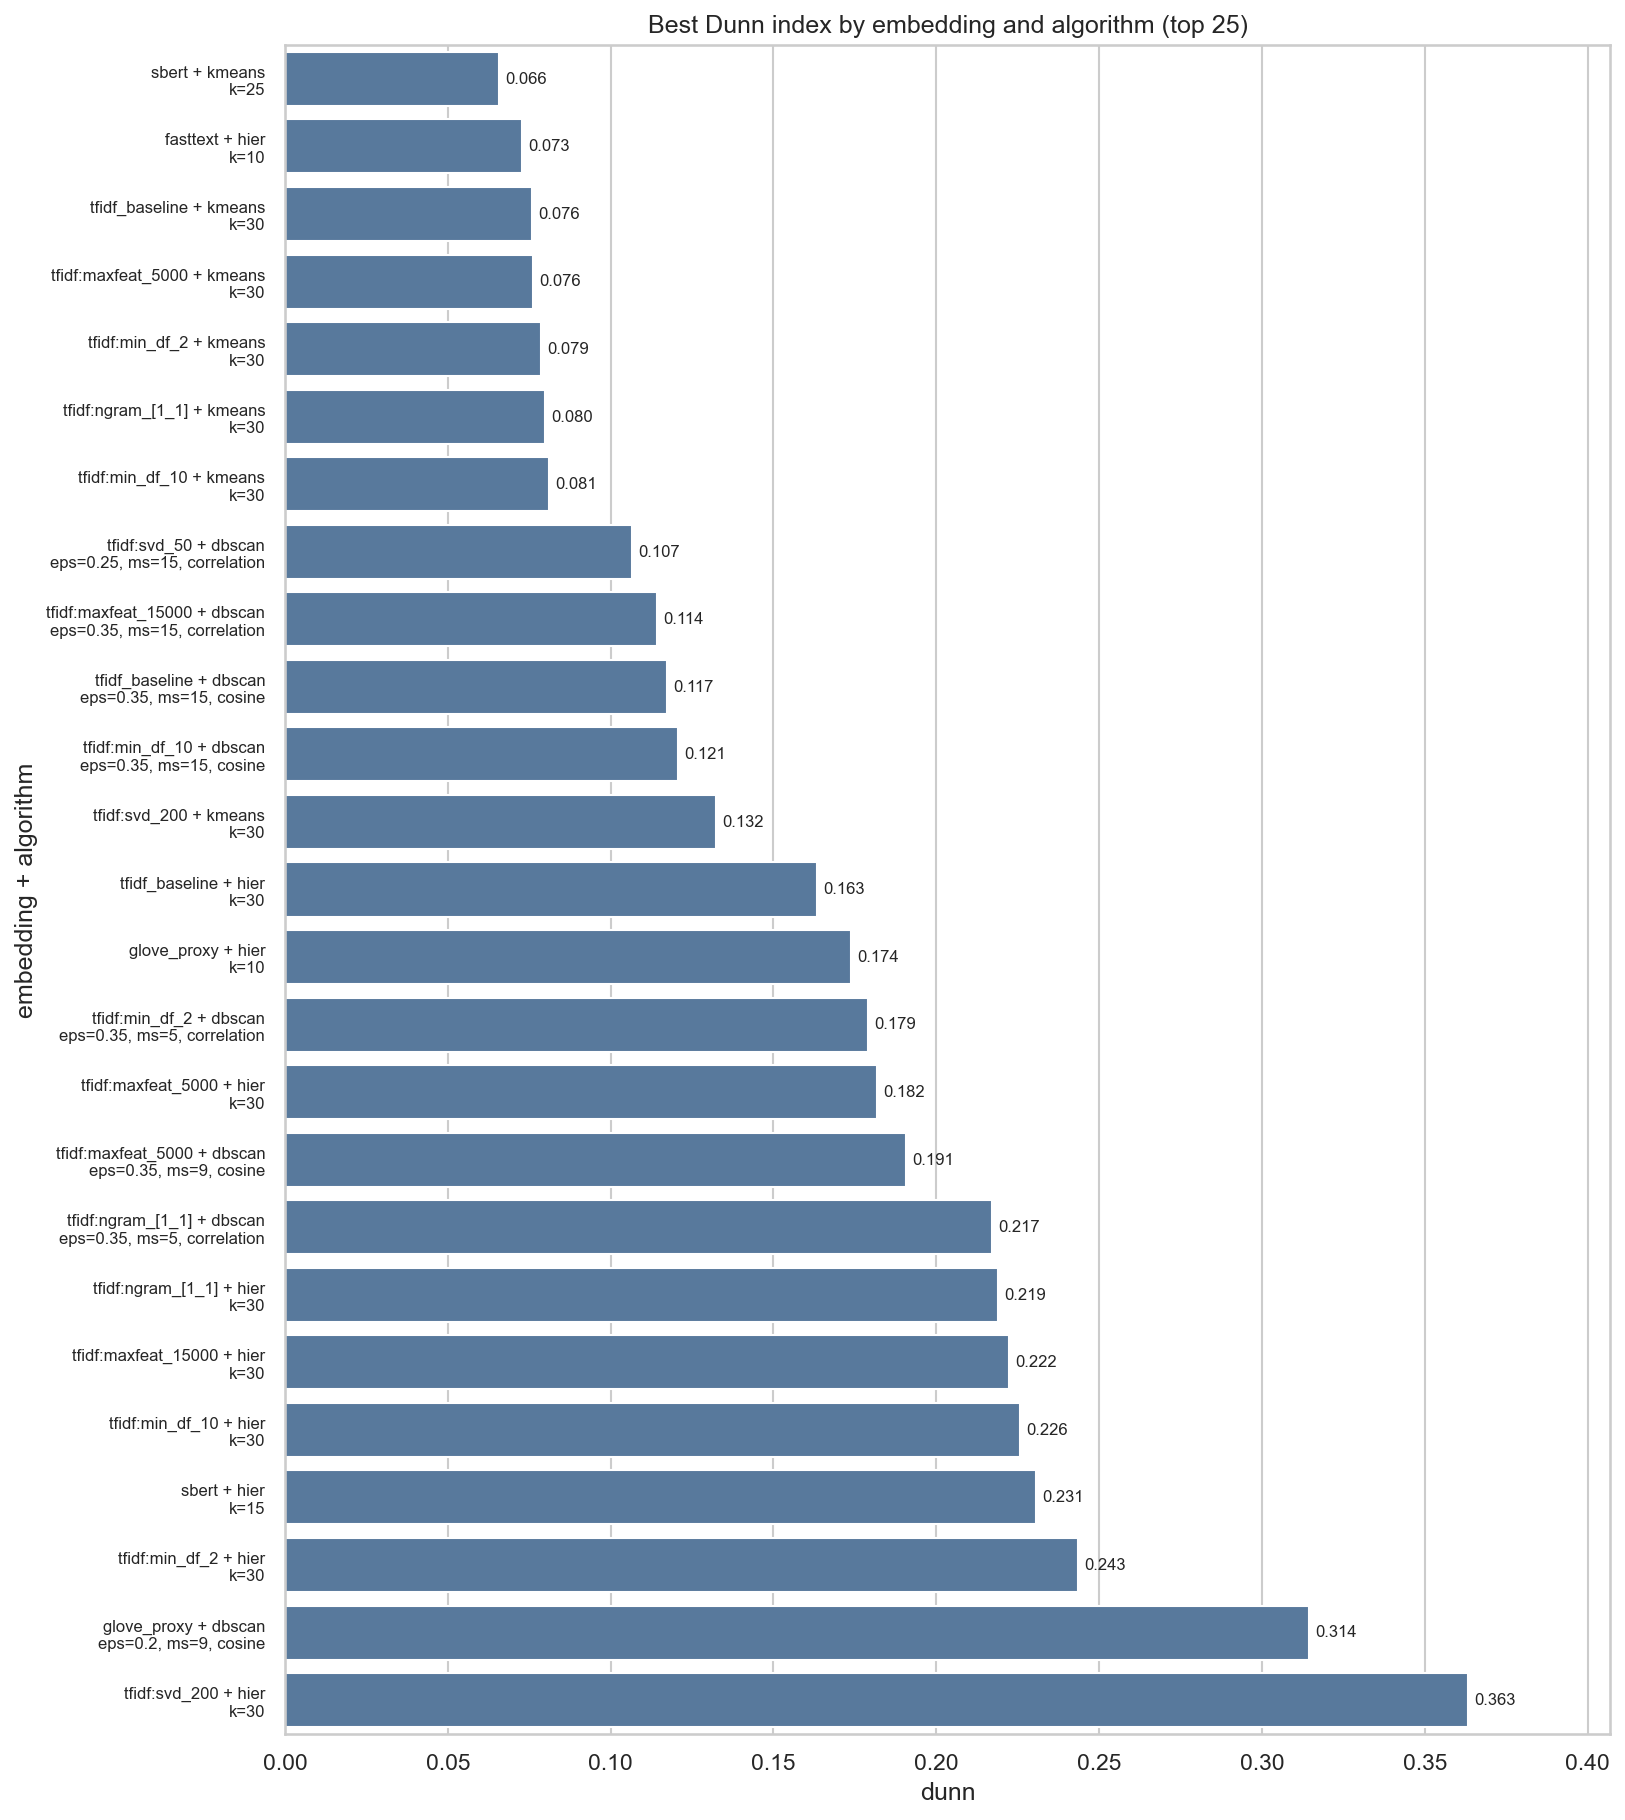

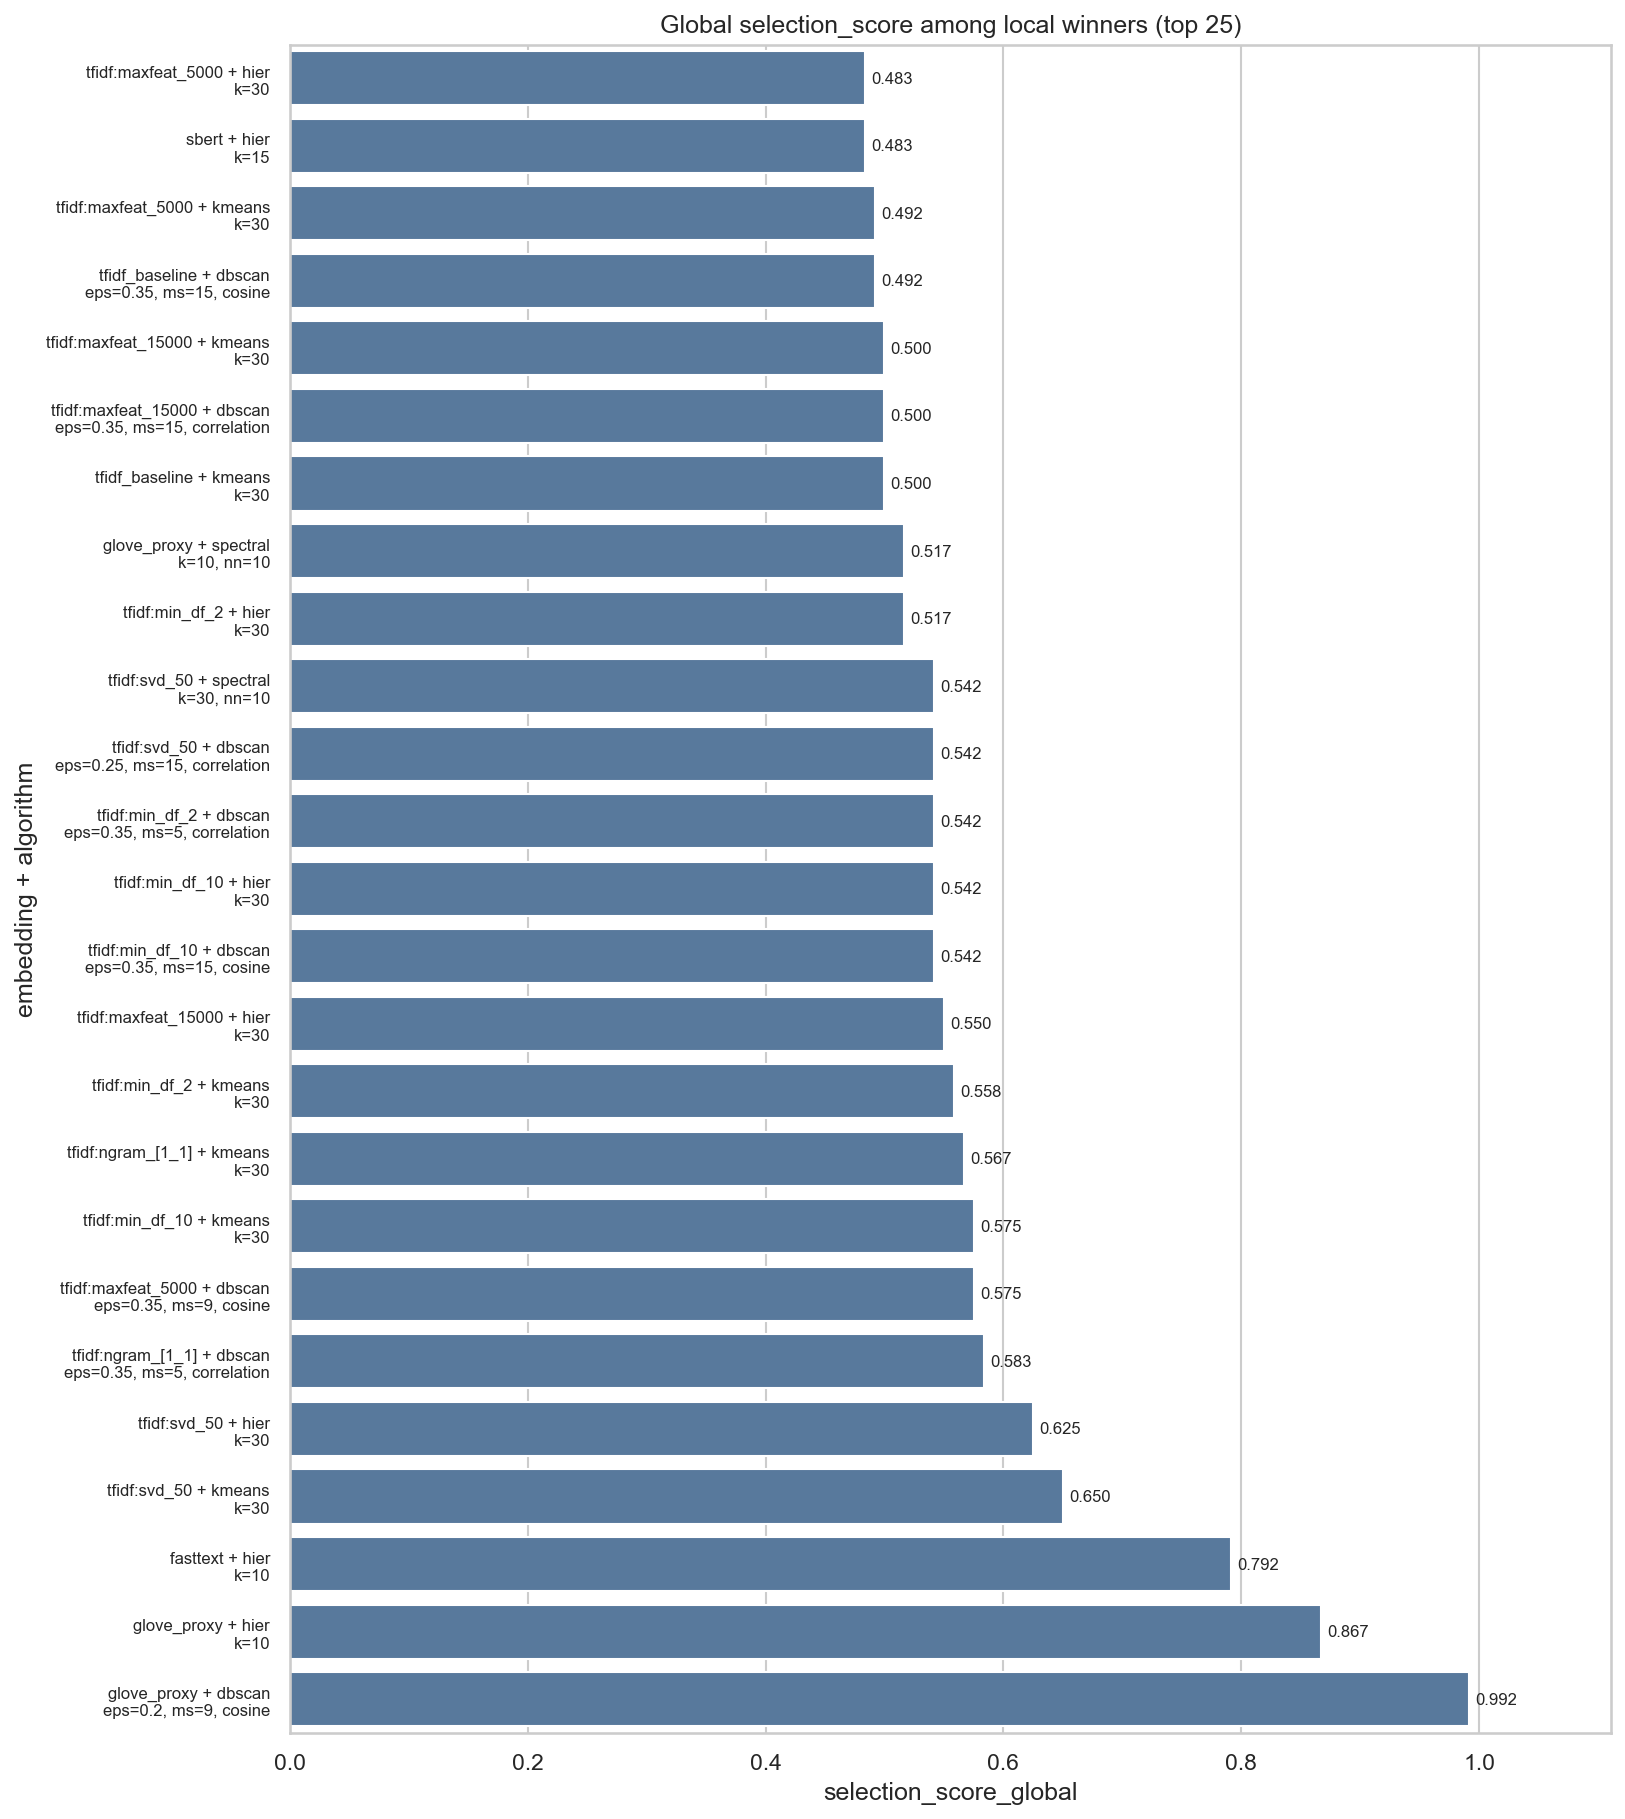

In [21]:
from IPython.display import Image, Markdown, display

section10_views = build_section10_views(
    best_runs_df=best_runs_df,
    interpretation_runs_df=interpretation_runs_df,
    cluster_profiles_df=cluster_profiles_df,
)

display(Markdown("### Tabela 10A. Leaderboard lokalnych zwyciezcow porownanych globalnie"))
display(section10_views["leaderboard"])

display(Markdown("### Tabela 10B. Podsumowanie reprezentacji wg selection_score_global"))
display(section10_views["embedding_summary"])

display(Markdown("### Tabela 10C. Podsumowanie algorytmow wg selection_score_global"))
display(section10_views["algorithm_summary"])

display(Markdown("### Tabela 10D. Analiza liczby klastrow (`k`)"))
display(section10_views["k_summary"])

if not section10_views["purity_summary"].empty:
    display(Markdown("### Tabela 10E. Zgodnosc klastrow z etykietami referencyjnymi (post-hoc)"))
    display(section10_views["purity_summary"])

display(Markdown("### Wykresy przekrojowe sekcji 10"))
section10_plot_keys = [
    "section10_metric_profile_plot",
    "section10_tradeoff_plot",
    "section10_efficiency_plot",
    "section10_k_sensitivity_plot",
    "best_silhouette_plot",
    "best_ari_plot",
    "best_davies_bouldin_plot",
    "best_dunn_plot",
    "best_selection_score_global_plot",
]
for plot_key in section10_plot_keys:
    if plot_key in artifact_paths:
        display(Image(filename=artifact_paths[plot_key]))


## 11. Wnioski

**TODO**: Po wykonaniu notebooka uzupelnij wnioski na podstawie tabel i wykresow:
NP.:
- ktora reprezentacja ma najwyzszy `silhouette` i najnizszy `Davies-Bouldin`,
- czy `SBERT` poprawia separacje semantyczna wzgledem statycznych embeddingow,
- czy `K-means` i klasteryzacja hierarchiczna wskazuja podobna optymalna liczbe klastrow,
- jakie slowa i dokumenty najlepiej wyjasniaja najciekawsze klastry,
- jak wyniki `ARI` odnosza sie do prawdziwych kategorii `20 Newsgroups`.

## [TEMPLATE: Sekcja 11 - Wnioski i podsumowanie ogólne eksperymentu]
> **TODO:** W tej konkluzji opieramy się na całokształcie problemu (wyzwania przy redukcji wymiarów tekstowych, limitacje modeli).

### 11.1 Główne obserwacje
* *[Wylistuj główne punkty (takeaways) z całego projektu]*
1. ...
2. ...
3. ...

### 11.2 Rekomendacje dla przyszłych iteracji (Ograniczenia i Future Work)
* *[Zaproponuj modyfikacje, np. użycie modeli generatywnych (LLM), zmiana metod preprocessingu lub uwzględnienie metod t-SNE/UMAP przy pipeline (obecnie skupiliśmy się na metodach klasycznych)]*

## [TEMPLATE: Sekcja 12 - Weryfikacja pytań badawczych i hipotez]
> **TODO:** W oparciu o wygenerowane modele, odpowiedz na główne pytania badawcze ujęte w koncepcji projektu i uargumentuj je uzyskanymi metrykami z podsumowania.

### Hipoteza / Pytanie badawcze 1: *[Wpisz tu pierwsze główne pytanie]*
* **Rozstrzygnięcie**: *[uzupełnij]*
* **Uzasadnienie z wyników (metryki / czas przetwarzania)**: *[uzupełnij]*

### Hipoteza / Pytanie badawcze 2: *[Wpisz tu drugie pytanie]*
* **Rozstrzygnięcie**: *[uzupełnij]*
* **Uzasadnienie z wyników**: *[Algorytm...]*

### Hipoteza / Pytanie badawcze 3:
* **Rozstrzygnięcie**: *[uzupełnij]*
* **Uzasadnienie z wyników**: *[Algorytm...]*

### Końcowa weryfikacja obiektywna
*[Podsumowanie eksperymentów. Wybór najlepszych algorytmów. Ocena wykonania zadania]*